# 10. Regresión lineal simple y diagnóstico econométrico

## Fase 4 — Modelado

Este notebook desarrolla las regresiones lineales simples entre el crecimiento
de la densidad comercial minorista municipal durante 2020–2025 y las
características socioeconómicas y demográficas observadas en 2020.

Antes de estimar los modelos se realiza un EDA complementario orientado al
modelado, con énfasis en:

- crecimiento de establecimientos comerciales;
- crecimiento poblacional;
- efecto de la densidad comercial inicial;
- descomposición del crecimiento de la densidad;
- identificación preliminar de posibles efectos base.

Posteriormente se estiman y diagnostican los modelos de regresión lineal simple,
incorporando pruebas de heterocedasticidad, errores estándar robustos,
observaciones influyentes y especificaciones alternativas.

In [17]:
# ============================================================
# 1. Librerías
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [18]:
# ============================================================
# 2. Rutas del proyecto
# ============================================================

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
GRAFICAS_DIR = OUTPUTS_DIR / "graficas"

GRAFICAS_DIR.mkdir(parents=True, exist_ok=True)

BASE_MAESTRA = PROCESSED_DIR / "base_maestra_econometrica.csv"

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nBase maestra:")
print(BASE_MAESTRA)

print("\n¿Existe la base maestra?:", BASE_MAESTRA.exists())

PROJECT_ROOT:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico

Base maestra:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\data\processed\base_maestra_econometrica.csv

¿Existe la base maestra?: True


In [19]:
# ============================================================
# 3. Carga de la base maestra
# ============================================================

df = pd.read_csv(
    BASE_MAESTRA,
    dtype={"CVEGEO": "string"}
)

df["CVEGEO"] = df["CVEGEO"].str.zfill(5)

print("Dimensiones:", df.shape)
print("Municipios únicos:", df["CVEGEO"].nunique())
print("Duplicados CVEGEO:", df["CVEGEO"].duplicated().sum())
print("Nulos totales:", df.isna().sum().sum())

display(df.head())

Dimensiones: (2440, 15)
Municipios únicos: 2440
Duplicados CVEGEO: 0
Nulos totales: 0


,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025,CREC_LOG_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
0,01001,AGUASCALIENTES,Aguascalientes,16577,18552,968960,1029221,17.1080,18.0253,5.3615,5.2227,48.8200,10.8400,42.5954,23.6823
1,01002,AGUASCALIENTES,Asientos,412,579,52700,57713,7.8178,10.0324,28.3271,24.9412,62.8000,8.5400,72.7677,40.1319
2,01003,AGUASCALIENTES,Calvillo,940,1062,59333,60886,15.8428,17.4424,10.0970,9.6192,63.3500,8.0500,62.8550,45.7559
3,01004,AGUASCALIENTES,Cosío,170,256,17369,18719,9.7876,13.6759,39.7279,33.4527,60.1300,9.0800,55.5494,37.0392
4,01005,AGUASCALIENTES,Jesús María,1753,2088,132642,141363,13.2160,14.7705,11.7619,11.1201,54.2000,10.2200,49.6232,26.3418


In [20]:
# ============================================================
# 4. Verificación de variables requeridas
# ============================================================

variables_requeridas = [
    "CVEGEO",
    "EST_RETAIL_2020",
    "EST_RETAIL_2025",
    "POB_2020",
    "POB_2025",
    "DENSIDAD_RETAIL_2020",
    "DENSIDAD_RETAIL_2025",
    "CREC_DENSIDAD_RETAIL_2020_2025",
    "CREC_LOG_DENSIDAD_RETAIL_2020_2025",
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in df.columns
]

print("Variables requeridas:", len(variables_requeridas))
print("Variables faltantes:", faltantes)

assert len(faltantes) == 0, (
    f"Faltan variables necesarias para el modelado: {faltantes}"
)

print("\n✅ Todas las variables necesarias están disponibles.")

Variables requeridas: 13
Variables faltantes: []

✅ Todas las variables necesarias están disponibles.


## 5. EDA complementario: componentes del crecimiento de la densidad comercial

La densidad comercial depende simultáneamente del número de establecimientos
minoristas y del tamaño de la población municipal:

\[D_{it} = \frac{E_{it}}{P_{it}} \times 1000\]

Por ello, un incremento en la densidad comercial no implica necesariamente que
el número de establecimientos haya aumentado. También puede producirse si la
población disminuye o crece a un ritmo menor.

Para identificar ambos mecanismos se construyen:

\[G_{EST,i}=100\left(
\frac{EST_{2025,i}-EST_{2020,i}}
{EST_{2020,i}}
\right)\]

y

\[G_{POB,i} = 100\left(
\frac{POB_{2025,i}-POB_{2020,i}}
{POB_{2020,i}}
\right)
\]

Estas variables permitirán determinar si el crecimiento de la densidad comercial
está asociado principalmente con expansión de establecimientos, cambios
demográficos o una combinación de ambos.

In [21]:
# ============================================================
# 5.1 Crecimiento de establecimientos y población
# ============================================================

# Trabajamos sobre una copia para conservar intacta la base cargada
df_modelado = df.copy()

# Verificar que los denominadores sean positivos
print(
    "EST_RETAIL_2020 <= 0:",
    (df_modelado["EST_RETAIL_2020"] <= 0).sum()
)

print(
    "POB_2020 <= 0:",
    (df_modelado["POB_2020"] <= 0).sum()
)

# Crecimiento porcentual de establecimientos retail
df_modelado["CREC_EST_RETAIL_2020_2025"] = (
    (
        df_modelado["EST_RETAIL_2025"]
        - df_modelado["EST_RETAIL_2020"]
    )
    / df_modelado["EST_RETAIL_2020"]
) * 100

# Crecimiento porcentual de la población
df_modelado["CREC_POB_2020_2025"] = (
    (
        df_modelado["POB_2025"]
        - df_modelado["POB_2020"]
    )
    / df_modelado["POB_2020"]
) * 100

# Comprobaciones
variables_crecimiento = [
    "CREC_EST_RETAIL_2020_2025",
    "CREC_POB_2020_2025"
]

print("\nNulos:")
print(df_modelado[variables_crecimiento].isna().sum())

print("\nInfinitos:")
print(
    np.isinf(
        df_modelado[variables_crecimiento]
    ).sum()
)

print("\nDimensiones de trabajo:")
print(df_modelado.shape)

EST_RETAIL_2020 <= 0: 0
POB_2020 <= 0: 0

Nulos:
CREC_EST_RETAIL_2020_2025    0
CREC_POB_2020_2025           0
dtype: int64

Infinitos:
CREC_EST_RETAIL_2020_2025    0
CREC_POB_2020_2025           0
dtype: int64

Dimensiones de trabajo:
(2440, 17)


###Cómo se comportaron, en general, los establecimientos y la población entre 2020 y 2025?

Paso 6 — Estadística descriptiva de los dos componentes

### 5.2 Comportamiento de los componentes de la densidad

Antes de relacionar estos indicadores con el crecimiento de la densidad comercial,
se analiza su distribución para determinar:

- cuánto crecieron en promedio los establecimientos;
- cuánto cambió la población;
- qué tan heterogéneo fue el comportamiento municipal;
- cuántos municipios registraron crecimiento o disminución.

Este análisis permite identificar si el crecimiento de la densidad comercial
se encuentra acompañado principalmente por expansión comercial, cambios
demográficos o ambos fenómenos.

In [22]:
# ============================================================
# 5.2 Estadística descriptiva de los componentes
# ============================================================

resumen_componentes = (
    df_modelado[
        [
            "CREC_EST_RETAIL_2020_2025",
            "CREC_POB_2020_2025"
        ]
    ]
    .describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
    .T
)

resumen_componentes = resumen_componentes.rename(
    columns={
        "count": "N",
        "mean": "Media",
        "std": "Desv_est",
        "min": "Min",
        "5%": "P05",
        "25%": "Q1",
        "50%": "Mediana",
        "75%": "Q3",
        "95%": "P95",
        "max": "Max"
    }
)

display(resumen_componentes)

,N,Media,Desv_est,Min,P05,Q1,Mediana,Q3,P95,Max
CREC_EST_RETAIL_2020_2025,"2,440.0000",18.7776,27.2392,-62.5000,-10.0098,6.9554,16.0983,27.4064,52.1212,568.4211
CREC_POB_2020_2025,"2,440.0000",2.8350,5.6316,-18.7683,-4.7835,-0.5106,2.2501,5.6065,11.7506,62.1964


In [23]:
# ============================================================
# 5.3 Dirección del cambio Vamos a contar cuántos municipios crecieron, disminuyeron o permanecieron iguales
# ============================================================

def clasificar_cambio(x):
    if x > 0:
        return "Crecimiento"
    elif x < 0:
        return "Disminución"
    else:
        return "Sin cambio"


df_modelado["CAMBIO_EST"] = (
    df_modelado["CREC_EST_RETAIL_2020_2025"]
    .apply(clasificar_cambio)
)

df_modelado["CAMBIO_POB"] = (
    df_modelado["CREC_POB_2020_2025"]
    .apply(clasificar_cambio)
)


print("ESTABLECIMIENTOS RETAIL")
display(
    df_modelado["CAMBIO_EST"]
    .value_counts()
    .to_frame("Municipios")
)


print("\nPOBLACIÓN")
display(
    df_modelado["CAMBIO_POB"]
    .value_counts()
    .to_frame("Municipios")
)

ESTABLECIMIENTOS RETAIL


,Municipios
CAMBIO_EST,
Crecimiento,2061
Disminución,321
Sin cambio,58



POBLACIÓN


,Municipios
CAMBIO_POB,
Crecimiento,1699
Disminución,736
Sin cambio,5


In [24]:
# ============================================================
# 5.4 Dirección del cambio de la densidad comercial
# ============================================================

df_modelado["CAMBIO_DENSIDAD"] = (
    df_modelado["CREC_DENSIDAD_RETAIL_2020_2025"]
    .apply(clasificar_cambio)
)

tabla_direcciones = pd.crosstab(
    [
        df_modelado["CAMBIO_EST"],
        df_modelado["CAMBIO_POB"]
    ],
    df_modelado["CAMBIO_DENSIDAD"],
    margins=True
)

display(tabla_direcciones)

CAMBIO_DENSIDAD          Crecimiento  Disminución  Sin cambio   All
CAMBIO_EST  CAMBIO_POB                                             
Crecimiento Crecimiento         1377          111           0  1488
            Disminución          571            0           0   571
            Sin cambio             2            0           0     2
Disminución Crecimiento            0          182           0   182
            Disminución           30          107           0   137
            Sin cambio             0            2           0     2
Sin cambio  Crecimiento            0           29           0    29
            Disminución           28            0           0    28
            Sin cambio             0            0           1     1
All                             2008          431           1  2440

### Interpretación

La descomposición del crecimiento muestra que el incremento de la densidad
comercial minorista observado entre 2020 y 2025 estuvo acompañado
principalmente por un aumento efectivo en el número de establecimientos.

De los 2,440 municipios analizados, 2,008 (82.30%) registraron un incremento
en su densidad comercial. Entre ellos, 1,950 municipios (97.11%) también
presentaron crecimiento en el número de establecimientos minoristas.

Únicamente 58 municipios (2.89% de aquellos cuya densidad aumentó)
registraron crecimiento de la densidad sin un incremento en el número de
establecimientos. En estos casos, el aumento de la densidad estuvo asociado
con una reducción poblacional.

Estos resultados indican que, aunque el componente demográfico influye en la
construcción de la densidad comercial, el crecimiento observado en la mayoría
de los municipios estuvo acompañado por una expansión efectiva del número de
establecimientos minoristas.

¿Cuantos municipios aumentaron densidad sin aumentar establecimientos?

### Visualización complementaria: dirección del cambio 2020–2025

La siguiente figura compara la proporción de municipios que registraron
crecimiento, disminución o ausencia de cambio en el número de establecimientos
minoristas, la población y la densidad comercial entre 2020 y 2025.

Esta comparación permite observar que la evolución de la densidad comercial
no depende exclusivamente del cambio en el número de establecimientos, debido
a que la población también forma parte de su construcción.

In [25]:
# ============================================================
# Verificación de requisitos para la gráfica
# ============================================================

print("pd disponible:", "pd" in globals())
print("plt disponible:", "plt" in globals())
print("df_modelado disponible:", "df_modelado" in globals())
print("GRAFICAS_DIR disponible:", "GRAFICAS_DIR" in globals())

if "df_modelado" in globals():

    columnas_necesarias = [
        "CAMBIO_EST",
        "CAMBIO_POB",
        "CAMBIO_DENSIDAD"
    ]

    for columna in columnas_necesarias:
        print(
            f"{columna} disponible:",
            columna in df_modelado.columns
        )

pd disponible: True
plt disponible: True
df_modelado disponible: True
GRAFICAS_DIR disponible: True
CAMBIO_EST disponible: True
CAMBIO_POB disponible: True
CAMBIO_DENSIDAD disponible: True


,Establecimientos,Población,Densidad comercial
Crecimiento,84.4700,69.6300,82.3000
Disminución,13.1600,30.1600,17.6600
Sin cambio,2.3800,0.2000,0.0400


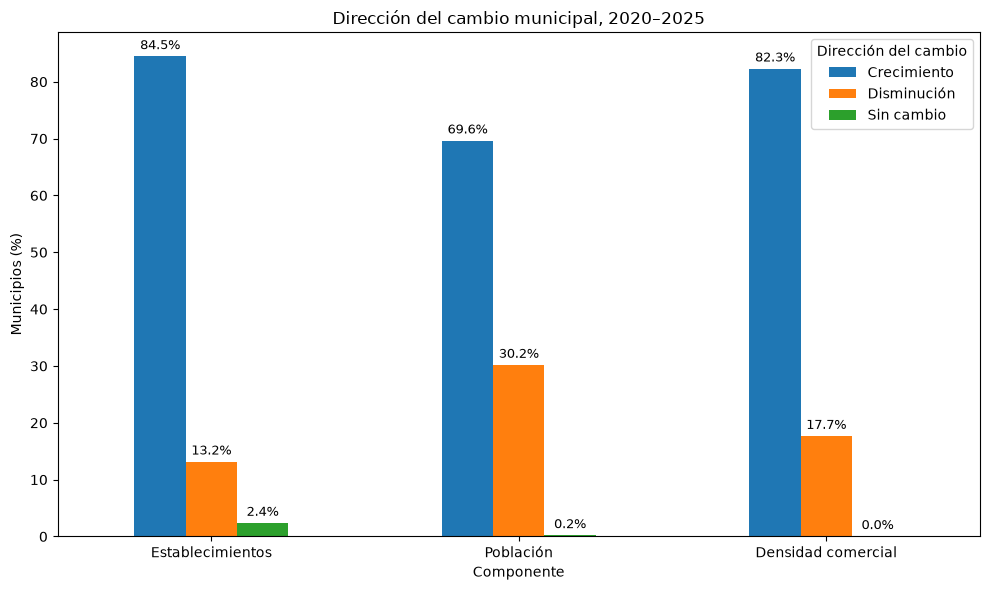

Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\direccion_cambio_est_pob_densidad_2020_2025.png


In [26]:
# ============================================================
# Dirección del cambio 2020–2025
# Establecimientos, población y densidad comercial
# ============================================================


orden_cambio = [
    "Crecimiento",
    "Disminución",
    "Sin cambio"
]

# Conteos por categoría
resumen_cambios = pd.DataFrame({
    "Establecimientos": (
        df_modelado["CAMBIO_EST"]
        .value_counts()
        .reindex(orden_cambio, fill_value=0)
    ),

    "Población": (
        df_modelado["CAMBIO_POB"]
        .value_counts()
        .reindex(orden_cambio, fill_value=0)
    ),

    "Densidad comercial": (
        df_modelado["CAMBIO_DENSIDAD"]
        .value_counts()
        .reindex(orden_cambio, fill_value=0)
    )
})

# Convertir a porcentaje
resumen_cambios_pct = (
    resumen_cambios
    .div(len(df_modelado))
    .mul(100)
)

display(
    resumen_cambios_pct.round(2)
)

# ============================================================
# Gráfica
# ============================================================

ax = resumen_cambios_pct.T.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Dirección del cambio municipal, 2020–2025"
)

ax.set_xlabel(
    "Componente"
)

ax.set_ylabel(
    "Municipios (%)"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

ax.legend(
    title="Dirección del cambio"
)

# Etiquetas de porcentaje
for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

ruta_cambios = (
    GRAFICAS_DIR
    / "direccion_cambio_est_pob_densidad_2020_2025.png"
)

plt.savefig(
    ruta_cambios,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfica guardada en:")
print(ruta_cambios)

##Paso 7 — Descomposición logarítmica exacta

### 5.5 Descomposición logarítmica del crecimiento de la densidad

La densidad comercial se define como:

\[
D_{it}=\frac{E_{it}}{P_{it}}\times1000
\]

Aplicando logaritmos:

\[
\ln(D_{it})
=
\ln(E_{it})
-
\ln(P_{it})
+
\ln(1000)
\]

Al calcular el cambio entre 2020 y 2025, la constante \(\ln(1000)\) desaparece:

\[
\ln(D_{2025})-\ln(D_{2020})
=
[\ln(E_{2025})-\ln(E_{2020})]
-
[\ln(P_{2025})-\ln(P_{2020})]
\]

Por lo tanto:

\[
\boxed{
\Delta\ln(D)
=
\Delta\ln(E)-\Delta\ln(P)
}
\]

Esta identidad permite separar exactamente el crecimiento de la densidad
comercial entre el componente asociado al número de establecimientos y el
componente asociado al cambio poblacional.

In [27]:
# ============================================================
# 5.5 Descomposición logarítmica de la densidad comercial
# ============================================================

# Crecimiento logarítmico de establecimientos
df_modelado["CREC_LOG_EST_RETAIL_2020_2025"] = 100 * (
    np.log(df_modelado["EST_RETAIL_2025"])
    - np.log(df_modelado["EST_RETAIL_2020"])
)

# Crecimiento logarítmico de población
df_modelado["CREC_LOG_POB_2020_2025"] = 100 * (
    np.log(df_modelado["POB_2025"])
    - np.log(df_modelado["POB_2020"])
)

# Reconstrucción de la variación logarítmica de la densidad
df_modelado["CREC_LOG_DENSIDAD_RECONSTRUIDA"] = (
    df_modelado["CREC_LOG_EST_RETAIL_2020_2025"]
    - df_modelado["CREC_LOG_POB_2020_2025"]
)

# Diferencia respecto a la Y logarítmica ya construida
df_modelado["ERROR_IDENTIDAD_LOG"] = (
    df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"]
    - df_modelado["CREC_LOG_DENSIDAD_RECONSTRUIDA"]
)

print("Máximo error absoluto:")
print(df_modelado["ERROR_IDENTIDAD_LOG"].abs().max())

print("\nError medio absoluto:")
print(df_modelado["ERROR_IDENTIDAD_LOG"].abs().mean())

Máximo error absoluto:
3.1108449149996886e-13

Error medio absoluto:
6.27105302169846e-14


In [28]:
# ============================================================
# 5.6 Resumen de la descomposición logarítmica
# ============================================================

resumen_log = (
    df_modelado[
        [
            "CREC_LOG_EST_RETAIL_2020_2025",
            "CREC_LOG_POB_2020_2025",
            "CREC_LOG_DENSIDAD_RETAIL_2020_2025"
        ]
    ]
    .describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
    .T
)

resumen_log = resumen_log.rename(
    columns={
        "count": "N",
        "mean": "Media",
        "std": "Desv_est",
        "min": "Min",
        "5%": "P05",
        "25%": "Q1",
        "50%": "Mediana",
        "75%": "Q3",
        "95%": "P95",
        "max": "Max"
    }
)

display(resumen_log)

,N,Media,Desv_est,Min,P05,Q1,Mediana,Q3,P95,Max
CREC_LOG_EST_RETAIL_2020_2025,"2,440.0000",15.3122,18.8387,-98.0829,-10.5470,6.7241,14.9267,24.2211,41.9507,189.9748
CREC_LOG_POB_2020_2025,"2,440.0000",2.6515,5.3240,-20.7865,-4.9016,-0.5119,2.2251,5.4550,11.1100,48.3638
CREC_LOG_DENSIDAD_RETAIL_2020_2025,"2,440.0000",12.6607,18.6006,-99.3012,-16.0741,3.6883,12.6149,21.6726,38.7317,173.2011


### 5.7 Densidad comercial inicial y posible efecto base

La tasa de crecimiento porcentual utilizada como variable dependiente contiene
la densidad comercial de 2020 en su denominador:

\[
G_{D,i}
=
100
\left(
\frac{D_{2025,i}-D_{2020,i}}
{D_{2020,i}}
\right)
\]

Por esta razón, municipios con una densidad comercial inicial pequeña pueden
presentar tasas de crecimiento porcentual elevadas ante cambios absolutos
relativamente modestos.

Este fenómeno se conoce como efecto base y puede producir una asociación entre
el nivel inicial y la tasa de crecimiento.

Para evaluar este riesgo se analiza la relación entre:

\[
D_{2020}
\quad\text{y}\quad
G_D
\]

así como entre:

\[
\ln(D_{2020})
\quad\text{y}\quad
\Delta\ln(D)
\]

El objetivo en esta etapa es exploratorio. No se eliminarán municipios ni se
modificará la variable dependiente con base únicamente en este análisis.

In [29]:
# ============================================================
# 5.7 Densidad inicial
# ============================================================

# Verificar positividad
print(
    "DENSIDAD_RETAIL_2020 <= 0:",
    (df_modelado["DENSIDAD_RETAIL_2020"] <= 0).sum()
)

# Logaritmo de la densidad inicial
df_modelado["LOG_DENSIDAD_RETAIL_2020"] = np.log(
    df_modelado["DENSIDAD_RETAIL_2020"]
)

# Validaciones
print(
    "Nulos en LOG_DENSIDAD_RETAIL_2020:",
    df_modelado["LOG_DENSIDAD_RETAIL_2020"].isna().sum()
)

print(
    "Infinitos en LOG_DENSIDAD_RETAIL_2020:",
    np.isinf(df_modelado["LOG_DENSIDAD_RETAIL_2020"]).sum()
)

display(
    df_modelado[
        [
            "DENSIDAD_RETAIL_2020",
            "LOG_DENSIDAD_RETAIL_2020"
        ]
    ].describe().T
)

DENSIDAD_RETAIL_2020 <= 0: 0
Nulos en LOG_DENSIDAD_RETAIL_2020: 0
Infinitos en LOG_DENSIDAD_RETAIL_2020: 0


,count,mean,std,min,25%,50%,75%,max
DENSIDAD_RETAIL_2020,"2,440.0000",17.0392,9.0308,0.5220,10.6950,16.1914,21.8642,105.9441
LOG_DENSIDAD_RETAIL_2020,"2,440.0000",2.6772,0.6119,-0.6501,2.3698,2.7845,3.0849,4.6629


In [30]:
# ============================================================
# 5.8 Asociación entre densidad inicial y crecimiento
# ============================================================

# Densidad inicial vs crecimiento porcentual
pearson_pct = stats.pearsonr(
    df_modelado["DENSIDAD_RETAIL_2020"],
    df_modelado["CREC_DENSIDAD_RETAIL_2020_2025"]
)

spearman_pct = stats.spearmanr(
    df_modelado["DENSIDAD_RETAIL_2020"],
    df_modelado["CREC_DENSIDAD_RETAIL_2020_2025"]
)

# Log densidad inicial vs crecimiento logarítmico
pearson_log = stats.pearsonr(
    df_modelado["LOG_DENSIDAD_RETAIL_2020"],
    df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"]
)

spearman_log = stats.spearmanr(
    df_modelado["LOG_DENSIDAD_RETAIL_2020"],
    df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"]
)

resultados_efecto_base = pd.DataFrame({
    "Especificacion": [
        "Densidad inicial vs crecimiento %",
        "Densidad inicial vs crecimiento %",
        "Log densidad inicial vs crecimiento log",
        "Log densidad inicial vs crecimiento log"
    ],
    "Metodo": [
        "Pearson",
        "Spearman",
        "Pearson",
        "Spearman"
    ],
    "Correlacion": [
        pearson_pct.statistic,
        spearman_pct.statistic,
        pearson_log.statistic,
        spearman_log.statistic
    ],
    "Valor_p": [
        pearson_pct.pvalue,
        spearman_pct.pvalue,
        pearson_log.pvalue,
        spearman_log.pvalue
    ]
})

display(resultados_efecto_base)

,Especificacion,Metodo,Correlacion,Valor_p
0,Densidad inicial vs crecimiento %,Pearson,-0.2007,0.0000
1,Densidad inicial vs crecimiento %,Spearman,-0.1700,0.0000
2,Log densidad inicial vs crecimiento log,Pearson,-0.2006,0.0000
3,Log densidad inicial vs crecimiento log,Spearman,-0.1700,0.0000


In [31]:
# ============================================================
# 5.9 Crecimiento según quintil de densidad inicial
# ============================================================

df_modelado["QUINTIL_DENSIDAD_2020"] = pd.qcut(
    df_modelado["DENSIDAD_RETAIL_2020"],
    q=5,
    labels=[
        "Q1 - Muy baja",
        "Q2 - Baja",
        "Q3 - Media",
        "Q4 - Alta",
        "Q5 - Muy alta"
    ]
)

resumen_quintiles = (
    df_modelado
    .groupby(
        "QUINTIL_DENSIDAD_2020",
        observed=True
    )
    .agg(
        Municipios=("CVEGEO", "count"),
        Densidad_2020_mediana=(
            "DENSIDAD_RETAIL_2020",
            "median"
        ),
        Crecimiento_pct_medio=(
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "mean"
        ),
        Crecimiento_pct_mediano=(
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "median"
        ),
        Crecimiento_log_mediano=(
            "CREC_LOG_DENSIDAD_RETAIL_2020_2025",
            "median"
        )
    )
    .reset_index()
)

display(resumen_quintiles)

,QUINTIL_DENSIDAD_2020,Municipios,Densidad_2020_mediana,Crecimiento_pct_medio,Crecimiento_pct_mediano,Crecimiento_log_mediano
0,Q1 - Muy baja,488,6.3061,25.1741,18.0781,16.6176
1,Q2 - Baja,488,11.9697,14.9818,13.4270,12.5989
2,Q3 - Media,488,16.1914,15.5169,14.4638,13.5089
3,Q4 - Alta,488,20.4055,13.0452,12.9564,12.1831
4,Q5 - Muy alta,488,28.0604,9.1524,10.1441,9.6619


### Crecimiento de la densidad comercial según nivel inicial

La siguiente figura compara el crecimiento medio y mediano de la densidad
comercial entre 2020 y 2025 para cinco grupos de municipios definidos según
su nivel de densidad comercial inicial en 2020.

La comparación permite evaluar descriptivamente si los municipios que parten
de niveles comerciales distintos presentan patrones de crecimiento diferentes.
Este análisis es exploratorio y no debe interpretarse como evidencia causal
ni como una prueba formal de convergencia.

In [32]:
# ============================================================
# Reconstrucción del resumen por quintiles de densidad inicial
# ============================================================

# Comprobar que df_modelado existe
assert "df_modelado" in globals(), (
    "Primero ejecuta las celdas anteriores que construyen df_modelado."
)

# Crear los quintiles
etiquetas_quintiles = [
    "Q1 - Muy baja",
    "Q2 - Baja",
    "Q3 - Media",
    "Q4 - Alta",
    "Q5 - Muy alta"
]

df_modelado["QUINTIL_DENSIDAD_2020"] = pd.qcut(
    df_modelado["DENSIDAD_RETAIL_2020"],
    q=5,
    labels=etiquetas_quintiles
)

# Crear tabla resumen
resumen_quintiles = (
    df_modelado
    .groupby(
        "QUINTIL_DENSIDAD_2020",
        observed=False
    )
    .agg(
        Municipios=("CVEGEO", "count"),

        Densidad_2020_mediana=(
            "DENSIDAD_RETAIL_2020",
            "median"
        ),

        Crecimiento_pct_medio=(
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "mean"
        ),

        Crecimiento_pct_mediano=(
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "median"
        ),

        Crecimiento_log_mediano=(
            "CREC_LOG_DENSIDAD_RETAIL_2020_2025",
            "median"
        )
    )
    .reset_index()
)

display(resumen_quintiles.round(4))

,QUINTIL_DENSIDAD_2020,Municipios,Densidad_2020_mediana,Crecimiento_pct_medio,Crecimiento_pct_mediano,Crecimiento_log_mediano
0,Q1 - Muy baja,488,6.3061,25.1741,18.0781,16.6176
1,Q2 - Baja,488,11.9697,14.9818,13.4270,12.5989
2,Q3 - Media,488,16.1914,15.5169,14.4638,13.5089
3,Q4 - Alta,488,20.4055,13.0452,12.9564,12.1831
4,Q5 - Muy alta,488,28.0604,9.1524,10.1441,9.6619


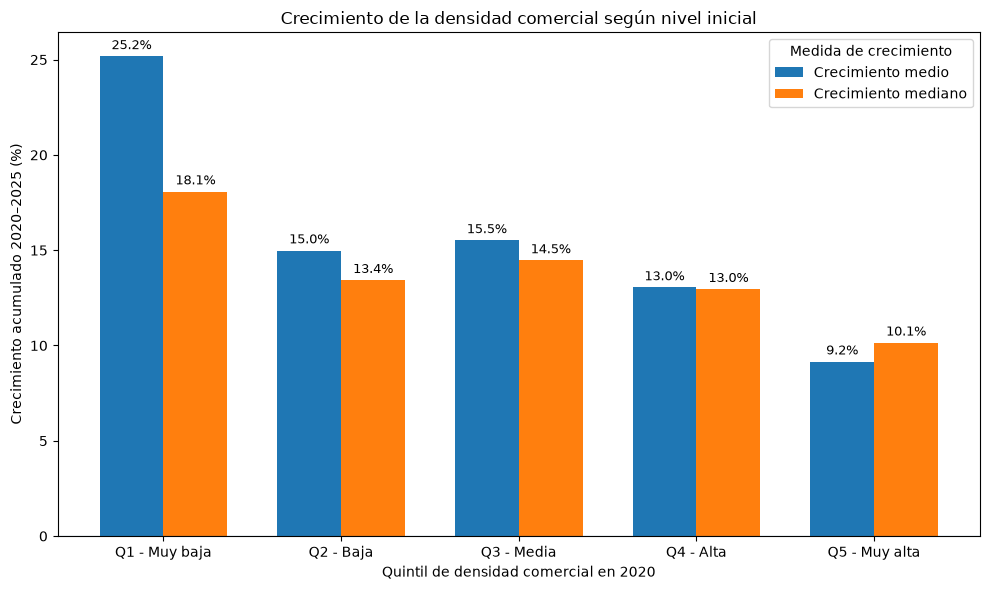

Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\crecimiento_por_quintil_densidad_inicial.png


In [33]:
# ============================================================
# Crecimiento según quintil de densidad comercial inicial
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Verificación de que la ruta de gráficas esté disponible
assert "GRAFICAS_DIR" in globals(), (
    "Ejecuta primero la celda donde se define GRAFICAS_DIR."
)

# Datos
etiquetas = resumen_quintiles[
    "QUINTIL_DENSIDAD_2020"
].astype(str)

crecimiento_medio = resumen_quintiles[
    "Crecimiento_pct_medio"
].astype(float)

crecimiento_mediano = resumen_quintiles[
    "Crecimiento_pct_mediano"
].astype(float)

# Posiciones de las barras
x = np.arange(len(etiquetas))
ancho = 0.36

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))

barras_media = ax.bar(
    x - ancho / 2,
    crecimiento_medio,
    ancho,
    label="Crecimiento medio"
)

barras_mediana = ax.bar(
    x + ancho / 2,
    crecimiento_mediano,
    ancho,
    label="Crecimiento mediano"
)

# Títulos y ejes
ax.set_title(
    "Crecimiento de la densidad comercial según nivel inicial"
)

ax.set_xlabel(
    "Quintil de densidad comercial en 2020"
)

ax.set_ylabel(
    "Crecimiento acumulado 2020–2025 (%)"
)

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)

ax.legend(
    title="Medida de crecimiento"
)

# Etiquetas sobre las barras
ax.bar_label(
    barras_media,
    labels=[
        f"{valor:.1f}%"
        for valor in crecimiento_medio
    ],
    padding=3,
    fontsize=9
)

ax.bar_label(
    barras_mediana,
    labels=[
        f"{valor:.1f}%"
        for valor in crecimiento_mediano
    ],
    padding=3,
    fontsize=9
)

# Línea de referencia en cero
ax.axhline(
    y=0,
    linewidth=0.8
)

plt.tight_layout()

# Guardar gráfica
ruta_quintiles = (
    GRAFICAS_DIR
    / "crecimiento_por_quintil_densidad_inicial.png"
)

plt.savefig(
    ruta_quintiles,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfica guardada en:")
print(ruta_quintiles)

# ============================================================
# 5.10 Dispersión: densidad inicial vs crecimiento
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df_modelado["LOG_DENSIDAD_RETAIL_2020"],
    df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"],
    alpha=0.45
)

# Línea de tendencia
x = df_modelado["LOG_DENSIDAD_RETAIL_2020"]
y = df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"]

pendiente, intercepto = np.polyfit(x, y, 1)

ax.plot(
    x.sort_values(),
    intercepto + pendiente * x.sort_values()
)

ax.set_xlabel("Logaritmo de la densidad comercial inicial (2020)")
ax.set_ylabel("Crecimiento logarítmico de la densidad 2020–2025")
ax.set_title(
    "Densidad comercial inicial y crecimiento posterior"
)

plt.tight_layout()

ruta_grafica = (
    GRAFICAS_DIR
    / "densidad_inicial_vs_crecimiento_log.png"
)

plt.savefig(
    ruta_grafica,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfica guardada en:")
print(ruta_grafica)

### Interpretación del efecto de la densidad inicial

Los resultados muestran una asociación negativa entre la densidad comercial
inicial y el crecimiento posterior de la densidad entre 2020 y 2025.

La correlación de Pearson entre la densidad inicial y el crecimiento porcentual
fue de \(r=-0.2007\), mientras que la correlación de Spearman fue de
\(\rho=-0.1700\), ambas estadísticamente significativas (\(p<0.0001\)).
La relación permanece prácticamente sin cambios al utilizar la especificación
logarítmica.

El análisis por quintiles confirma una tendencia general consistente con este
resultado. Los municipios pertenecientes al quintil de menor densidad inicial
registraron un crecimiento mediano de 18.08%, mientras que los municipios del
quintil de mayor densidad inicial presentaron un crecimiento mediano de 10.14%.

Sin embargo, la relación es de magnitud limitada y no presenta una trayectoria
perfectamente monotónica entre todos los quintiles. Además, debido a que la
densidad de 2020 forma parte matemáticamente de la tasa de crecimiento, estos
resultados deben interpretarse como evidencia de un posible efecto base y no
como prueba suficiente de convergencia económica.

Por esta razón, en las pruebas de robustez posteriores se incorporará
explícitamente la densidad comercial inicial como variable de control.

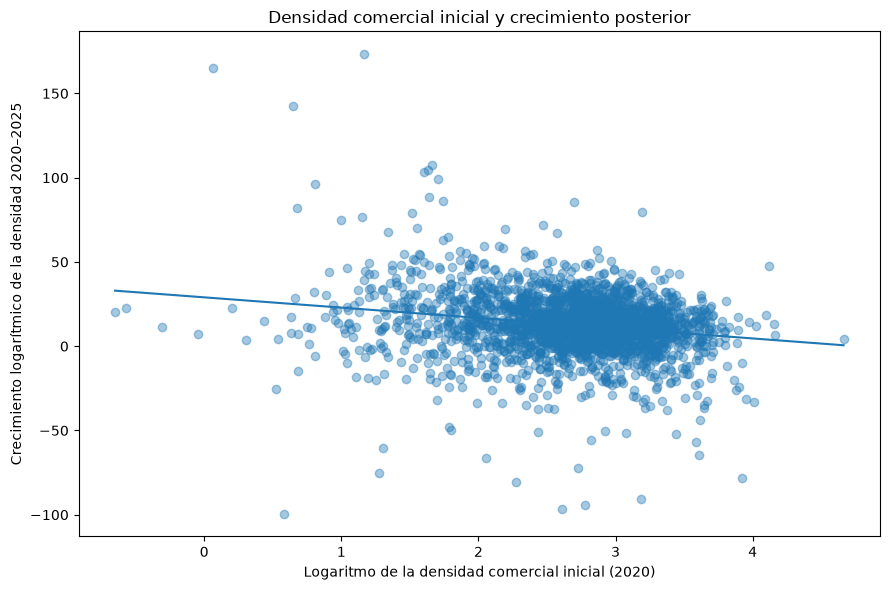

Pendiente de la recta: -6.097885964201789
Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\densidad_inicial_vs_crecimiento_log.png


In [34]:
# ============================================================
# 5.10 Dispersión: densidad inicial vs crecimiento logarítmico
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

x = df_modelado["LOG_DENSIDAD_RETAIL_2020"]
y = df_modelado["CREC_LOG_DENSIDAD_RETAIL_2020_2025"]

ax.scatter(
    x,
    y,
    alpha=0.40
)

# Recta de tendencia
pendiente, intercepto = np.polyfit(x, y, 1)

x_ordenado = np.sort(x)

ax.plot(
    x_ordenado,
    intercepto + pendiente * x_ordenado
)

ax.set_xlabel(
    "Logaritmo de la densidad comercial inicial (2020)"
)

ax.set_ylabel(
    "Crecimiento logarítmico de la densidad 2020–2025"
)

ax.set_title(
    "Densidad comercial inicial y crecimiento posterior"
)

plt.tight_layout()

ruta_grafica = (
    GRAFICAS_DIR
    / "densidad_inicial_vs_crecimiento_log.png"
)

plt.savefig(
    ruta_grafica,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Pendiente de la recta:", pendiente)
print("Gráfica guardada en:")
print(ruta_grafica)

### Interpretación gráfica

El diagrama de dispersión muestra una tendencia negativa entre el logaritmo de
la densidad comercial inicial y el crecimiento logarítmico registrado entre
2020 y 2025.

En términos generales, los municipios que presentaban menores niveles de
densidad comercial en 2020 tienden a registrar mayores tasas de crecimiento
posterior. Sin embargo, la elevada dispersión alrededor de la recta de
tendencia indica que esta relación es de magnitud limitada y que el nivel
comercial inicial no explica por sí solo las diferencias observadas entre
municipios.

La gráfica también muestra observaciones con variaciones considerablemente
superiores o inferiores al resto de la muestra. Estas observaciones no serán
eliminadas automáticamente, sino que posteriormente serán evaluadas mediante
diagnósticos de influencia.

En conjunto con las correlaciones de Pearson y Spearman y el análisis por
quintiles, estos resultados justifican incorporar la densidad comercial
inicial como variable de control en las pruebas posteriores de robustez.

Con esto se cierra el EDA complementario.

In [35]:
# ============================================================
# 6.1 Estimación MCO — Modelo 1
# Y = crecimiento de densidad
# X1 = razón de dependencia
# ============================================================

modelo_m1 = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ RAZ_DEP_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m1.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.000
Model:                                        OLS   Adj. R-squared:                 -0.000
Method:                             Least Squares   F-statistic:                   0.04612
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):              0.830
Time:                                    17:05:14   Log-Likelihood:                -11326.
No. Observations:                            2440   AIC:                         2.266e+04
Df Residuals:                                2438   BIC:                         2.267e+04
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

### Interpretación del Modelo 1

El modelo estimado fue:

\[
\widehat{Y}_i =
16.1949 -
0.0100\,RAZ\_DEP_{2020,i}
\]

La pendiente estimada de la razón de dependencia es negativa pero prácticamente
nula. Un incremento de una unidad en la razón de dependencia se asocia con una
reducción promedio de aproximadamente 0.01 puntos porcentuales en el crecimiento
acumulado de la densidad comercial.

Sin embargo, este coeficiente no es estadísticamente significativo
(\(p=0.830\)) y su intervalo de confianza al 95% incluye cero
(\([-0.101,\ 0.081]\)). Por lo tanto, no existe evidencia estadística suficiente
para afirmar que la razón de dependencia de 2020 presente una relación lineal
con el crecimiento de la densidad comercial entre 2020 y 2025.

El coeficiente de determinación es prácticamente cero, por lo que la razón de
dependencia considerada individualmente no explica una proporción relevante de
las diferencias municipales observadas en el crecimiento comercial.

Los estadísticos de normalidad de los residuos muestran una fuerte asimetría y
curtosis elevada. Por ello, antes de concluir el análisis del Modelo 1 se
realizarán diagnósticos de heterocedasticidad, errores estándar robustos y
observaciones influyentes.

In [36]:
# ============================================================
# 6.3 Prueba de heterocedasticidad — Breusch-Pagan
# Modelo 1
# ============================================================

bp_test_m1 = het_breuschpagan(
    modelo_m1.resid,
    modelo_m1.model.exog
)

resultados_bp_m1 = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m1
})

display(resultados_bp_m1)

,Estadistico,Valor
0,LM,1.0079
1,p-valor LM,0.3154
2,F,1.0074
3,p-valor F,0.3156


### Diagnóstico de heterocedasticidad

La prueba de Breusch-Pagan no proporciona evidencia estadísticamente
significativa de heterocedasticidad en el Modelo 1.

El estadístico LM fue de 1.0079 con un valor-p de 0.3154, mientras que
la versión basada en el estadístico F produjo un valor-p de 0.3156.
Dado que ambos valores son superiores al nivel de significancia de 0.05,
no se rechaza la hipótesis nula de varianza constante de los errores.

Por lo tanto, la prueba no identifica una violación significativa del
supuesto de homocedasticidad para esta especificación. No obstante,
se estimarán también errores estándar robustos HC3 como análisis de
robustez y para mantener un criterio de inferencia uniforme entre los
modelos.

In [37]:
# ============================================================
# 6.4 Errores estándar robustos HC3
# Modelo 1
# ============================================================

modelo_m1_hc3 = modelo_m1.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m1_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.000
Model:                                        OLS   Adj. R-squared:                 -0.000
Method:                             Least Squares   F-statistic:                   0.04340
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):              0.835
Time:                                    17:05:23   Log-Likelihood:                -11326.
No. Observations:                            2440   AIC:                         2.266e+04
Df Residuals:                                2438   BIC:                         2.267e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

In [38]:
# ============================================================
# 6.5 Comparación MCO clásico vs HC3
# ============================================================

comparacion_m1 = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_X1": [
        modelo_m1.params["RAZ_DEP_2020"],
        modelo_m1_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m1.bse["RAZ_DEP_2020"],
        modelo_m1_hc3.bse[1]
    ],
    "t": [
        modelo_m1.tvalues["RAZ_DEP_2020"],
        modelo_m1_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m1.pvalues["RAZ_DEP_2020"],
        modelo_m1_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m1.conf_int().loc[
            "RAZ_DEP_2020", 0
        ],
        modelo_m1_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m1.conf_int().loc[
            "RAZ_DEP_2020", 1
        ],
        modelo_m1_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m1)

,Estimacion,Coeficiente_X1,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,-0.0100,0.0464,-0.2148,0.8300,-0.1011,0.0811
1,MCO + HC3,-0.0100,0.0479,-0.2083,0.8350,-0.1039,0.0839


### Robustez de la inferencia con HC3

La estimación mediante errores estándar robustos HC3 no modifica la conclusión
del Modelo 1. El coeficiente asociado con la razón de dependencia permanece en
-0.0100, mientras que su error estándar cambia ligeramente de 0.0464 bajo MCO
clásico a 0.0479 con HC3.

El valor-p pasa de 0.8300 a 0.8350 y ambos intervalos de confianza al 95%
incluyen el valor cero. Por lo tanto, la ausencia de significancia estadística
de la razón de dependencia no depende del uso de errores estándar
convencionales o robustos.

Este resultado, junto con la prueba de Breusch-Pagan, indica que la conclusión
inferencial del Modelo 1 es estable frente a posibles problemas de
heterocedasticidad.

6.6 Diagnóstico de observaciones influyentes

Ahora vamos al siguiente problema que detectamos desde el principio: ¿unos pocos municipios extremos están afectando el modelo?

Vamos a calcular tres cosas:

Leverage
	​

Residuo studentizado
	​

Cook’s Distance
	​

¿Qué significa cada uno?

Leverage h
ii
	​

: identifica municipios con valores de RAZ_DEP_2020 alejados del centro de la muestra.

Residuo studentizado: identifica municipios donde el valor observado de Y está muy lejos de lo que predice el modelo.

Cook's Distance D
i
	​

: combina ambos conceptos y responde:
¿Qué tanto podría cambiar la regresión si retiráramos ese municipio?

Importante: una observación señalada no será eliminada automáticamente.

In [39]:
# ============================================================
# 6.6 Diagnóstico de influencia — Modelo 1
# ============================================================

influencia_m1 = OLSInfluence(modelo_m1)

# Número de observaciones
n_m1 = int(modelo_m1.nobs)

# Número de parámetros, incluyendo intercepto
p_m1 = len(modelo_m1.params)

# Umbrales diagnósticos
umbral_leverage = 2 * p_m1 / n_m1
umbral_cook = 4 / n_m1

# Medidas de influencia
leverage_m1 = influencia_m1.hat_matrix_diag
resid_student_m1 = influencia_m1.resid_studentized_external
cook_m1 = influencia_m1.cooks_distance[0]

diagnostico_influencia_m1 = df_modelado[
    [
        "CVEGEO",
        "entidad",
        "municipio",
        "RAZ_DEP_2020",
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ]
].copy()

diagnostico_influencia_m1["VALOR_AJUSTADO"] = modelo_m1.fittedvalues
diagnostico_influencia_m1["RESIDUO"] = modelo_m1.resid
diagnostico_influencia_m1["RESIDUO_STUDENT"] = resid_student_m1
diagnostico_influencia_m1["LEVERAGE"] = leverage_m1
diagnostico_influencia_m1["COOK_D"] = cook_m1

# Banderas diagnósticas
diagnostico_influencia_m1["FLAG_STUDENT"] = (
    diagnostico_influencia_m1["RESIDUO_STUDENT"].abs() > 3
)

diagnostico_influencia_m1["FLAG_LEVERAGE"] = (
    diagnostico_influencia_m1["LEVERAGE"] > umbral_leverage
)

diagnostico_influencia_m1["FLAG_COOK"] = (
    diagnostico_influencia_m1["COOK_D"] > umbral_cook
)

print(f"N = {n_m1}")
print(f"Parámetros incluidos intercepto = {p_m1}")

print(f"\nUmbral leverage 2p/n = {umbral_leverage:.6f}")
print(f"Umbral Cook 4/n = {umbral_cook:.6f}")

print(
    "\nResiduos studentizados |r| > 3:",
    diagnostico_influencia_m1["FLAG_STUDENT"].sum()
)

print(
    "Leverage > 2p/n:",
    diagnostico_influencia_m1["FLAG_LEVERAGE"].sum()
)

print(
    "Cook D > 4/n:",
    diagnostico_influencia_m1["FLAG_COOK"].sum()
)

N = 2440
Parámetros incluidos intercepto = 2

Umbral leverage 2p/n = 0.001639
Umbral Cook 4/n = 0.001639

Residuos studentizados |r| > 3: 25
Leverage > 2p/n: 183
Cook D > 4/n: 82


In [40]:
# ============================================================
# 6.7 Municipios con mayor Cook's Distance
# ============================================================

top_cook_m1 = (
    diagnostico_influencia_m1
    .sort_values(
        "COOK_D",
        ascending=False
    )
    .head(15)
)

display(
    top_cook_m1[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "RAZ_DEP_2020",
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "RESIDUO_STUDENT",
            "LEVERAGE",
            "COOK_D"
        ]
    ]
)

,CVEGEO,entidad,municipio,RAZ_DEP_2020,CREC_DENSIDAD_RETAIL_2020_2025,RESIDUO_STUDENT,LEVERAGE,COOK_D
433,12078,GUERRERO,Cochoapa el Grande,115.8900,110.8380,3.8464,0.0103,0.0763
1704,21148,PUEBLA,Santa Isabel Cholula,62.0600,465.2009,19.2186,0.0004,0.0658
1997,28036,TAMAULIPAS,San Nicolás,60.8200,420.0000,17.0412,0.0004,0.0541
945,19010,NUEVO LEÓN,El Carmen,53.2800,317.0675,12.3788,0.0007,0.0494
1467,20481,OAXACA,Santiago Nuyoó,83.4800,136.8722,4.8672,0.0020,0.0230
1125,20139,OAXACA,San Francisco Chapulapa,78.1700,161.8486,5.8764,0.0013,0.0218
2276,31001,YUCATÁN,Abalá,52.1000,193.2865,7.1496,0.0008,0.0191
1437,20451,OAXACA,Santiago Apoala,105.7200,72.5393,2.2962,0.0069,0.0182
98,07024,CHIAPAS,Chanal,111.6900,63.8973,1.9542,0.0088,0.0169
1776,22003,QUERÉTARO,Arroyo Seco,71.8100,180.3117,6.6255,0.0007,0.0156


### Interpretación del diagnóstico de influencia

El análisis identificó 25 municipios con residuos studentizados externos
superiores a 3 en valor absoluto, 183 municipios con leverage superior al
criterio \(2p/n\) y 82 observaciones con una distancia de Cook superior al
criterio exploratorio \(4/n\).

Estos criterios deben interpretarse como herramientas de detección y no como
reglas automáticas de eliminación. En particular, algunos municipios presentan
valores extremos principalmente en el crecimiento de la densidad comercial,
mientras que otros presentan valores relativamente extremos en la razón de
dependencia.

La mayor distancia de Cook observada fue aproximadamente 0.0763. Por lo tanto,
aunque existen observaciones que pueden ejercer influencia sobre la estimación,
no se eliminarán municipios exclusivamente con base en estos indicadores.

En las siguientes etapas se evaluará si las conclusiones del modelo cambian
materialmente al realizar análisis de sensibilidad y al utilizar una
especificación logarítmica de la variable dependiente.

¿Qué municipios están influyendo específicamente sobre el coeficiente de RAZ_DEP_2020?

In [41]:
# ============================================================
# 6.8 DFBETAS — Influencia sobre beta de RAZ_DEP_2020
# ============================================================

dfbetas_m1 = influencia_m1.dfbetas

# Columna 0 = intercepto
# Columna 1 = RAZ_DEP_2020
dfbeta_x1 = dfbetas_m1[:, 1]

diagnostico_influencia_m1["DFBETA_RAZ_DEP"] = dfbeta_x1

# Criterio exploratorio habitual
umbral_dfbeta = 2 / np.sqrt(n_m1)

diagnostico_influencia_m1["FLAG_DFBETA"] = (
    diagnostico_influencia_m1["DFBETA_RAZ_DEP"].abs()
    > umbral_dfbeta
)

print(
    f"Umbral DFBETAS 2/sqrt(n) = {umbral_dfbeta:.6f}"
)

print(
    "Municipios que superan el umbral:",
    diagnostico_influencia_m1["FLAG_DFBETA"].sum()
)

top_dfbeta_m1 = (
    diagnostico_influencia_m1
    .assign(
        ABS_DFBETA=lambda x:
        x["DFBETA_RAZ_DEP"].abs()
    )
    .sort_values(
        "ABS_DFBETA",
        ascending=False
    )
    .head(15)
)

display(
    top_dfbeta_m1[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "RAZ_DEP_2020",
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "DFBETA_RAZ_DEP",
            "LEVERAGE",
            "COOK_D"
        ]
    ]
)

Umbral DFBETAS 2/sqrt(n) = 0.040489
Municipios que superan el umbral: 109


,CVEGEO,entidad,municipio,RAZ_DEP_2020,CREC_DENSIDAD_RETAIL_2020_2025,DFBETA_RAZ_DEP,LEVERAGE,COOK_D
433,12078,GUERRERO,Cochoapa el Grande,115.8900,110.8380,0.3837,0.0103,0.0763
945,19010,NUEVO LEÓN,El Carmen,53.2800,317.0675,-0.2052,0.0007,0.0494
1467,20481,OAXACA,Santiago Nuyoó,83.4800,136.8722,0.1915,0.0020,0.0230
1437,20451,OAXACA,Santiago Apoala,105.7200,72.5393,0.1853,0.0069,0.0182
98,07024,CHIAPAS,Chanal,111.6900,63.8973,0.1796,0.0088,0.0169
1125,20139,OAXACA,San Francisco Chapulapa,78.1700,161.8486,0.1733,0.0013,0.0218
1096,20110,OAXACA,San Antonio Sinicahua,87.1100,101.0915,0.1579,0.0025,0.0148
1434,20448,OAXACA,Santa María Zaniza,87.9900,95.3687,0.1526,0.0027,0.0137
1182,20196,OAXACA,San Juan Evangelista Analco,88.6400,-59.6107,-0.1464,0.0028,0.0125
1185,20199,OAXACA,San Juan Ihualtepec,105.8100,-29.4452,-0.1442,0.0069,0.0110


### Interpretación de DFBETAS

El diagnóstico DFBETAS identificó 109 municipios, equivalentes a
aproximadamente 4.47% de la muestra, cuyo efecto sobre el coeficiente de la
razón de dependencia supera el criterio exploratorio \(2/\sqrt{n}\).

La observación con mayor influencia presenta un DFBETAS absoluto de
aproximadamente 0.384. Aunque existen municipios que influyen en la estimación
de la pendiente, las magnitudes observadas no justifican su eliminación
automática.

El modelo estimado con la muestra completa se conservará como especificación
principal. Posteriormente se realizará una estimación de sensibilidad
excluyendo temporalmente las observaciones señaladas, con el único propósito
de determinar si el signo, la magnitud y la significancia estadística del
coeficiente dependen de estos municipios.

In [42]:
# ============================================================
# 6.9 Análisis de sensibilidad — Modelo 1
# Exclusión temporal de observaciones señaladas por DFBETAS
# ============================================================

indices_dfbeta_m1 = diagnostico_influencia_m1.index[
    diagnostico_influencia_m1["FLAG_DFBETA"]
]

df_sensibilidad_m1 = df_modelado.drop(
    index=indices_dfbeta_m1
).copy()

print("Muestra original:", len(df_modelado))
print("Observaciones retiradas temporalmente:", len(indices_dfbeta_m1))
print("Muestra de sensibilidad:", len(df_sensibilidad_m1))
print(
    "Porcentaje temporalmente excluido:",
    f"{len(indices_dfbeta_m1) / len(df_modelado) * 100:.2f}%"
)

Muestra original: 2440
Observaciones retiradas temporalmente: 109
Muestra de sensibilidad: 2331
Porcentaje temporalmente excluido: 4.47%


In [43]:
# ============================================================
# 6.10 Reestimación de M1 — Muestra de sensibilidad
# ============================================================

modelo_m1_sens = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ RAZ_DEP_2020"
    ),
    data=df_sensibilidad_m1
).fit()

modelo_m1_sens_hc3 = modelo_m1_sens.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m1_sens_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.001
Model:                                        OLS   Adj. R-squared:                  0.000
Method:                             Least Squares   F-statistic:                     2.291
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):              0.130
Time:                                    17:06:07   Log-Likelihood:                -10239.
No. Observations:                            2331   AIC:                         2.048e+04
Df Residuals:                                2329   BIC:                         2.049e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad muestra que las observaciones identificadas mediante
DFBETAS ejercen influencia sobre la magnitud y dirección del coeficiente asociado
con la razón de dependencia.

En la muestra completa, utilizando errores estándar robustos HC3, el coeficiente
estimado fue de -0.0100 (\(p=0.835\)). Al excluir temporalmente los 109 municipios
señalados por el criterio DFBETAS, el coeficiente cambia a 0.0453
(\(p=0.130\)).

Por lo tanto, el signo del coeficiente no es robusto frente a las observaciones
influyentes. Sin embargo, la conclusión estadística permanece: en ambas
especificaciones el intervalo de confianza al 95% contiene cero y no existe
evidencia suficiente para rechazar la hipótesis nula de ausencia de asociación
lineal.

Además, la capacidad explicativa permanece prácticamente nula
(\(R^2 \approx 0.001\) en la muestra de sensibilidad).

En consecuencia, el modelo con la muestra completa se mantiene como
especificación principal y las observaciones no serán eliminadas. El resultado
de sensibilidad se utiliza únicamente para documentar que la dirección estimada
del efecto es inestable, mientras que la ausencia de significancia estadística
es robusta.

In [44]:
# ============================================================
# 6.11 Comparación final — M1 completo vs sensibilidad
# ============================================================

comparacion_sensibilidad_m1 = pd.DataFrame({
    "Modelo": [
        "M1 completo + HC3",
        "M1 sensibilidad + HC3"
    ],
    "N": [
        int(modelo_m1.nobs),
        int(modelo_m1_sens.nobs)
    ],
    "Coeficiente_RAZ_DEP": [
        modelo_m1_hc3.params[1],
        modelo_m1_sens_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m1_hc3.bse[1],
        modelo_m1_sens_hc3.bse[1]
    ],
    "Valor_p": [
        modelo_m1_hc3.pvalues[1],
        modelo_m1_sens_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m1_hc3.conf_int()[1, 0],
        modelo_m1_sens_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m1_hc3.conf_int()[1, 1],
        modelo_m1_sens_hc3.conf_int()[1, 1]
    ],
    "R2": [
        modelo_m1.rsquared,
        modelo_m1_sens.rsquared
    ]
})

display(comparacion_sensibilidad_m1)

,Modelo,N,Coeficiente_RAZ_DEP,Error_estandar,Valor_p,IC_95_inf,IC_95_sup,R2
0,M1 completo + HC3,2440,-0.0100,0.0479,0.8350,-0.1039,0.0839,0.0000
1,M1 sensibilidad + HC3,2331,0.0453,0.0299,0.1302,-0.0134,0.1041,0.0005


### 6.12 Robustez del Modelo 1 mediante crecimiento logarítmico

Como prueba de robustez se estima nuevamente la relación entre la razón de
dependencia y el crecimiento de la densidad comercial utilizando como variable
dependiente el cambio logarítmico:

\[
Y_{\log,i}
=
100\left[
\ln(D_{2025,i})-\ln(D_{2020,i})
\right]
\]

El modelo estimado es:

\[
Y_{\log,i}
=
\beta_0+
\beta_1 RAZ\_DEP_{2020,i}
+\varepsilon_i
\]

La finalidad de esta especificación no es buscar una mayor significancia
estadística, sino evaluar si la dirección, magnitud y conclusión inferencial
del Modelo 1 permanecen cuando se utiliza una medida de crecimiento menos
sensible a tasas porcentuales extremas.

In [45]:
# ============================================================
# 6.12 Modelo 1 con crecimiento logarítmico
# ============================================================

modelo_m1_log = ols(
    formula=(
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025 "
        "~ RAZ_DEP_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m1_log.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.001
Model:                                            OLS   Adj. R-squared:                  0.001
Method:                                 Least Squares   F-statistic:                     2.968
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):             0.0850
Time:                                        17:06:16   Log-Likelihood:                -10593.
No. Observations:                                2440   AIC:                         2.119e+04
Df Residuals:                                    2438   BIC:                         2.120e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                   coef    std err          t     

### Interpretación de la especificación logarítmica

La estimación utilizando el crecimiento logarítmico de la densidad comercial
produce un coeficiente de -0.0593 para la razón de dependencia.

El coeficiente mantiene una dirección negativa, pero no alcanza significancia
estadística al nivel del 5% (\(p=0.085\)). Asimismo, el intervalo de confianza
al 95% incluye el valor cero, por lo que no existe evidencia estadística
suficiente para afirmar que la razón de dependencia se encuentre asociada
linealmente con el crecimiento logarítmico de la densidad comercial.

La transformación logarítmica produce, sin embargo, una mejora importante en
la distribución de los residuos. La asimetría disminuye sustancialmente
respecto a la especificación porcentual, aunque la curtosis permanece elevada
y la prueba de Jarque-Bera continúa rechazando la normalidad.

La capacidad explicativa del modelo sigue siendo prácticamente nula
(\(R^2 \approx 0.001\)). Por lo tanto, la transformación mejora la estabilidad
distributiva de la variable dependiente, pero no modifica la conclusión
económica principal: la razón de dependencia considerada individualmente
presenta una capacidad explicativa muy limitada sobre el crecimiento comercial.

In [46]:
# ============================================================
# 6.13 Breusch-Pagan — M1 con Y logarítmica
# ============================================================

bp_test_m1_log = het_breuschpagan(
    modelo_m1_log.resid,
    modelo_m1_log.model.exog
)

resultados_bp_m1_log = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m1_log
})

display(resultados_bp_m1_log)

,Estadistico,Valor
0,LM,25.5720
1,p-valor LM,0.0000
2,F,25.8217
3,p-valor F,0.0000


### Diagnóstico de heterocedasticidad de la especificación logarítmica

La prueba de Breusch-Pagan aplicada al Modelo 1 con crecimiento logarítmico
produce un estadístico LM de 25.5720 y un estadístico F de 25.8217, con
valores-p inferiores a 0.0001.

Por lo tanto, se rechaza la hipótesis nula de homocedasticidad y existe
evidencia estadísticamente significativa de que la varianza de los errores no
permanece constante en esta especificación.

Este resultado no contradice la mejora observada en la distribución de los
residuos después de aplicar la transformación logarítmica. La normalidad,
simetría y homocedasticidad corresponden a propiedades diferentes del modelo.
La transformación logarítmica reduce considerablemente la asimetría, pero no
elimina la heterocedasticidad.

Por esta razón, la inferencia del modelo logarítmico se realizará utilizando
errores estándar robustos HC3.

In [47]:
# ============================================================
# 6.14 Errores estándar robustos HC3
# M1 con crecimiento logarítmico
# ============================================================

modelo_m1_log_hc3 = modelo_m1_log.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m1_log_hc3.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.001
Model:                                            OLS   Adj. R-squared:                  0.001
Method:                                 Least Squares   F-statistic:                     2.192
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):              0.139
Time:                                        17:06:24   Log-Likelihood:                -10593.
No. Observations:                                2440   AIC:                         2.119e+04
Df Residuals:                                    2438   BIC:                         2.120e+04
Df Model:                                           1                                         
Covariance Type:                                  HC3                                         
                   coef    std err          t     

### Interpretación de la inferencia robusta en la especificación logarítmica

La estimación con errores estándar robustos HC3 mantiene el coeficiente de la
razón de dependencia en -0.0593, pero incrementa su error estándar de
aproximadamente 0.034 a 0.040.

Como consecuencia, el valor-p aumenta de 0.085 bajo la inferencia convencional
a 0.139 utilizando HC3. El intervalo de confianza robusto al 95% se ubica
aproximadamente entre -0.138 y 0.019 e incluye el valor cero.

Dado que la prueba de Breusch-Pagan identificó heterocedasticidad en la
especificación logarítmica, la inferencia robusta HC3 se considera más
apropiada para evaluar la significancia del coeficiente.

Por lo tanto, no existe evidencia estadística suficiente para afirmar que la
razón de dependencia de 2020 se encuentre asociada linealmente con el
crecimiento logarítmico de la densidad comercial entre 2020 y 2025.

La transformación logarítmica mejora considerablemente la simetría de los
residuos, pero no incrementa de manera relevante la capacidad explicativa del
modelo.

In [48]:
# ============================================================
# 6.15 Comparación de especificaciones — Modelo 1
# ============================================================

comparacion_final_m1 = pd.DataFrame({
    "Especificacion": [
        "Y porcentual - MCO",
        "Y porcentual - HC3",
        "Y logarítmica - MCO",
        "Y logarítmica - HC3"
    ],

    "Coeficiente_RAZ_DEP": [
        modelo_m1.params["RAZ_DEP_2020"],
        modelo_m1_hc3.params[1],
        modelo_m1_log.params["RAZ_DEP_2020"],
        modelo_m1_log_hc3.params[1]
    ],

    "Error_estandar": [
        modelo_m1.bse["RAZ_DEP_2020"],
        modelo_m1_hc3.bse[1],
        modelo_m1_log.bse["RAZ_DEP_2020"],
        modelo_m1_log_hc3.bse[1]
    ],

    "Valor_p": [
        modelo_m1.pvalues["RAZ_DEP_2020"],
        modelo_m1_hc3.pvalues[1],
        modelo_m1_log.pvalues["RAZ_DEP_2020"],
        modelo_m1_log_hc3.pvalues[1]
    ],

    "IC_95_inf": [
        modelo_m1.conf_int().loc["RAZ_DEP_2020", 0],
        modelo_m1_hc3.conf_int()[1, 0],
        modelo_m1_log.conf_int().loc["RAZ_DEP_2020", 0],
        modelo_m1_log_hc3.conf_int()[1, 0]
    ],

    "IC_95_sup": [
        modelo_m1.conf_int().loc["RAZ_DEP_2020", 1],
        modelo_m1_hc3.conf_int()[1, 1],
        modelo_m1_log.conf_int().loc["RAZ_DEP_2020", 1],
        modelo_m1_log_hc3.conf_int()[1, 1]
    ],

    "R2": [
        modelo_m1.rsquared,
        modelo_m1.rsquared,
        modelo_m1_log.rsquared,
        modelo_m1_log.rsquared
    ]
})

display(comparacion_final_m1)

,Especificacion,Coeficiente_RAZ_DEP,Error_estandar,Valor_p,IC_95_inf,IC_95_sup,R2
0,Y porcentual - MCO,-0.0100,0.0464,0.8300,-0.1011,0.0811,0.0000
1,Y porcentual - HC3,-0.0100,0.0479,0.8350,-0.1039,0.0839,0.0000
2,Y logarítmica - MCO,-0.0593,0.0344,0.0850,-0.1267,0.0082,0.0012
3,Y logarítmica - HC3,-0.0593,0.0400,0.1389,-0.1378,0.0192,0.0012


In [49]:
# ============================================================
# 6.16 Influencia — M1 con Y logarítmica
# ============================================================

influencia_m1_log = OLSInfluence(modelo_m1_log)

n_m1_log = int(modelo_m1_log.nobs)
p_m1_log = len(modelo_m1_log.params)

# Mismos criterios diagnósticos
umbral_leverage_log = 2 * p_m1_log / n_m1_log
umbral_cook_log = 4 / n_m1_log
umbral_dfbeta_log = 2 / np.sqrt(n_m1_log)

# Medidas
resid_student_log = influencia_m1_log.resid_studentized_external
leverage_log = influencia_m1_log.hat_matrix_diag
cook_log = influencia_m1_log.cooks_distance[0]
dfbeta_log = influencia_m1_log.dfbetas[:, 1]

# Conteos
n_student_log = (np.abs(resid_student_log) > 3).sum()
n_leverage_log = (leverage_log > umbral_leverage_log).sum()
n_cook_log = (cook_log > umbral_cook_log).sum()
n_dfbeta_log = (np.abs(dfbeta_log) > umbral_dfbeta_log).sum()

print(f"Umbral leverage: {umbral_leverage_log:.6f}")
print(f"Umbral Cook: {umbral_cook_log:.6f}")
print(f"Umbral DFBETAS: {umbral_dfbeta_log:.6f}")

print("\nM1 LOGARÍTMICO")
print("Residuos studentizados |r| > 3:", n_student_log)
print("Leverage > 2p/n:", n_leverage_log)
print("Cook D > 4/n:", n_cook_log)
print("DFBETAS > 2/sqrt(n):", n_dfbeta_log)
print("Máximo Cook D:", cook_log.max())
print("Máximo |DFBETAS|:", np.abs(dfbeta_log).max())

Umbral leverage: 0.001639
Umbral Cook: 0.001639
Umbral DFBETAS: 0.040489

M1 LOGARÍTMICO
Residuos studentizados |r| > 3: 40
Leverage > 2p/n: 183
Cook D > 4/n: 128
DFBETAS > 2/sqrt(n): 128
Máximo Cook D: 0.06422883875235277
Máximo |DFBETAS|: 0.3520031092034801


In [50]:
# ============================================================
# 6.17 Comparación de influencia
# Y porcentual vs Y logarítmica
# ============================================================

comparacion_influencia_m1 = pd.DataFrame({
    "Diagnostico": [
        "|Residuo studentizado| > 3",
        "Leverage > 2p/n",
        "Cook D > 4/n",
        "|DFBETAS| > 2/sqrt(n)",
        "Máximo Cook D",
        "Máximo |DFBETAS|"
    ],
    "Y_porcentual": [
        diagnostico_influencia_m1["FLAG_STUDENT"].sum(),
        diagnostico_influencia_m1["FLAG_LEVERAGE"].sum(),
        diagnostico_influencia_m1["FLAG_COOK"].sum(),
        diagnostico_influencia_m1["FLAG_DFBETA"].sum(),
        diagnostico_influencia_m1["COOK_D"].max(),
        diagnostico_influencia_m1["DFBETA_RAZ_DEP"].abs().max()
    ],
    "Y_logaritmica": [
        n_student_log,
        n_leverage_log,
        n_cook_log,
        n_dfbeta_log,
        cook_log.max(),
        np.abs(dfbeta_log).max()
    ]
})

display(comparacion_influencia_m1)

,Diagnostico,Y_porcentual,Y_logaritmica
0,|Residuo studentizado| > 3,25.0000,40.0000
1,Leverage > 2p/n,183.0000,183.0000
2,Cook D > 4/n,82.0000,128.0000
3,|DFBETAS| > 2/sqrt(n),109.0000,128.0000
4,Máximo Cook D,0.0763,0.0642
5,Máximo |DFBETAS|,0.3837,0.3520


### Interpretación comparativa de la influencia

La transformación logarítmica modifica el patrón de influencia de las
observaciones, pero no elimina la presencia de municipios potencialmente
influyentes.

El número de observaciones que supera los criterios exploratorios aumenta en
la especificación logarítmica. Los residuos studentizados superiores a 3 en
valor absoluto pasan de 25 a 40, mientras que los municipios que superan el
criterio de Cook aumentan de 82 a 128 y aquellos que superan el criterio
DFBETAS pasan de 109 a 128.

El número de observaciones con leverage elevado permanece sin cambios en 183,
lo cual es esperable debido a que esta medida depende de la distribución de la
variable explicativa y no de la transformación aplicada a la variable
dependiente.

Sin embargo, la intensidad máxima de la influencia disminuye. La mayor
distancia de Cook pasa de aproximadamente 0.0763 a 0.0642 y el máximo valor
absoluto de DFBETAS disminuye de 0.3837 a 0.3520.

Por lo tanto, la transformación logarítmica no elimina las observaciones
influyentes, aunque reduce ligeramente la influencia individual de los casos
más extremos. Estos resultados refuerzan la decisión de conservar la muestra
completa y utilizar diagnósticos y errores estándar robustos en lugar de
eliminar observaciones de manera automática.

La conclusión académica sería:

La razón de dependencia municipal de 2020 no presenta evidencia robusta de una asociación lineal con el crecimiento de la densidad comercial minorista entre 2020 y 2025. La capacidad explicativa individual de la variable es prácticamente nula. Además, el signo estimado es sensible a observaciones influyentes, por lo que tampoco existe evidencia suficiente para sostener una dirección positiva o negativa estable de la relación.

7. Modelo 2 — Escolaridad

El modelo será:

Yi= β0 + β1GRAPROES2020,i + εi
	
donde:

Yi: crecimiento porcentual acumulado de la densidad comercial minorista 2020–2025.

GRAPROES2020,i: grado promedio de escolaridad del municipio en 2020.
β1: cambio promedio en el crecimiento de la densidad comercial asociado con un año adicional de escolaridad promedio.
εi: factores no incluidos en el modelo.    


# 7. Modelo 2: Escolaridad

## 7.1 Especificación del modelo

El segundo modelo analiza la relación entre el grado promedio de escolaridad
municipal observado en 2020 y el crecimiento de la densidad comercial
minorista registrado entre 2020 y 2025.

La especificación es:

\[
Y_i =
\beta_0 +
\beta_1 GRAPROES_{2020,i} +
\varepsilon_i
\]

donde \(GRAPROES_{2020}\) representa el número promedio de años de escolaridad
de la población municipal.

El coeficiente \(\beta_1\) mide la variación promedio asociada en el crecimiento
de la densidad comercial ante un incremento de un año en el grado promedio de
escolaridad.

La interpretación del modelo será asociativa y no causal.

In [51]:
# ============================================================
# 7.2 Estimación MCO — Modelo 2
# Y = crecimiento de densidad
# X2 = grado promedio de escolaridad
# ============================================================

modelo_m2 = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ GRAPROES_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m2.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.005
Model:                                        OLS   Adj. R-squared:                  0.005
Method:                             Least Squares   F-statistic:                     12.33
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           0.000453
Time:                                    17:06:43   Log-Likelihood:                -11319.
No. Observations:                            2440   AIC:                         2.264e+04
Df Residuals:                                2438   BIC:                         2.265e+04
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------

### Interpretación del Modelo 2

El Modelo 2 estima una asociación negativa entre el grado promedio de
escolaridad municipal y el crecimiento de la densidad comercial minorista.

El coeficiente estimado para `GRAPROES_2020` es de -1.1986. Esto indica que
un año adicional en el grado promedio de escolaridad se encuentra asociado,
en promedio, con aproximadamente 1.20 puntos porcentuales menos de crecimiento
acumulado de la densidad comercial entre 2020 y 2025.

El coeficiente es estadísticamente significativo
(\(p \approx 0.00045\)) y su intervalo de confianza al 95%
(\([-1.868,-0.529]\)) no contiene el valor cero. Por lo tanto, bajo la
especificación MCO convencional se rechaza la hipótesis nula de ausencia de
relación lineal.

Sin embargo, el coeficiente de determinación es únicamente \(R^2=0.005\),
por lo que la escolaridad considerada individualmente explica aproximadamente
0.5% de la variabilidad municipal observada en el crecimiento de la densidad
comercial.

En consecuencia, la relación es estadísticamente detectable, pero presenta
una capacidad explicativa limitada. El signo negativo no debe interpretarse
causalmente y será evaluado posteriormente mediante errores estándar robustos,
diagnósticos de influencia, especificaciones alternativas y regresión múltiple.

In [52]:
# ============================================================
# 7.3 Prueba de heterocedasticidad — Breusch-Pagan
# Modelo 2
# ============================================================

bp_test_m2 = het_breuschpagan(
    modelo_m2.resid,
    modelo_m2.model.exog
)

resultados_bp_m2 = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m2
})

display(resultados_bp_m2)

,Estadistico,Valor
0,LM,1.7703
1,p-valor LM,0.1833
2,F,1.7701
3,p-valor F,0.1835


### Diagnóstico de heterocedasticidad

La prueba de Breusch-Pagan aplicada al Modelo 2 produce un estadístico LM de
1.7703 con un valor-p de 0.1833 y un estadístico F de 1.7701 con un valor-p
de 0.1835.

Dado que ambos valores-p son superiores al nivel de significancia de 0.05,
no se rechaza la hipótesis nula de varianza constante de los errores.

Por lo tanto, la prueba no proporciona evidencia estadísticamente significativa
de heterocedasticidad en la regresión simple entre escolaridad y crecimiento de
la densidad comercial.

No obstante, se estimarán errores estándar robustos HC3 para evaluar la
estabilidad de la inferencia y mantener el mismo criterio metodológico aplicado
al resto de los modelos.

In [53]:
# ============================================================
# 7.4 Errores estándar robustos HC3
# Modelo 2
# ============================================================

modelo_m2_hc3 = modelo_m2.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m2_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.005
Model:                                        OLS   Adj. R-squared:                  0.005
Method:                             Least Squares   F-statistic:                     15.37
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           9.10e-05
Time:                                    17:06:50   Log-Likelihood:                -11319.
No. Observations:                            2440   AIC:                         2.264e+04
Df Residuals:                                2438   BIC:                         2.265e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------

In [55]:
# ============================================================
# 7.5 Comparación MCO clásico vs HC3 — Modelo 2
# ============================================================

comparacion_m2 = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_GRAPROES": [
        modelo_m2.params["GRAPROES_2020"],
        modelo_m2_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m2.bse["GRAPROES_2020"],
        modelo_m2_hc3.bse[1]
    ],
    "t": [
        modelo_m2.tvalues["GRAPROES_2020"],
        modelo_m2_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m2.pvalues["GRAPROES_2020"],
        modelo_m2_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m2.conf_int().loc["GRAPROES_2020", 0],
        modelo_m2_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m2.conf_int().loc["GRAPROES_2020", 1],
        modelo_m2_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m2)

,Estimacion,Coeficiente_GRAPROES,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,-1.1986,0.3413,-3.5119,0.0005,-1.8678,-0.5293
1,MCO + HC3,-1.1986,0.3058,-3.9200,0.0001,-1.7981,-0.5990


### Robustez de la inferencia con HC3

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
asociado con el grado promedio de escolaridad en -1.1986.

El error estándar disminuye de 0.3413 en la estimación convencional a 0.3058
con HC3, mientras que el valor-p pasa de aproximadamente 0.0005 a 0.0001.
Asimismo, el intervalo de confianza robusto al 95% se mantiene completamente
por debajo de cero.

Por lo tanto, la asociación negativa entre escolaridad y crecimiento de la
densidad comercial permanece estadísticamente significativa al utilizar
errores estándar robustos.

Sin embargo, el coeficiente de determinación continúa siendo bajo
(\(R^2=0.005\)), por lo que la escolaridad considerada individualmente explica
aproximadamente 0.5% de la variabilidad municipal del crecimiento comercial.
La relación se interpreta como asociativa y no causal.

In [56]:
# ============================================================
# 7.6 Diagnóstico de influencia — Modelo 2
# ============================================================

influencia_m2 = OLSInfluence(modelo_m2)

n_m2 = int(modelo_m2.nobs)
p_m2 = len(modelo_m2.params)

# Umbrales
umbral_leverage_m2 = 2 * p_m2 / n_m2
umbral_cook_m2 = 4 / n_m2
umbral_dfbeta_m2 = 2 / np.sqrt(n_m2)

# Medidas
leverage_m2 = influencia_m2.hat_matrix_diag
resid_student_m2 = influencia_m2.resid_studentized_external
cook_m2 = influencia_m2.cooks_distance[0]
dfbeta_m2 = influencia_m2.dfbetas[:, 1]

diagnostico_influencia_m2 = df_modelado[
    [
        "CVEGEO",
        "entidad",
        "municipio",
        "GRAPROES_2020",
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ]
].copy()

diagnostico_influencia_m2["RESIDUO_STUDENT"] = resid_student_m2
diagnostico_influencia_m2["LEVERAGE"] = leverage_m2
diagnostico_influencia_m2["COOK_D"] = cook_m2
diagnostico_influencia_m2["DFBETA_GRAPROES"] = dfbeta_m2

# Banderas
diagnostico_influencia_m2["FLAG_STUDENT"] = (
    diagnostico_influencia_m2["RESIDUO_STUDENT"].abs() > 3
)

diagnostico_influencia_m2["FLAG_LEVERAGE"] = (
    diagnostico_influencia_m2["LEVERAGE"] > umbral_leverage_m2
)

diagnostico_influencia_m2["FLAG_COOK"] = (
    diagnostico_influencia_m2["COOK_D"] > umbral_cook_m2
)

diagnostico_influencia_m2["FLAG_DFBETA"] = (
    diagnostico_influencia_m2["DFBETA_GRAPROES"].abs()
    > umbral_dfbeta_m2
)

print(f"Umbral leverage 2p/n: {umbral_leverage_m2:.6f}")
print(f"Umbral Cook 4/n: {umbral_cook_m2:.6f}")
print(f"Umbral DFBETAS 2/sqrt(n): {umbral_dfbeta_m2:.6f}")

print(
    "\nResiduos studentizados |r| > 3:",
    diagnostico_influencia_m2["FLAG_STUDENT"].sum()
)

print(
    "Leverage > 2p/n:",
    diagnostico_influencia_m2["FLAG_LEVERAGE"].sum()
)

print(
    "Cook D > 4/n:",
    diagnostico_influencia_m2["FLAG_COOK"].sum()
)

print(
    "DFBETAS > 2/sqrt(n):",
    diagnostico_influencia_m2["FLAG_DFBETA"].sum()
)

print(
    "\nMáximo Cook D:",
    diagnostico_influencia_m2["COOK_D"].max()
)

print(
    "Máximo |DFBETAS|:",
    diagnostico_influencia_m2["DFBETA_GRAPROES"].abs().max()
)

Umbral leverage 2p/n: 0.001639
Umbral Cook 4/n: 0.001639
Umbral DFBETAS 2/sqrt(n): 0.040489

Residuos studentizados |r| > 3: 25
Leverage > 2p/n: 210
Cook D > 4/n: 71
DFBETAS > 2/sqrt(n): 92

Máximo Cook D: 0.0713988925746303
Máximo |DFBETAS|: 0.26819768071207273


### Diagnóstico de influencia del Modelo 2

El análisis de influencia identifica 25 municipios con residuos studentizados
externos superiores a 3 en valor absoluto, 210 municipios con leverage superior
al criterio \(2p/n\), 71 observaciones con distancia de Cook superior a
\(4/n\) y 92 municipios que superan el criterio exploratorio de DFBETAS.

Estos resultados indican que existen observaciones potencialmente influyentes
sobre la relación estimada entre escolaridad y crecimiento de la densidad
comercial. Sin embargo, los criterios utilizados son herramientas de detección
y no reglas automáticas de exclusión.

La distancia de Cook máxima es aproximadamente 0.0714 y el máximo valor absoluto
de DFBETAS es aproximadamente 0.2682. Por lo tanto, se mantiene la muestra
completa como especificación principal y se realizará un análisis de
sensibilidad para determinar si la magnitud, el signo y la significancia del
coeficiente de escolaridad dependen de los municipios señalados.

In [57]:
# ============================================================
# 7.7 Municipios con mayor influencia sobre beta de escolaridad
# ============================================================

top_dfbeta_m2 = (
    diagnostico_influencia_m2
    .assign(
        ABS_DFBETA=lambda x:
        x["DFBETA_GRAPROES"].abs()
    )
    .sort_values(
        "ABS_DFBETA",
        ascending=False
    )
    .head(15)
)

display(
    top_dfbeta_m2[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "GRAPROES_2020",
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "DFBETA_GRAPROES",
            "LEVERAGE",
            "COOK_D"
        ]
    ]
)

,CVEGEO,entidad,municipio,GRAPROES_2020,CREC_DENSIDAD_RETAIL_2020_2025,DFBETA_GRAPROES,LEVERAGE,COOK_D
945,19010,NUEVO LEÓN,El Carmen,9.4000,317.0675,0.2682,0.0009,0.0639
433,12078,GUERRERO,Cochoapa el Grande,3.4000,110.8380,-0.2181,0.0040,0.0263
1125,20139,OAXACA,San Francisco Chapulapa,5.5200,161.8486,-0.1816,0.0014,0.0230
1328,20342,OAXACA,San Raymundo Jalpan,11.0700,104.7337,0.1651,0.0024,0.0164
1299,20313,OAXACA,San Pedro Jocotipac,5.8400,121.1143,-0.1120,0.0011,0.0097
1704,21148,PUEBLA,Santa Isabel Cholula,7.4000,465.2009,-0.1119,0.0004,0.0714
1997,28036,TAMAULIPAS,San Nicolás,7.3600,420.0000,-0.1085,0.0005,0.0586
1751,21195,PUEBLA,Vicente Guerrero,5.4200,100.2137,-0.1074,0.0015,0.0079
132,07058,CHIAPAS,Nicolás Ruíz,6.2200,134.9426,-0.1032,0.0009,0.0098
2276,31001,YUCATÁN,Abalá,6.7700,193.2865,-0.1025,0.0006,0.0153


In [58]:
# ============================================================
# 7.8 Muestra de sensibilidad — Modelo 2
# ============================================================

indices_dfbeta_m2 = diagnostico_influencia_m2.index[
    diagnostico_influencia_m2["FLAG_DFBETA"]
]

df_sensibilidad_m2 = df_modelado.drop(
    index=indices_dfbeta_m2
).copy()

print("Muestra original:", len(df_modelado))
print(
    "Observaciones retiradas temporalmente:",
    len(indices_dfbeta_m2)
)
print(
    "Muestra de sensibilidad:",
    len(df_sensibilidad_m2)
)
print(
    "Porcentaje temporalmente excluido:",
    f"{len(indices_dfbeta_m2) / len(df_modelado) * 100:.2f}%"
)

Muestra original: 2440
Observaciones retiradas temporalmente: 92
Muestra de sensibilidad: 2348
Porcentaje temporalmente excluido: 3.77%


In [59]:
# ============================================================
# 7.9 Reestimación M2 — Muestra de sensibilidad
# ============================================================

modelo_m2_sens = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ GRAPROES_2020"
    ),
    data=df_sensibilidad_m2
).fit()

modelo_m2_sens_hc3 = (
    modelo_m2_sens
    .get_robustcov_results(cov_type="HC3")
)

print(modelo_m2_sens_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.012
Model:                                        OLS   Adj. R-squared:                  0.012
Method:                             Least Squares   F-statistic:                     45.53
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           1.89e-11
Time:                                    17:07:11   Log-Likelihood:                -10051.
No. Observations:                            2348   AIC:                         2.011e+04
Df Residuals:                                2346   BIC:                         2.012e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad del Modelo 2 mantiene la dirección y la
significancia estadística de la relación entre escolaridad y crecimiento de
la densidad comercial.

En la muestra completa, utilizando errores estándar robustos HC3, el
coeficiente de escolaridad fue de -1.1986. Al excluir temporalmente los
92 municipios señalados mediante DFBETAS, el coeficiente se mantiene negativo
y aumenta en magnitud a -1.3709.

La asociación permanece estadísticamente significativa (\(p<0.0001\)) y el
intervalo de confianza al 95% continúa completamente por debajo de cero.

Por lo tanto, a diferencia de lo observado en el Modelo 1, tanto el signo como
la significancia del coeficiente de escolaridad son robustos frente al análisis
de influencia.

Sin embargo, la capacidad explicativa continúa siendo reducida. El coeficiente
de determinación aumenta de aproximadamente 0.5% en la muestra completa a 1.2%
en la muestra de sensibilidad.

La estimación con los 2,440 municipios se mantiene como modelo principal.
La muestra reducida se utiliza exclusivamente como análisis de sensibilidad y
no como una nueva muestra definitiva.

In [60]:
# ============================================================
# 7.10 Comparación M2 completo vs sensibilidad
# ============================================================

comparacion_sensibilidad_m2 = pd.DataFrame({
    "Modelo": [
        "M2 completo + HC3",
        "M2 sensibilidad + HC3"
    ],
    "N": [
        int(modelo_m2.nobs),
        int(modelo_m2_sens.nobs)
    ],
    "Coeficiente_GRAPROES": [
        modelo_m2_hc3.params[1],
        modelo_m2_sens_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m2_hc3.bse[1],
        modelo_m2_sens_hc3.bse[1]
    ],
    "Valor_p": [
        modelo_m2_hc3.pvalues[1],
        modelo_m2_sens_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m2_hc3.conf_int()[1, 0],
        modelo_m2_sens_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m2_hc3.conf_int()[1, 1],
        modelo_m2_sens_hc3.conf_int()[1, 1]
    ],
    "R2": [
        modelo_m2.rsquared,
        modelo_m2_sens.rsquared
    ]
})

display(comparacion_sensibilidad_m2)

,Modelo,N,Coeficiente_GRAPROES,Error_estandar,Valor_p,IC_95_inf,IC_95_sup,R2
0,M2 completo + HC3,2440,-1.1986,0.3058,0.0001,-1.7981,-0.5990,0.0050
1,M2 sensibilidad + HC3,2348,-1.3709,0.2032,0.0000,-1.7694,-0.9725,0.0123


La fila que Python muestra como 0.0000 debe reportarse como:

p<0.0001   no como p=0.

La conclusión hasta aquí es: signo negativo robusto significancia estadística robusta
pero también:

capacidad explicativa todavía baja

La estimación oficial continúa siendo la de 2,440 municipios:

β^ =−1.1986

La muestra de 2,348 es únicamente una prueba de sensibilidad.

### 7.11 Robustez del Modelo 2 mediante crecimiento logarítmico

Como prueba adicional de robustez, se estima nuevamente la relación entre
escolaridad y crecimiento comercial utilizando como variable dependiente el
crecimiento logarítmico de la densidad comercial:

\[
Y_{\log,i}
=
100\left[
\ln(D_{2025,i})-\ln(D_{2020,i})
\right]
\]

La especificación es:

\[
Y_{\log,i}
=
\beta_0+
\beta_1 GRAPROES_{2020,i}
+\varepsilon_i
\]

El objetivo es determinar si el signo, la magnitud y la significancia de la
asociación entre escolaridad y crecimiento comercial permanecen cuando se
utiliza una medida menos sensible a tasas porcentuales extremas.

In [61]:
# ============================================================
# 7.11 Modelo 2 con crecimiento logarítmico
# ============================================================

modelo_m2_log = ols(
    formula=(
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025 "
        "~ GRAPROES_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m2_log.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.003
Model:                                            OLS   Adj. R-squared:                  0.003
Method:                                 Least Squares   F-statistic:                     7.393
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):            0.00659
Time:                                        17:07:23   Log-Likelihood:                -10591.
No. Observations:                                2440   AIC:                         2.119e+04
Df Residuals:                                    2438   BIC:                         2.120e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                    coef    std err          t    

### Interpretación de la especificación logarítmica

La estimación del Modelo 2 utilizando el crecimiento logarítmico de la densidad
comercial mantiene una asociación negativa entre escolaridad y crecimiento.

El coeficiente estimado para `GRAPROES_2020` es de -0.6884 y resulta
estadísticamente significativo bajo la inferencia MCO convencional
(\(p=0.007\)). El intervalo de confianza al 95% se encuentra entre
aproximadamente -1.185 y -0.192, por lo que no incluye el valor cero.

Por lo tanto, la dirección negativa observada en la especificación porcentual
también se mantiene al utilizar una medida logarítmica del crecimiento.

Sin embargo, la capacidad explicativa continúa siendo muy reducida
(\(R^2=0.003\)), equivalente aproximadamente a 0.3% de la variabilidad
municipal del crecimiento logarítmico.

La transformación logarítmica mejora considerablemente la simetría de los
residuos: la asimetría disminuye de aproximadamente 5.68 en la especificación
porcentual a 0.23 en la especificación logarítmica. No obstante, la curtosis
continúa siendo elevada y la prueba de Jarque-Bera sigue rechazando la
normalidad.

La interpretación permanece asociativa y no causal.

In [62]:
# ============================================================
# 7.12 Breusch-Pagan — M2 con Y logarítmica
# ============================================================

bp_test_m2_log = het_breuschpagan(
    modelo_m2_log.resid,
    modelo_m2_log.model.exog
)

resultados_bp_m2_log = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m2_log
})

display(resultados_bp_m2_log)

,Estadistico,Valor
0,LM,23.3509
1,p-valor LM,0.0000
2,F,23.5572
3,p-valor F,0.0000


### Diagnóstico de heterocedasticidad de la especificación logarítmica

La prueba de Breusch-Pagan aplicada al Modelo 2 con crecimiento logarítmico
produce un estadístico LM de 23.3509 y un estadístico F de 23.5572, con
valores-p inferiores a 0.0001.

Por lo tanto, se rechaza la hipótesis nula de homocedasticidad y existe
evidencia estadísticamente significativa de que la varianza de los errores
no permanece constante en esta especificación.

Aunque la transformación logarítmica mejora considerablemente la simetría de
los residuos, no elimina la heterocedasticidad. En consecuencia, la inferencia
del Modelo 2 logarítmico será evaluada utilizando errores estándar robustos HC3.

In [63]:
# ============================================================
# 7.13 Errores estándar robustos HC3
# M2 con crecimiento logarítmico
# ============================================================

modelo_m2_log_hc3 = modelo_m2_log.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m2_log_hc3.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.003
Model:                                            OLS   Adj. R-squared:                  0.003
Method:                                 Least Squares   F-statistic:                     7.747
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):            0.00542
Time:                                        17:07:33   Log-Likelihood:                -10591.
No. Observations:                                2440   AIC:                         2.119e+04
Df Residuals:                                    2438   BIC:                         2.120e+04
Df Model:                                           1                                         
Covariance Type:                                  HC3                                         
                    coef    std err          t    

### Inferencia robusta del Modelo 2 logarítmico

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
de escolaridad en -0.6884.

El valor-p robusto es aproximadamente 0.005 y el intervalo de confianza al
95% se encuentra entre -1.173 y -0.203. Dado que el intervalo no incluye cero,
la asociación negativa permanece estadísticamente significativa después de
corregir la heterocedasticidad detectada mediante la prueba de Breusch-Pagan.

Por lo tanto, la dirección negativa de la relación entre escolaridad y
crecimiento comercial es consistente tanto en la especificación porcentual
como en la logarítmica y permanece significativa al utilizar errores estándar
robustos.

Sin embargo, la capacidad explicativa continúa siendo reducida
(\(R^2=0.003\)). En consecuencia, la escolaridad presenta una asociación
estadísticamente detectable, pero explica solamente una fracción pequeña de
las diferencias municipales en el crecimiento comercial.

La interpretación es asociativa y no causal.

In [64]:
# ============================================================
# 7.14 Comparación MCO vs HC3
# M2 logarítmico
# ============================================================

comparacion_m2_log = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_GRAPROES": [
        modelo_m2_log.params["GRAPROES_2020"],
        modelo_m2_log_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m2_log.bse["GRAPROES_2020"],
        modelo_m2_log_hc3.bse[1]
    ],
    "t": [
        modelo_m2_log.tvalues["GRAPROES_2020"],
        modelo_m2_log_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m2_log.pvalues["GRAPROES_2020"],
        modelo_m2_log_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m2_log.conf_int().loc["GRAPROES_2020", 0],
        modelo_m2_log_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m2_log.conf_int().loc["GRAPROES_2020", 1],
        modelo_m2_log_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m2_log)

,Estimacion,Coeficiente_GRAPROES,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,-0.6884,0.2532,-2.7191,0.0066,-1.1848,-0.1919
1,MCO + HC3,-0.6884,0.2473,-2.7833,0.0054,-1.1733,-0.2034


In [65]:
# ============================================================
# 7.15 Influencia — M2 con Y logarítmica
# ============================================================

influencia_m2_log = OLSInfluence(modelo_m2_log)

n_m2_log = int(modelo_m2_log.nobs)
p_m2_log = len(modelo_m2_log.params)

# Umbrales
umbral_leverage_m2_log = 2 * p_m2_log / n_m2_log
umbral_cook_m2_log = 4 / n_m2_log
umbral_dfbeta_m2_log = 2 / np.sqrt(n_m2_log)

# Medidas
resid_student_m2_log = (
    influencia_m2_log.resid_studentized_external
)

leverage_m2_log = (
    influencia_m2_log.hat_matrix_diag
)

cook_m2_log = (
    influencia_m2_log.cooks_distance[0]
)

dfbeta_m2_log = (
    influencia_m2_log.dfbetas[:, 1]
)

# Conteos
n_student_m2_log = (
    np.abs(resid_student_m2_log) > 3
).sum()

n_leverage_m2_log = (
    leverage_m2_log > umbral_leverage_m2_log
).sum()

n_cook_m2_log = (
    cook_m2_log > umbral_cook_m2_log
).sum()

n_dfbeta_m2_log = (
    np.abs(dfbeta_m2_log) > umbral_dfbeta_m2_log
).sum()

print(f"Umbral leverage: {umbral_leverage_m2_log:.6f}")
print(f"Umbral Cook: {umbral_cook_m2_log:.6f}")
print(f"Umbral DFBETAS: {umbral_dfbeta_m2_log:.6f}")

print("\nM2 LOGARÍTMICO")
print(
    "Residuos studentizados |r| > 3:",
    n_student_m2_log
)
print(
    "Leverage > 2p/n:",
    n_leverage_m2_log
)
print(
    "Cook D > 4/n:",
    n_cook_m2_log
)
print(
    "DFBETAS > 2/sqrt(n):",
    n_dfbeta_m2_log
)

print(
    "\nMáximo Cook D:",
    cook_m2_log.max()
)

print(
    "Máximo |DFBETAS|:",
    np.abs(dfbeta_m2_log).max()
)

Umbral leverage: 0.001639
Umbral Cook: 0.001639
Umbral DFBETAS: 0.040489

M2 LOGARÍTMICO
Residuos studentizados |r| > 3: 38
Leverage > 2p/n: 210
Cook D > 4/n: 116
DFBETAS > 2/sqrt(n): 118

Máximo Cook D: 0.021741971246634562
Máximo |DFBETAS|: 0.19235135557076666


In [66]:
# ============================================================
# 7.16 Comparación de influencia
# M2 porcentual vs M2 logarítmico
# ============================================================

comparacion_influencia_m2 = pd.DataFrame({
    "Diagnostico": [
        "|Residuo studentizado| > 3",
        "Leverage > 2p/n",
        "Cook D > 4/n",
        "|DFBETAS| > 2/sqrt(n)",
        "Máximo Cook D",
        "Máximo |DFBETAS|"
    ],
    "Y_porcentual": [
        diagnostico_influencia_m2["FLAG_STUDENT"].sum(),
        diagnostico_influencia_m2["FLAG_LEVERAGE"].sum(),
        diagnostico_influencia_m2["FLAG_COOK"].sum(),
        diagnostico_influencia_m2["FLAG_DFBETA"].sum(),
        diagnostico_influencia_m2["COOK_D"].max(),
        diagnostico_influencia_m2["DFBETA_GRAPROES"].abs().max()
    ],
    "Y_logaritmica": [
        n_student_m2_log,
        n_leverage_m2_log,
        n_cook_m2_log,
        n_dfbeta_m2_log,
        cook_m2_log.max(),
        np.abs(dfbeta_m2_log).max()
    ]
})

display(comparacion_influencia_m2)

,Diagnostico,Y_porcentual,Y_logaritmica
0,|Residuo studentizado| > 3,25.0000,38.0000
1,Leverage > 2p/n,210.0000,210.0000
2,Cook D > 4/n,71.0000,116.0000
3,|DFBETAS| > 2/sqrt(n),92.0000,118.0000
4,Máximo Cook D,0.0714,0.0217
5,Máximo |DFBETAS|,0.2682,0.1924


### Interpretación comparativa de la influencia

La transformación logarítmica modifica el patrón de influencia del Modelo 2,
pero no elimina las observaciones potencialmente influyentes.

El número de municipios que supera los criterios exploratorios de residuos
studentizados, distancia de Cook y DFBETAS aumenta en la especificación
logarítmica. El número de observaciones con leverage elevado permanece sin
cambios, debido a que esta medida depende de la distribución de la variable
explicativa.

Sin embargo, la intensidad máxima de la influencia disminuye de manera
importante. La máxima distancia de Cook se reduce de aproximadamente 0.0714
a 0.0217, mientras que el máximo valor absoluto de DFBETAS disminuye de
aproximadamente 0.2682 a 0.1924.

Por lo tanto, la transformación logarítmica no elimina los casos señalados,
pero reduce considerablemente la influencia individual de las observaciones
más extremas. Esto refuerza el uso de la especificación logarítmica como
prueba de robustez, sin justificar la eliminación automática de municipios.

### Conclusión del Modelo 2 Conclusión académica de M2

El conjunto de pruebas realizadas muestra una asociación negativa y
estadísticamente significativa entre el grado promedio de escolaridad municipal
en 2020 y el crecimiento de la densidad comercial minorista entre 2020 y 2025.

El signo negativo permanece al utilizar errores estándar robustos HC3, al
realizar el análisis de sensibilidad frente a observaciones influyentes y al
sustituir el crecimiento porcentual por el crecimiento logarítmico.

Por lo tanto, la dirección y la significancia estadística de la relación
presentan una mayor robustez que la observada en el Modelo 1.

Sin embargo, la capacidad explicativa individual de la escolaridad es reducida:
el \(R^2\) es aproximadamente 0.005 en la especificación porcentual y 0.003
en la especificación logarítmica.

En consecuencia, aunque existe una asociación estadísticamente detectable,
la escolaridad por sí sola explica una proporción muy pequeña de las diferencias
municipales en el crecimiento comercial. Además, el resultado no debe
interpretarse como evidencia causal.

La estabilidad del coeficiente será evaluada nuevamente en la regresión múltiple,
donde se controlará simultáneamente por razón de dependencia, informalidad,
pobreza y, posteriormente, por el nivel inicial de densidad comercial.

##8. Modelo 3 — Informalidad 

Yi​=β0​+β1​TASA_INFORMALIDAD2020,i​+εi​​

# 8. Modelo 3: Informalidad laboral

## 8.1 Especificación del modelo

El tercer modelo analiza la relación entre la tasa municipal de informalidad
laboral observada en 2020 y el crecimiento de la densidad comercial minorista
registrado entre 2020 y 2025.

La especificación es:

\[
Y_i =
\beta_0 +
\beta_1 TASA\_INFORMALIDAD_{2020,i} +
\varepsilon_i
\]

donde `TASA_INFORMALIDAD_2020` representa el porcentaje de la población
ocupada municipal que se encontraba en condición de informalidad laboral
en 2020.

El coeficiente \(\beta_1\) mide la variación promedio asociada en el crecimiento
de la densidad comercial ante un incremento de un punto porcentual en la tasa
de informalidad.

La interpretación del modelo será asociativa y no causal.

In [67]:
# ============================================================
# 8.2 Estimación MCO — Modelo 3
# Y = crecimiento de densidad
# X3 = tasa de informalidad
# ============================================================

modelo_m3 = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ TASA_INFORMALIDAD_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.005
Model:                                        OLS   Adj. R-squared:                  0.005
Method:                             Least Squares   F-statistic:                     13.19
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           0.000287
Time:                                    17:07:56   Log-Likelihood:                -11319.
No. Observations:                            2440   AIC:                         2.264e+04
Df Residuals:                                2438   BIC:                         2.265e+04
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]

### Interpretación del Modelo 3

El Modelo 3 estima una asociación positiva entre la tasa de informalidad laboral
municipal observada en 2020 y el crecimiento de la densidad comercial
minorista entre 2020 y 2025.

El coeficiente estimado para `TASA_INFORMALIDAD_2020` es de 0.1236. Esto
indica que un incremento de un punto porcentual en la tasa de informalidad
se encuentra asociado, en promedio, con aproximadamente 0.124 puntos
porcentuales adicionales de crecimiento acumulado de la densidad comercial.

El coeficiente es estadísticamente significativo
(\(p \approx 0.000287\)) y su intervalo de confianza al 95%
(\([0.057,\ 0.190]\)) se encuentra completamente por encima de cero.

Sin embargo, la capacidad explicativa individual de la informalidad es muy
reducida. El coeficiente de determinación es aproximadamente \(R^2=0.0054\),
por lo que esta variable explica alrededor de 0.54% de la variabilidad
municipal del crecimiento comercial.

En consecuencia, la relación es estadísticamente detectable, pero de limitada
capacidad explicativa. La asociación se interpreta de manera no causal y será
evaluada posteriormente mediante errores estándar robustos, análisis de
influencia, especificaciones logarítmicas y regresión múltiple.

In [68]:
# ============================================================
# 8.3 Prueba de heterocedasticidad — Breusch-Pagan
# Modelo 3
# ============================================================

bp_test_m3 = het_breuschpagan(
    modelo_m3.resid,
    modelo_m3.model.exog
)

resultados_bp_m3 = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m3
})

display(resultados_bp_m3)

,Estadistico,Valor
0,LM,0.9015
1,p-valor LM,0.3424
2,F,0.9011
3,p-valor F,0.3426


### Diagnóstico de heterocedasticidad

La prueba de Breusch-Pagan aplicada al Modelo 3 produce un estadístico LM de
0.9015 con un valor-p de 0.3424 y un estadístico F de 0.9011 con un valor-p
de 0.3426.

Dado que ambos valores-p son superiores al nivel de significancia de 0.05,
no se rechaza la hipótesis nula de varianza constante de los errores.

Por lo tanto, la prueba no proporciona evidencia estadísticamente significativa
de heterocedasticidad en la regresión simple entre informalidad laboral y
crecimiento de la densidad comercial.

No obstante, se estimarán errores estándar robustos HC3 para evaluar la
estabilidad de la inferencia y mantener un criterio metodológico homogéneo
entre los modelos.

In [69]:
# ============================================================
# 8.4 Errores estándar robustos HC3
# Modelo 3
# ============================================================

modelo_m3_hc3 = modelo_m3.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m3_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.005
Model:                                        OLS   Adj. R-squared:                  0.005
Method:                             Least Squares   F-statistic:                     12.85
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           0.000343
Time:                                    17:08:05   Log-Likelihood:                -11319.
No. Observations:                            2440   AIC:                         2.264e+04
Df Residuals:                                2438   BIC:                         2.265e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]

In [70]:
# ============================================================
# 8.5 Comparación MCO clásico vs HC3 — Modelo 3
# ============================================================

comparacion_m3 = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_INFORMALIDAD": [
        modelo_m3.params["TASA_INFORMALIDAD_2020"],
        modelo_m3_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m3.bse["TASA_INFORMALIDAD_2020"],
        modelo_m3_hc3.bse[1]
    ],
    "t": [
        modelo_m3.tvalues["TASA_INFORMALIDAD_2020"],
        modelo_m3_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m3.pvalues["TASA_INFORMALIDAD_2020"],
        modelo_m3_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m3.conf_int().loc["TASA_INFORMALIDAD_2020", 0],
        modelo_m3_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m3.conf_int().loc["TASA_INFORMALIDAD_2020", 1],
        modelo_m3_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m3)

,Estimacion,Coeficiente_INFORMALIDAD,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,0.1236,0.0340,3.6318,0.0003,0.0569,0.1903
1,MCO + HC3,0.1236,0.0345,3.5852,0.0003,0.0560,0.1912


### Robustez de la inferencia con HC3

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
de la tasa de informalidad en 0.1236.

El error estándar cambia ligeramente de 0.0340 bajo MCO convencional a 0.0345
con HC3, mientras que el valor-p permanece aproximadamente en 0.0003.
Asimismo, el intervalo de confianza robusto al 95% se mantiene completamente
por encima de cero.

Por lo tanto, la asociación positiva entre informalidad laboral y crecimiento
de la densidad comercial permanece estadísticamente significativa al utilizar
errores estándar robustos.

Este resultado es consistente con la prueba de Breusch-Pagan, que no identificó
evidencia estadísticamente significativa de heterocedasticidad en la
especificación porcentual.

Sin embargo, la capacidad explicativa individual continúa siendo reducida,
con un coeficiente de determinación cercano a 0.0054. La interpretación del
resultado permanece asociativa y no causal.

In [71]:
# ============================================================
# 8.6 Diagnóstico de influencia — Modelo 3
# ============================================================

influencia_m3 = OLSInfluence(modelo_m3)

n_m3 = int(modelo_m3.nobs)
p_m3 = len(modelo_m3.params)

# Umbrales
umbral_leverage_m3 = 2 * p_m3 / n_m3
umbral_cook_m3 = 4 / n_m3
umbral_dfbeta_m3 = 2 / np.sqrt(n_m3)

# Medidas de influencia
leverage_m3 = influencia_m3.hat_matrix_diag
resid_student_m3 = influencia_m3.resid_studentized_external
cook_m3 = influencia_m3.cooks_distance[0]
dfbeta_m3 = influencia_m3.dfbetas[:, 1]

diagnostico_influencia_m3 = df_modelado[
    [
        "CVEGEO",
        "entidad",
        "municipio",
        "TASA_INFORMALIDAD_2020",
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ]
].copy()

diagnostico_influencia_m3["RESIDUO_STUDENT"] = resid_student_m3
diagnostico_influencia_m3["LEVERAGE"] = leverage_m3
diagnostico_influencia_m3["COOK_D"] = cook_m3
diagnostico_influencia_m3["DFBETA_INFORMALIDAD"] = dfbeta_m3

# Banderas diagnósticas
diagnostico_influencia_m3["FLAG_STUDENT"] = (
    diagnostico_influencia_m3["RESIDUO_STUDENT"].abs() > 3
)

diagnostico_influencia_m3["FLAG_LEVERAGE"] = (
    diagnostico_influencia_m3["LEVERAGE"] > umbral_leverage_m3
)

diagnostico_influencia_m3["FLAG_COOK"] = (
    diagnostico_influencia_m3["COOK_D"] > umbral_cook_m3
)

diagnostico_influencia_m3["FLAG_DFBETA"] = (
    diagnostico_influencia_m3["DFBETA_INFORMALIDAD"].abs()
    > umbral_dfbeta_m3
)

print(f"Umbral leverage 2p/n: {umbral_leverage_m3:.6f}")
print(f"Umbral Cook 4/n: {umbral_cook_m3:.6f}")
print(f"Umbral DFBETAS 2/sqrt(n): {umbral_dfbeta_m3:.6f}")

print(
    "\nResiduos studentizados |r| > 3:",
    diagnostico_influencia_m3["FLAG_STUDENT"].sum()
)

print(
    "Leverage > 2p/n:",
    diagnostico_influencia_m3["FLAG_LEVERAGE"].sum()
)

print(
    "Cook D > 4/n:",
    diagnostico_influencia_m3["FLAG_COOK"].sum()
)

print(
    "DFBETAS > 2/sqrt(n):",
    diagnostico_influencia_m3["FLAG_DFBETA"].sum()
)

print(
    "\nMáximo Cook D:",
    diagnostico_influencia_m3["COOK_D"].max()
)

print(
    "Máximo |DFBETAS|:",
    diagnostico_influencia_m3[
        "DFBETA_INFORMALIDAD"
    ].abs().max()
)

Umbral leverage 2p/n: 0.001639
Umbral Cook 4/n: 0.001639
Umbral DFBETAS 2/sqrt(n): 0.040489

Residuos studentizados |r| > 3: 26
Leverage > 2p/n: 135
Cook D > 4/n: 63
DFBETAS > 2/sqrt(n): 76

Máximo Cook D: 0.10956347210598454
Máximo |DFBETAS|: 0.4105092185542708


### Diagnóstico de influencia del Modelo 3

El análisis de influencia identifica 26 municipios con residuos studentizados
externos superiores a 3 en valor absoluto, 135 municipios con leverage superior
al criterio \(2p/n\), 63 observaciones con distancia de Cook superior a \(4/n\)
y 76 municipios que superan el criterio exploratorio de DFBETAS.

La máxima distancia de Cook es aproximadamente 0.1096, mientras que el máximo
valor absoluto de DFBETAS es aproximadamente 0.4105. Estos resultados indican
que existen observaciones con capacidad potencial de modificar la estimación
del coeficiente de informalidad.

Sin embargo, los criterios utilizados son herramientas diagnósticas y no reglas
automáticas de eliminación. Por ello, la muestra completa de 2,440 municipios
se conservará como especificación principal y se realizará un análisis de
sensibilidad para evaluar la estabilidad del signo, la magnitud y la
significancia del coeficiente.

In [72]:
# ============================================================
# 8.7 Municipios con mayor influencia sobre beta de informalidad
# ============================================================

top_dfbeta_m3 = (
    diagnostico_influencia_m3
    .assign(
        ABS_DFBETA=lambda x:
        x["DFBETA_INFORMALIDAD"].abs()
    )
    .sort_values(
        "ABS_DFBETA",
        ascending=False
    )
    .head(15)
)

display(
    top_dfbeta_m3[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "TASA_INFORMALIDAD_2020",
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "DFBETA_INFORMALIDAD",
            "LEVERAGE",
            "COOK_D"
        ]
    ]
)

,CVEGEO,entidad,municipio,TASA_INFORMALIDAD_2020,CREC_DENSIDAD_RETAIL_2020_2025,DFBETA_INFORMALIDAD,LEVERAGE,COOK_D
945,19010,NUEVO LEÓN,El Carmen,53.2360,317.0675,-0.4105,0.0015,0.1096
1926,26054,SONORA,San Javier,42.1060,170.1428,-0.3067,0.0027,0.0546
1997,28036,TAMAULIPAS,San Nicolás,89.3700,420.0000,0.2799,0.0007,0.0882
1125,20139,OAXACA,San Francisco Chapulapa,100.0000,161.8486,0.1784,0.0014,0.0224
980,19045,NUEVO LEÓN,Salinas Victoria,47.9015,120.4523,-0.1740,0.0020,0.0189
976,19041,NUEVO LEÓN,Pesquería,48.1943,114.6165,-0.1629,0.0020,0.0166
1776,22003,QUERÉTARO,Arroyo Seco,94.0830,180.3117,0.1498,0.0009,0.0197
132,07058,CHIAPAS,Nicolás Ruíz,100.0000,134.9426,0.1446,0.0014,0.0148
60,05034,COAHUILA DE ZARAGOZA,Sierra Mojada,41.6454,-51.3410,0.1214,0.0028,0.0086
433,12078,GUERRERO,Cochoapa el Grande,100.0000,110.8380,0.1145,0.0014,0.0093


In [73]:
# ============================================================
# 8.8 Muestra de sensibilidad — Modelo 3
# ============================================================

indices_dfbeta_m3 = diagnostico_influencia_m3.index[
    diagnostico_influencia_m3["FLAG_DFBETA"]
]

df_sensibilidad_m3 = df_modelado.drop(
    index=indices_dfbeta_m3
).copy()

print("Muestra original:", len(df_modelado))
print(
    "Observaciones retiradas temporalmente:",
    len(indices_dfbeta_m3)
)
print(
    "Muestra de sensibilidad:",
    len(df_sensibilidad_m3)
)
print(
    "Porcentaje temporalmente excluido:",
    f"{len(indices_dfbeta_m3) / len(df_modelado) * 100:.2f}%"
)

Muestra original: 2440
Observaciones retiradas temporalmente: 76
Muestra de sensibilidad: 2364
Porcentaje temporalmente excluido: 3.11%


In [74]:
# ============================================================
# 8.9 Reestimación M3 — Muestra de sensibilidad
# ============================================================

modelo_m3_sens = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ TASA_INFORMALIDAD_2020"
    ),
    data=df_sensibilidad_m3
).fit()

modelo_m3_sens_hc3 = (
    modelo_m3_sens
    .get_robustcov_results(cov_type="HC3")
)

print(modelo_m3_sens_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.013
Model:                                        OLS   Adj. R-squared:                  0.012
Method:                             Least Squares   F-statistic:                     43.90
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           4.27e-11
Time:                                    17:08:23   Log-Likelihood:                -10127.
No. Observations:                            2364   AIC:                         2.026e+04
Df Residuals:                                2362   BIC:                         2.027e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                             coef    std err          t      P>|t|      [0.025      0.975]

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad del Modelo 3 mantiene tanto la dirección como la
significancia estadística de la asociación entre informalidad laboral y
crecimiento de la densidad comercial.

En la muestra completa, utilizando errores estándar robustos HC3, el coeficiente
de informalidad es de 0.1236. Al excluir temporalmente los 76 municipios
señalados mediante DFBETAS, el coeficiente permanece positivo y aumenta
moderadamente a 0.1374.

La asociación continúa siendo estadísticamente significativa
(\(p<0.0001\)) y el intervalo de confianza al 95% permanece completamente
por encima de cero.

Por lo tanto, tanto el signo positivo como la significancia estadística del
coeficiente de informalidad son robustos frente al análisis de observaciones
influyentes.

La capacidad explicativa continúa siendo limitada. El \(R^2\) aumenta de
aproximadamente 0.54% en la muestra completa a 1.3% en la muestra de
sensibilidad.

La estimación basada en los 2,440 municipios se conserva como especificación
principal. La muestra reducida se utiliza exclusivamente como prueba de
sensibilidad y no como una nueva muestra definitiva.

In [75]:
# ============================================================
# 8.10 Comparación M3 completo vs sensibilidad
# ============================================================

comparacion_sensibilidad_m3 = pd.DataFrame({
    "Modelo": [
        "M3 completo + HC3",
        "M3 sensibilidad + HC3"
    ],
    "N": [
        int(modelo_m3.nobs),
        int(modelo_m3_sens.nobs)
    ],
    "Coeficiente_INFORMALIDAD": [
        modelo_m3_hc3.params[1],
        modelo_m3_sens_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m3_hc3.bse[1],
        modelo_m3_sens_hc3.bse[1]
    ],
    "Valor_p": [
        modelo_m3_hc3.pvalues[1],
        modelo_m3_sens_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m3_hc3.conf_int()[1, 0],
        modelo_m3_sens_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m3_hc3.conf_int()[1, 1],
        modelo_m3_sens_hc3.conf_int()[1, 1]
    ],
    "R2": [
        modelo_m3.rsquared,
        modelo_m3_sens.rsquared
    ]
})

display(comparacion_sensibilidad_m3)

,Modelo,N,Coeficiente_INFORMALIDAD,Error_estandar,Valor_p,IC_95_inf,IC_95_sup,R2
0,M3 completo + HC3,2440,0.1236,0.0345,0.0003,0.0560,0.1912,0.0054
1,M3 sensibilidad + HC3,2364,0.1374,0.0207,0.0000,0.0967,0.1780,0.0128


### 8.11 Robustez del Modelo 3 mediante crecimiento logarítmico

Como prueba adicional de robustez se estima nuevamente la relación entre
informalidad laboral y crecimiento comercial utilizando como variable
dependiente el crecimiento logarítmico de la densidad:

\[
Y_{\log,i}
=
100\left[
\ln(D_{2025,i})-\ln(D_{2020,i})
\right]
\]

La especificación es:

\[
Y_{\log,i}
=
\beta_0+
\beta_1 TASA\_INFORMALIDAD_{2020,i}
+\varepsilon_i
\]

El objetivo es determinar si la asociación positiva observada en la
especificación porcentual permanece cuando se utiliza una medida de crecimiento
menos sensible a tasas extremas.

In [76]:
# ============================================================
# 8.11 Modelo 3 con crecimiento logarítmico
# ============================================================

modelo_m3_log = ols(
    formula=(
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025 "
        "~ TASA_INFORMALIDAD_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m3_log.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.004
Model:                                            OLS   Adj. R-squared:                  0.003
Method:                                 Least Squares   F-statistic:                     9.267
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):            0.00236
Time:                                        17:08:31   Log-Likelihood:                -10590.
No. Observations:                                2440   AIC:                         2.118e+04
Df Residuals:                                    2438   BIC:                         2.119e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                             coef    std err      

### Interpretación de la especificación logarítmica

La estimación del Modelo 3 utilizando el crecimiento logarítmico de la
densidad comercial mantiene una asociación positiva entre informalidad
laboral y crecimiento comercial.

El coeficiente estimado para `TASA_INFORMALIDAD_2020` es de 0.0768 y
resulta estadísticamente significativo bajo la inferencia MCO convencional
(\(p \approx 0.0024\)). El intervalo de confianza al 95% se encuentra
aproximadamente entre 0.027 y 0.126 y no incluye el valor cero.

Por lo tanto, la dirección positiva observada en la especificación porcentual
también permanece al utilizar el crecimiento logarítmico.

La capacidad explicativa continúa siendo reducida, con un \(R^2\) cercano a
0.004. La transformación logarítmica mejora considerablemente la simetría de
los residuos, aunque la curtosis permanece elevada y la prueba de Jarque-Bera
continúa rechazando la normalidad.

La interpretación del resultado permanece asociativa y no causal.

In [77]:
# ============================================================
# 8.12 Breusch-Pagan — M3 con Y logarítmica
# ============================================================

bp_test_m3_log = het_breuschpagan(
    modelo_m3_log.resid,
    modelo_m3_log.model.exog
)

resultados_bp_m3_log = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m3_log
})

display(resultados_bp_m3_log)

,Estadistico,Valor
0,LM,20.2073
1,p-valor LM,0.0000
2,F,20.3594
3,p-valor F,0.0000


### Diagnóstico de heterocedasticidad de la especificación logarítmica

La prueba de Breusch-Pagan aplicada al Modelo 3 con crecimiento logarítmico
produce un estadístico LM de 20.2073 y un estadístico F de 20.3594, con
valores-p inferiores a 0.0001.

Por lo tanto, se rechaza la hipótesis nula de homocedasticidad y existe
evidencia estadísticamente significativa de que la varianza de los errores
no permanece constante en esta especificación.

Aunque la transformación logarítmica mejora considerablemente la simetría de
los residuos, no elimina la heterocedasticidad. En consecuencia, la inferencia
del Modelo 3 logarítmico se evaluará mediante errores estándar robustos HC3.

In [78]:
# ============================================================
# 8.13 Errores estándar robustos HC3
# M3 con crecimiento logarítmico
# ============================================================

modelo_m3_log_hc3 = modelo_m3_log.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m3_log_hc3.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.004
Model:                                            OLS   Adj. R-squared:                  0.003
Method:                                 Least Squares   F-statistic:                     8.571
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):            0.00345
Time:                                        17:08:38   Log-Likelihood:                -10590.
No. Observations:                                2440   AIC:                         2.118e+04
Df Residuals:                                    2438   BIC:                         2.119e+04
Df Model:                                           1                                         
Covariance Type:                                  HC3                                         
                             coef    std err      

In [79]:
# ============================================================
# 8.14 Comparación MCO vs HC3
# M3 logarítmico
# ============================================================

comparacion_m3_log = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_INFORMALIDAD": [
        modelo_m3_log.params["TASA_INFORMALIDAD_2020"],
        modelo_m3_log_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m3_log.bse["TASA_INFORMALIDAD_2020"],
        modelo_m3_log_hc3.bse[1]
    ],
    "t": [
        modelo_m3_log.tvalues["TASA_INFORMALIDAD_2020"],
        modelo_m3_log_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m3_log.pvalues["TASA_INFORMALIDAD_2020"],
        modelo_m3_log_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m3_log.conf_int().loc[
            "TASA_INFORMALIDAD_2020", 0
        ],
        modelo_m3_log_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m3_log.conf_int().loc[
            "TASA_INFORMALIDAD_2020", 1
        ],
        modelo_m3_log_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m3_log)

,Estimacion,Coeficiente_INFORMALIDAD,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,0.0768,0.0252,3.0441,0.0024,0.0273,0.1263
1,MCO + HC3,0.0768,0.0262,2.9277,0.0034,0.0254,0.1283


### Inferencia robusta del Modelo 3 logarítmico

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
de informalidad en 0.0768.

El error estándar aumenta ligeramente de 0.0252 a 0.0262 y el valor-p pasa
de 0.0024 bajo la inferencia convencional a 0.0034 con HC3. El intervalo de
confianza robusto al 95% se encuentra aproximadamente entre 0.0254 y 0.1283
y permanece completamente por encima de cero.

Dado que la prueba de Breusch-Pagan identificó heterocedasticidad en la
especificación logarítmica, la inferencia robusta HC3 se considera más
apropiada.

Por lo tanto, la asociación positiva entre informalidad laboral y crecimiento
logarítmico de la densidad comercial permanece estadísticamente significativa
después de corregir la heterocedasticidad.

Sin embargo, la capacidad explicativa individual continúa siendo reducida,
con un coeficiente de determinación cercano a 0.004. La interpretación del
resultado permanece asociativa y no causal.

In [80]:
# ============================================================
# 8.15 Influencia — M3 con Y logarítmica
# ============================================================

influencia_m3_log = OLSInfluence(modelo_m3_log)

n_m3_log = int(modelo_m3_log.nobs)
p_m3_log = len(modelo_m3_log.params)

# Umbrales
umbral_leverage_m3_log = 2 * p_m3_log / n_m3_log
umbral_cook_m3_log = 4 / n_m3_log
umbral_dfbeta_m3_log = 2 / np.sqrt(n_m3_log)

# Medidas
resid_student_m3_log = (
    influencia_m3_log.resid_studentized_external
)

leverage_m3_log = (
    influencia_m3_log.hat_matrix_diag
)

cook_m3_log = (
    influencia_m3_log.cooks_distance[0]
)

dfbeta_m3_log = (
    influencia_m3_log.dfbetas[:, 1]
)

# Conteos
n_student_m3_log = (
    np.abs(resid_student_m3_log) > 3
).sum()

n_leverage_m3_log = (
    leverage_m3_log > umbral_leverage_m3_log
).sum()

n_cook_m3_log = (
    cook_m3_log > umbral_cook_m3_log
).sum()

n_dfbeta_m3_log = (
    np.abs(dfbeta_m3_log) > umbral_dfbeta_m3_log
).sum()

print(f"Umbral leverage: {umbral_leverage_m3_log:.6f}")
print(f"Umbral Cook: {umbral_cook_m3_log:.6f}")
print(f"Umbral DFBETAS: {umbral_dfbeta_m3_log:.6f}")

print("\nM3 LOGARÍTMICO")
print("Residuos studentizados |r| > 3:", n_student_m3_log)
print("Leverage > 2p/n:", n_leverage_m3_log)
print("Cook D > 4/n:", n_cook_m3_log)
print("DFBETAS > 2/sqrt(n):", n_dfbeta_m3_log)

print("\nMáximo Cook D:", cook_m3_log.max())
print("Máximo |DFBETAS|:", np.abs(dfbeta_m3_log).max())

Umbral leverage: 0.001639
Umbral Cook: 0.001639
Umbral DFBETAS: 0.040489

M3 LOGARÍTMICO
Residuos studentizados |r| > 3: 37
Leverage > 2p/n: 135
Cook D > 4/n: 107
DFBETAS > 2/sqrt(n): 116

Máximo Cook D: 0.03743884792052418
Máximo |DFBETAS|: 0.23501663146948815


In [81]:
# ============================================================
# 8.16 Comparación de influencia
# M3 porcentual vs M3 logarítmico
# ============================================================

comparacion_influencia_m3 = pd.DataFrame({
    "Diagnostico": [
        "|Residuo studentizado| > 3",
        "Leverage > 2p/n",
        "Cook D > 4/n",
        "|DFBETAS| > 2/sqrt(n)",
        "Máximo Cook D",
        "Máximo |DFBETAS|"
    ],
    "Y_porcentual": [
        diagnostico_influencia_m3["FLAG_STUDENT"].sum(),
        diagnostico_influencia_m3["FLAG_LEVERAGE"].sum(),
        diagnostico_influencia_m3["FLAG_COOK"].sum(),
        diagnostico_influencia_m3["FLAG_DFBETA"].sum(),
        diagnostico_influencia_m3["COOK_D"].max(),
        diagnostico_influencia_m3[
            "DFBETA_INFORMALIDAD"
        ].abs().max()
    ],
    "Y_logaritmica": [
        n_student_m3_log,
        n_leverage_m3_log,
        n_cook_m3_log,
        n_dfbeta_m3_log,
        cook_m3_log.max(),
        np.abs(dfbeta_m3_log).max()
    ]
})

display(comparacion_influencia_m3)

,Diagnostico,Y_porcentual,Y_logaritmica
0,|Residuo studentizado| > 3,26.0000,37.0000
1,Leverage > 2p/n,135.0000,135.0000
2,Cook D > 4/n,63.0000,107.0000
3,|DFBETAS| > 2/sqrt(n),76.0000,116.0000
4,Máximo Cook D,0.1096,0.0374
5,Máximo |DFBETAS|,0.4105,0.2350


### Interpretación comparativa de la influencia

La transformación logarítmica modifica el patrón de influencia del Modelo 3,
pero no elimina la existencia de municipios potencialmente influyentes.

El número de observaciones que supera los criterios exploratorios de residuos
studentizados, distancia de Cook y DFBETAS aumenta en la especificación
logarítmica. El número de municipios con leverage elevado permanece sin cambios,
lo cual es consistente con el hecho de que esta medida depende de la variable
explicativa.

Sin embargo, la intensidad máxima de la influencia disminuye considerablemente.
La mayor distancia de Cook pasa de aproximadamente 0.1096 a 0.0374, mientras
que el máximo valor absoluto de DFBETAS disminuye de aproximadamente 0.4105
a 0.2350.

Por lo tanto, la transformación logarítmica no elimina los casos señalados,
pero reduce de manera importante la influencia individual de las observaciones
más extremas. Esto respalda su utilización como prueba de robustez y no
justifica la eliminación automática de municipios.

9. Modelo 4 — Pobreza

El modelo será: Yi​=β0​+β1​POBREZA2020,i​+εi​​

Aquí POBREZA_2020 está expresada en porcentaje, de modo que β1
 tendrá una interpretación muy clara: cambio en puntos porcentuales de crecimiento de densidad asociado con 1 punto porcentual adicional de pobreza.

# 9. Modelo 4: Pobreza

## 9.1 Especificación del modelo

El cuarto modelo analiza la relación entre el porcentaje de población en
situación de pobreza municipal observado en 2020 y el crecimiento de la
densidad comercial minorista registrado entre 2020 y 2025.

La especificación es:

\[
Y_i =
\beta_0 +
\beta_1 POBREZA_{2020,i} +
\varepsilon_i
\]

donde `POBREZA_2020` representa el porcentaje de población municipal en
situación de pobreza en 2020.

El coeficiente \(\beta_1\) mide la variación promedio asociada en el crecimiento
de la densidad comercial ante un incremento de un punto porcentual en la
pobreza municipal.

La interpretación será asociativa y no causal.

In [82]:
# ============================================================
# 9.2 Estimación MCO — Modelo 4
# Y = crecimiento de densidad
# X4 = pobreza
# ============================================================

modelo_m4 = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ POBREZA_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m4.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.013
Model:                                        OLS   Adj. R-squared:                  0.013
Method:                             Least Squares   F-statistic:                     32.23
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           1.53e-08
Time:                                    17:08:53   Log-Likelihood:                -11310.
No. Observations:                            2440   AIC:                         2.262e+04
Df Residuals:                                2438   BIC:                         2.263e+04
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

### Interpretación del Modelo 4

El Modelo 4 estima una asociación positiva entre el porcentaje de población
en situación de pobreza municipal observado en 2020 y el crecimiento de la
densidad comercial minorista entre 2020 y 2025.

El coeficiente estimado para `POBREZA_2020` es de 0.1312. Esto indica que
un incremento de un punto porcentual en el porcentaje de población en situación
de pobreza se encuentra asociado, en promedio, con aproximadamente 0.131
puntos porcentuales adicionales de crecimiento acumulado de la densidad
comercial.

El coeficiente es estadísticamente significativo (\(p<0.0001\)) y su intervalo
de confianza al 95% se encuentra aproximadamente entre 0.086 y 0.176, por lo
que no incluye el valor cero.

El coeficiente de determinación es \(R^2=0.013\), lo que indica que la pobreza
considerada individualmente explica aproximadamente 1.3% de la variabilidad
municipal observada en el crecimiento de la densidad comercial. Aunque esta
capacidad explicativa es superior a la observada en los demás modelos simples,
continúa siendo reducida.

La asociación no debe interpretarse causalmente. Su estabilidad será evaluada
mediante errores estándar robustos, análisis de influencia, sensibilidad,
especificaciones logarítmicas y posteriormente mediante regresión múltiple.

In [83]:
# ============================================================
# 9.3 Prueba de heterocedasticidad — Breusch-Pagan
# Modelo 4
# ============================================================

bp_test_m4 = het_breuschpagan(
    modelo_m4.resid,
    modelo_m4.model.exog
)

resultados_bp_m4 = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m4
})

display(resultados_bp_m4)

,Estadistico,Valor
0,LM,2.6437
1,p-valor LM,0.1040
2,F,2.6443
3,p-valor F,0.1040


### Diagnóstico de heterocedasticidad

La prueba de Breusch-Pagan aplicada al Modelo 4 produce un estadístico LM de
2.6437 y un estadístico F de 2.6443, ambos con un valor-p aproximado de 0.1040.

Dado que el valor-p es superior al nivel de significancia de 0.05, no se
rechaza la hipótesis nula de varianza constante de los errores.

Por lo tanto, la prueba no proporciona evidencia estadísticamente significativa
de heterocedasticidad en la regresión simple entre pobreza y crecimiento de la
densidad comercial.

No obstante, se estimarán errores estándar robustos HC3 para evaluar la
estabilidad de la inferencia y mantener el mismo criterio metodológico aplicado
a los demás modelos.

In [84]:
# ============================================================
# 9.4 Errores estándar robustos HC3
# Modelo 4
# ============================================================

modelo_m4_hc3 = modelo_m4.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m4_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.013
Model:                                        OLS   Adj. R-squared:                  0.013
Method:                             Least Squares   F-statistic:                     25.64
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           4.42e-07
Time:                                    17:09:01   Log-Likelihood:                -11310.
No. Observations:                            2440   AIC:                         2.262e+04
Df Residuals:                                2438   BIC:                         2.263e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

In [85]:
# ============================================================
# 9.5 Comparación MCO clásico vs HC3 — Modelo 4
# ============================================================

comparacion_m4 = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_POBREZA": [
        modelo_m4.params["POBREZA_2020"],
        modelo_m4_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m4.bse["POBREZA_2020"],
        modelo_m4_hc3.bse[1]
    ],
    "t": [
        modelo_m4.tvalues["POBREZA_2020"],
        modelo_m4_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m4.pvalues["POBREZA_2020"],
        modelo_m4_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m4.conf_int().loc["POBREZA_2020", 0],
        modelo_m4_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m4.conf_int().loc["POBREZA_2020", 1],
        modelo_m4_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m4)

,Estimacion,Coeficiente_POBREZA,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,0.1312,0.0231,5.6774,0.0000,0.0859,0.1765
1,MCO + HC3,0.1312,0.0259,5.0638,0.0000,0.0804,0.1820


### Robustez de la inferencia con HC3

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
asociado con la pobreza municipal en 0.1312.

El error estándar aumenta ligeramente de 0.0231 bajo MCO convencional a
0.0259 con HC3, mientras que el coeficiente permanece altamente significativo
(\(p<0.0001\)). El intervalo de confianza robusto al 95% se encuentra entre
aproximadamente 0.0804 y 0.1820 y permanece completamente por encima de cero.

Por lo tanto, la asociación positiva entre pobreza y crecimiento de la
densidad comercial es robusta al uso de errores estándar HC3.

La capacidad explicativa individual permanece limitada, con un
\(R^2=0.013\), equivalente aproximadamente a 1.3% de la variabilidad municipal
del crecimiento comercial.

La interpretación del coeficiente permanece asociativa y no causal.

In [86]:
# ============================================================
# 9.6 Diagnóstico de influencia — Modelo 4
# ============================================================

influencia_m4 = OLSInfluence(modelo_m4)

n_m4 = int(modelo_m4.nobs)
p_m4 = len(modelo_m4.params)

# Umbrales
umbral_leverage_m4 = 2 * p_m4 / n_m4
umbral_cook_m4 = 4 / n_m4
umbral_dfbeta_m4 = 2 / np.sqrt(n_m4)

# Medidas
leverage_m4 = influencia_m4.hat_matrix_diag
resid_student_m4 = influencia_m4.resid_studentized_external
cook_m4 = influencia_m4.cooks_distance[0]
dfbeta_m4 = influencia_m4.dfbetas[:, 1]

diagnostico_influencia_m4 = df_modelado[
    [
        "CVEGEO",
        "entidad",
        "municipio",
        "POBREZA_2020",
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ]
].copy()

diagnostico_influencia_m4["RESIDUO_STUDENT"] = resid_student_m4
diagnostico_influencia_m4["LEVERAGE"] = leverage_m4
diagnostico_influencia_m4["COOK_D"] = cook_m4
diagnostico_influencia_m4["DFBETA_POBREZA"] = dfbeta_m4

# Banderas
diagnostico_influencia_m4["FLAG_STUDENT"] = (
    diagnostico_influencia_m4["RESIDUO_STUDENT"].abs() > 3
)

diagnostico_influencia_m4["FLAG_LEVERAGE"] = (
    diagnostico_influencia_m4["LEVERAGE"] > umbral_leverage_m4
)

diagnostico_influencia_m4["FLAG_COOK"] = (
    diagnostico_influencia_m4["COOK_D"] > umbral_cook_m4
)

diagnostico_influencia_m4["FLAG_DFBETA"] = (
    diagnostico_influencia_m4["DFBETA_POBREZA"].abs()
    > umbral_dfbeta_m4
)

print(f"Umbral leverage 2p/n: {umbral_leverage_m4:.6f}")
print(f"Umbral Cook 4/n: {umbral_cook_m4:.6f}")
print(f"Umbral DFBETAS 2/sqrt(n): {umbral_dfbeta_m4:.6f}")

print(
    "\nResiduos studentizados |r| > 3:",
    diagnostico_influencia_m4["FLAG_STUDENT"].sum()
)

print(
    "Leverage > 2p/n:",
    diagnostico_influencia_m4["FLAG_LEVERAGE"].sum()
)

print(
    "Cook D > 4/n:",
    diagnostico_influencia_m4["FLAG_COOK"].sum()
)

print(
    "DFBETAS > 2/sqrt(n):",
    diagnostico_influencia_m4["FLAG_DFBETA"].sum()
)

print(
    "\nMáximo Cook D:",
    diagnostico_influencia_m4["COOK_D"].max()
)

print(
    "Máximo |DFBETAS|:",
    diagnostico_influencia_m4[
        "DFBETA_POBREZA"
    ].abs().max()
)

Umbral leverage 2p/n: 0.001639
Umbral Cook 4/n: 0.001639
Umbral DFBETAS 2/sqrt(n): 0.040489

Residuos studentizados |r| > 3: 26
Leverage > 2p/n: 119
Cook D > 4/n: 87
DFBETAS > 2/sqrt(n): 114

Máximo Cook D: 0.11868053322653087
Máximo |DFBETAS|: 0.394289369086903


### Diagnóstico de influencia del Modelo 4

El análisis de influencia identifica 26 municipios con residuos studentizados
externos superiores a 3 en valor absoluto, 119 municipios con leverage superior
al criterio \(2p/n\), 87 observaciones con distancia de Cook superior a \(4/n\)
y 114 municipios que superan el criterio exploratorio de DFBETAS.

La máxima distancia de Cook es aproximadamente 0.1187 y el máximo valor absoluto
de DFBETAS es aproximadamente 0.3943. Estos resultados indican que existen
observaciones con capacidad potencial de modificar la estimación del coeficiente
de pobreza.

Sin embargo, estos indicadores constituyen herramientas diagnósticas y no reglas
automáticas de eliminación. Por ello, la muestra completa de 2,440 municipios
se mantiene como especificación principal y se realizará un análisis de
sensibilidad para evaluar la estabilidad del signo, la magnitud y la
significancia estadística del coeficiente.

In [87]:
# ============================================================
# 9.7 Municipios con mayor influencia sobre beta de pobreza
# ============================================================

top_dfbeta_m4 = (
    diagnostico_influencia_m4
    .assign(
        ABS_DFBETA=lambda x:
        x["DFBETA_POBREZA"].abs()
    )
    .sort_values(
        "ABS_DFBETA",
        ascending=False
    )
    .head(15)
)

display(
    top_dfbeta_m4[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "POBREZA_2020",
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "DFBETA_POBREZA",
            "LEVERAGE",
            "COOK_D"
        ]
    ]
)

,CVEGEO,entidad,municipio,POBREZA_2020,CREC_DENSIDAD_RETAIL_2020_2025,DFBETA_POBREZA,LEVERAGE,COOK_D
945,19010,NUEVO LEÓN,El Carmen,28.4481,317.0675,-0.3943,0.0014,0.1039
1704,21148,PUEBLA,Santa Isabel Cholula,81.5744,465.2009,0.3485,0.0007,0.1187
1997,28036,TAMAULIPAS,San Nicolás,82.8863,420.0000,0.3294,0.0008,0.1017
1926,26054,SONORA,San Javier,23.2603,170.1428,-0.2322,0.0017,0.0349
1125,20139,OAXACA,San Francisco Chapulapa,96.1866,161.8486,0.1813,0.0014,0.0229
976,19041,NUEVO LEÓN,Pesquería,23.4605,114.6165,-0.1499,0.0017,0.0147
132,07058,CHIAPAS,Nicolás Ruíz,96.6488,134.9426,0.1485,0.0014,0.0153
1328,20342,OAXACA,San Raymundo Jalpan,20.3570,104.7337,-0.1471,0.0019,0.0137
980,19045,NUEVO LEÓN,Salinas Victoria,27.3805,120.4523,-0.1415,0.0014,0.0139
433,12078,GUERRERO,Cochoapa el Grande,99.4416,110.8380,0.1261,0.0016,0.0106


In [88]:
# ============================================================
# 9.8 Muestra de sensibilidad — Modelo 4
# ============================================================

indices_dfbeta_m4 = diagnostico_influencia_m4.index[
    diagnostico_influencia_m4["FLAG_DFBETA"]
]

df_sensibilidad_m4 = df_modelado.drop(
    index=indices_dfbeta_m4
).copy()

print("Muestra original:", len(df_modelado))
print(
    "Observaciones retiradas temporalmente:",
    len(indices_dfbeta_m4)
)
print(
    "Muestra de sensibilidad:",
    len(df_sensibilidad_m4)
)
print(
    "Porcentaje temporalmente excluido:",
    f"{len(indices_dfbeta_m4) / len(df_modelado) * 100:.2f}%"
)

Muestra original: 2440
Observaciones retiradas temporalmente: 114
Muestra de sensibilidad: 2326
Porcentaje temporalmente excluido: 4.67%


In [89]:
# ============================================================
# 9.9 Reestimación M4 — Muestra de sensibilidad
# ============================================================

modelo_m4_sens = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ POBREZA_2020"
    ),
    data=df_sensibilidad_m4
).fit()

modelo_m4_sens_hc3 = (
    modelo_m4_sens
    .get_robustcov_results(cov_type="HC3")
)

print(modelo_m4_sens_hc3.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.032
Model:                                        OLS   Adj. R-squared:                  0.032
Method:                             Least Squares   F-statistic:                     91.05
Date:                            Sun, 06 Sep 2026   Prob (F-statistic):           3.41e-21
Time:                                    17:09:26   Log-Likelihood:                -9805.4
No. Observations:                            2326   AIC:                         1.961e+04
Df Residuals:                                2324   BIC:                         1.963e+04
Df Model:                                       1                                         
Covariance Type:                              HC3                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------

### Interpretación del análisis de sensibilidad

El análisis de sensibilidad del Modelo 4 mantiene tanto la dirección como la
significancia estadística de la relación entre pobreza y crecimiento de la
densidad comercial.

En la muestra completa, utilizando errores estándar robustos HC3, el coeficiente
de pobreza fue de 0.1312. Al excluir temporalmente los 114 municipios señalados
mediante DFBETAS, el coeficiente permanece positivo y aumenta moderadamente a
0.1421.

La asociación continúa siendo altamente significativa (\(p<0.0001\)) y el
intervalo de confianza al 95% permanece completamente por encima de cero.

Por lo tanto, tanto el signo positivo como la significancia estadística del
coeficiente de pobreza son robustos frente al análisis de observaciones
influyentes.

El coeficiente de determinación aumenta de aproximadamente 1.3% en la muestra
completa a 3.2% en la muestra de sensibilidad. Aunque la capacidad explicativa
mejora, continúa siendo reducida.

La estimación correspondiente a los 2,440 municipios se conserva como
especificación principal. La muestra reducida se utiliza exclusivamente como
prueba de sensibilidad y no como una nueva muestra definitiva.

In [90]:
# ============================================================
# 9.10 Comparación M4 completo vs sensibilidad
# ============================================================

comparacion_sensibilidad_m4 = pd.DataFrame({
    "Modelo": [
        "M4 completo + HC3",
        "M4 sensibilidad + HC3"
    ],
    "N": [
        int(modelo_m4.nobs),
        int(modelo_m4_sens.nobs)
    ],
    "Coeficiente_POBREZA": [
        modelo_m4_hc3.params[1],
        modelo_m4_sens_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m4_hc3.bse[1],
        modelo_m4_sens_hc3.bse[1]
    ],
    "Valor_p": [
        modelo_m4_hc3.pvalues[1],
        modelo_m4_sens_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m4_hc3.conf_int()[1, 0],
        modelo_m4_sens_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m4_hc3.conf_int()[1, 1],
        modelo_m4_sens_hc3.conf_int()[1, 1]
    ],
    "R2": [
        modelo_m4.rsquared,
        modelo_m4_sens.rsquared
    ]
})

display(comparacion_sensibilidad_m4)

,Modelo,N,Coeficiente_POBREZA,Error_estandar,Valor_p,IC_95_inf,IC_95_sup,R2
0,M4 completo + HC3,2440,0.1312,0.0259,0.0000,0.0804,0.1820,0.0130
1,M4 sensibilidad + HC3,2326,0.1421,0.0149,0.0000,0.1129,0.1713,0.0323


### 9.11 Robustez del Modelo 4 mediante crecimiento logarítmico

Como prueba adicional de robustez se estima nuevamente la relación entre
pobreza municipal y crecimiento comercial utilizando como variable dependiente
el crecimiento logarítmico de la densidad:

\[
Y_{\log,i} =
100\left[
\ln(D_{2025,i})-\ln(D_{2020,i})
\right]
\]

La especificación es:

\[
Y_{\log,i} =
\beta_0+
\beta_1 POBREZA_{2020,i}
+\varepsilon_i
\]

El objetivo es determinar si el signo positivo, la significancia y la
conclusión general del Modelo 4 permanecen cuando se utiliza una medida de
crecimiento menos sensible a tasas porcentuales extremas.

In [91]:
# ============================================================
# 9.11 Modelo 4 con crecimiento logarítmico
# ============================================================

modelo_m4_log = ols(
    formula=(
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025 "
        "~ POBREZA_2020"
    ),
    data=df_modelado
).fit()

print(modelo_m4_log.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.012
Model:                                            OLS   Adj. R-squared:                  0.011
Method:                                 Least Squares   F-statistic:                     28.75
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):           8.99e-08
Time:                                        17:09:33   Log-Likelihood:                -10580.
No. Observations:                                2440   AIC:                         2.116e+04
Df Residuals:                                    2438   BIC:                         2.118e+04
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                   coef    std err          t     

### Interpretación de la especificación logarítmica

La estimación del Modelo 4 utilizando el crecimiento logarítmico de la densidad
comercial mantiene una asociación positiva entre pobreza y crecimiento
comercial.

El coeficiente estimado para `POBREZA_2020` es de 0.0919 y resulta
estadísticamente significativo bajo la inferencia MCO convencional
(\(p<0.0001\)). El intervalo de confianza al 95% se encuentra aproximadamente
entre 0.058 y 0.125 y no incluye el valor cero.

Por lo tanto, la dirección positiva observada en la especificación porcentual
también permanece al utilizar una medida logarítmica del crecimiento.

La capacidad explicativa continúa siendo reducida, con un \(R^2=0.012\),
equivalente aproximadamente a 1.2% de la variabilidad municipal del crecimiento
logarítmico.

La transformación logarítmica mejora considerablemente la simetría de los
residuos, aunque la curtosis permanece elevada y la prueba de Jarque-Bera
continúa rechazando la normalidad.

La interpretación del resultado permanece asociativa y no causal.

In [92]:
# ============================================================
# 9.12 Breusch-Pagan — M4 con Y logarítmica
# ============================================================

bp_test_m4_log = het_breuschpagan(
    modelo_m4_log.resid,
    modelo_m4_log.model.exog
)

resultados_bp_m4_log = pd.DataFrame({
    "Estadistico": [
        "LM",
        "p-valor LM",
        "F",
        "p-valor F"
    ],
    "Valor": bp_test_m4_log
})

display(resultados_bp_m4_log)

,Estadistico,Valor
0,LM,17.8022
1,p-valor LM,0.0000
2,F,17.9183
3,p-valor F,0.0000


### Diagnóstico de heterocedasticidad de la especificación logarítmica

La prueba de Breusch-Pagan aplicada al Modelo 4 con crecimiento logarítmico
produce un estadístico LM de 17.8022 y un estadístico F de 17.9183, con
valores-p inferiores a 0.0001.

Por lo tanto, se rechaza la hipótesis nula de homocedasticidad y existe
evidencia estadísticamente significativa de que la varianza de los errores
no permanece constante en esta especificación.

Aunque la transformación logarítmica mejora considerablemente la simetría de
los residuos, no elimina la heterocedasticidad. En consecuencia, la inferencia
del Modelo 4 logarítmico se evaluará utilizando errores estándar robustos HC3.

In [93]:
# ============================================================
# 9.13 Errores estándar robustos HC3
# M4 con crecimiento logarítmico
# ============================================================

modelo_m4_log_hc3 = modelo_m4_log.get_robustcov_results(
    cov_type="HC3"
)

print(modelo_m4_log_hc3.summary())

                                    OLS Regression Results                                    
Dep. Variable:     CREC_LOG_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.012
Model:                                            OLS   Adj. R-squared:                  0.011
Method:                                 Least Squares   F-statistic:                     22.27
Date:                                Sun, 06 Sep 2026   Prob (F-statistic):           2.50e-06
Time:                                        17:09:42   Log-Likelihood:                -10580.
No. Observations:                                2440   AIC:                         2.116e+04
Df Residuals:                                    2438   BIC:                         2.118e+04
Df Model:                                           1                                         
Covariance Type:                                  HC3                                         
                   coef    std err          t     

In [94]:
# ============================================================
# 9.14 Comparación MCO vs HC3
# M4 logarítmico
# ============================================================

comparacion_m4_log = pd.DataFrame({
    "Estimacion": [
        "MCO clásico",
        "MCO + HC3"
    ],
    "Coeficiente_POBREZA": [
        modelo_m4_log.params["POBREZA_2020"],
        modelo_m4_log_hc3.params[1]
    ],
    "Error_estandar": [
        modelo_m4_log.bse["POBREZA_2020"],
        modelo_m4_log_hc3.bse[1]
    ],
    "t": [
        modelo_m4_log.tvalues["POBREZA_2020"],
        modelo_m4_log_hc3.tvalues[1]
    ],
    "Valor_p": [
        modelo_m4_log.pvalues["POBREZA_2020"],
        modelo_m4_log_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m4_log.conf_int().loc[
            "POBREZA_2020", 0
        ],
        modelo_m4_log_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m4_log.conf_int().loc[
            "POBREZA_2020", 1
        ],
        modelo_m4_log_hc3.conf_int()[1, 1]
    ]
})

display(comparacion_m4_log)

,Estimacion,Coeficiente_POBREZA,Error_estandar,t,Valor_p,IC_95_inf,IC_95_sup
0,MCO clásico,0.0919,0.0171,5.3622,0.0000,0.0583,0.1255
1,MCO + HC3,0.0919,0.0195,4.7196,0.0000,0.0537,0.1300


### Inferencia robusta del Modelo 4 logarítmico

La estimación mediante errores estándar robustos HC3 mantiene el coeficiente
de pobreza en 0.0919.

El error estándar aumenta de 0.0171 bajo la inferencia convencional a 0.0195
con HC3. Aunque esta corrección reduce el estadístico t, el coeficiente continúa
siendo altamente significativo (\(p<0.0001\)).

El intervalo de confianza robusto al 95% se encuentra aproximadamente entre
0.0537 y 0.1300 y permanece completamente por encima de cero.

Dado que la prueba de Breusch-Pagan identificó heterocedasticidad en la
especificación logarítmica, la inferencia HC3 se considera más apropiada.

Por lo tanto, la asociación positiva entre pobreza municipal y crecimiento
logarítmico de la densidad comercial permanece estadísticamente significativa
después de corregir la heterocedasticidad.

Sin embargo, la capacidad explicativa individual continúa siendo reducida,
con un coeficiente de determinación cercano a 0.012. La interpretación del
resultado permanece asociativa y no causal.

In [95]:
# ============================================================
# 9.15 Influencia — M4 con Y logarítmica
# ============================================================

influencia_m4_log = OLSInfluence(modelo_m4_log)

n_m4_log = int(modelo_m4_log.nobs)
p_m4_log = len(modelo_m4_log.params)

# Umbrales
umbral_leverage_m4_log = 2 * p_m4_log / n_m4_log
umbral_cook_m4_log = 4 / n_m4_log
umbral_dfbeta_m4_log = 2 / np.sqrt(n_m4_log)

# Medidas
resid_student_m4_log = (
    influencia_m4_log.resid_studentized_external
)

leverage_m4_log = (
    influencia_m4_log.hat_matrix_diag
)

cook_m4_log = (
    influencia_m4_log.cooks_distance[0]
)

dfbeta_m4_log = (
    influencia_m4_log.dfbetas[:, 1]
)

# Conteos
n_student_m4_log = (
    np.abs(resid_student_m4_log) > 3
).sum()

n_leverage_m4_log = (
    leverage_m4_log > umbral_leverage_m4_log
).sum()

n_cook_m4_log = (
    cook_m4_log > umbral_cook_m4_log
).sum()

n_dfbeta_m4_log = (
    np.abs(dfbeta_m4_log) > umbral_dfbeta_m4_log
).sum()

print(f"Umbral leverage: {umbral_leverage_m4_log:.6f}")
print(f"Umbral Cook: {umbral_cook_m4_log:.6f}")
print(f"Umbral DFBETAS: {umbral_dfbeta_m4_log:.6f}")

print("\nM4 LOGARÍTMICO")
print(
    "Residuos studentizados |r| > 3:",
    n_student_m4_log
)
print(
    "Leverage > 2p/n:",
    n_leverage_m4_log
)
print(
    "Cook D > 4/n:",
    n_cook_m4_log
)
print(
    "DFBETAS > 2/sqrt(n):",
    n_dfbeta_m4_log
)

print(
    "\nMáximo Cook D:",
    cook_m4_log.max()
)

print(
    "Máximo |DFBETAS|:",
    np.abs(dfbeta_m4_log).max()
)

Umbral leverage: 0.001639
Umbral Cook: 0.001639
Umbral DFBETAS: 0.040489

M4 LOGARÍTMICO
Residuos studentizados |r| > 3: 38
Leverage > 2p/n: 119
Cook D > 4/n: 136
DFBETAS > 2/sqrt(n): 150

Máximo Cook D: 0.03583037054501695
Máximo |DFBETAS|: 0.2267404053957447


In [96]:
# ============================================================
# 9.16 Comparación de influencia
# M4 porcentual vs M4 logarítmico
# ============================================================

comparacion_influencia_m4 = pd.DataFrame({
    "Diagnostico": [
        "|Residuo studentizado| > 3",
        "Leverage > 2p/n",
        "Cook D > 4/n",
        "|DFBETAS| > 2/sqrt(n)",
        "Máximo Cook D",
        "Máximo |DFBETAS|"
    ],
    "Y_porcentual": [
        diagnostico_influencia_m4["FLAG_STUDENT"].sum(),
        diagnostico_influencia_m4["FLAG_LEVERAGE"].sum(),
        diagnostico_influencia_m4["FLAG_COOK"].sum(),
        diagnostico_influencia_m4["FLAG_DFBETA"].sum(),
        diagnostico_influencia_m4["COOK_D"].max(),
        diagnostico_influencia_m4[
            "DFBETA_POBREZA"
        ].abs().max()
    ],
    "Y_logaritmica": [
        n_student_m4_log,
        n_leverage_m4_log,
        n_cook_m4_log,
        n_dfbeta_m4_log,
        cook_m4_log.max(),
        np.abs(dfbeta_m4_log).max()
    ]
})

display(comparacion_influencia_m4)

,Diagnostico,Y_porcentual,Y_logaritmica
0,|Residuo studentizado| > 3,26.0000,38.0000
1,Leverage > 2p/n,119.0000,119.0000
2,Cook D > 4/n,87.0000,136.0000
3,|DFBETAS| > 2/sqrt(n),114.0000,150.0000
4,Máximo Cook D,0.1187,0.0358
5,Máximo |DFBETAS|,0.3943,0.2267


### Interpretación comparativa de la influencia

La transformación logarítmica modifica el patrón de influencia del Modelo 4,
pero no elimina la presencia de municipios potencialmente influyentes.

El número de observaciones que supera los criterios exploratorios de residuos
studentizados, distancia de Cook y DFBETAS aumenta en la especificación
logarítmica. El número de municipios con leverage elevado permanece sin
cambios, debido a que esta medida depende de la distribución de la variable
explicativa.

Sin embargo, la influencia individual máxima disminuye considerablemente.
La mayor distancia de Cook se reduce de aproximadamente 0.1187 a 0.0358,
mientras que el máximo valor absoluto de DFBETAS disminuye de aproximadamente
0.3943 a 0.2267.

Por lo tanto, la transformación logarítmica no elimina los casos potencialmente
influyentes, pero reduce de manera importante el dominio individual de las
observaciones más extremas. La muestra completa se conserva y no se eliminan
municipios automáticamente.

### Conclusión del Modelo 4

El conjunto de pruebas realizadas muestra una asociación positiva y
estadísticamente significativa entre el porcentaje de población en situación
de pobreza municipal en 2020 y el crecimiento de la densidad comercial
minorista entre 2020 y 2025.

El signo positivo y la significancia estadística permanecen al utilizar
errores estándar robustos HC3, al realizar el análisis de sensibilidad frente
a observaciones influyentes y al sustituir el crecimiento porcentual por el
crecimiento logarítmico.

Por lo tanto, la asociación bivariada de la pobreza presenta una estabilidad
superior a la observada en el Modelo 1 y es consistente con los resultados
obtenidos para escolaridad e informalidad en términos de robustez inferencial.

Sin embargo, la capacidad explicativa individual continúa siendo reducida.
La pobreza explica aproximadamente 1.3% de la variabilidad del crecimiento
porcentual y alrededor de 1.2% en la especificación logarítmica.

En consecuencia, aunque pobreza presenta la asociación bivariada más clara
entre las variables explicativas consideradas, el resultado no implica una
relación causal ni permite afirmar que la pobreza sea un determinante dominante
del crecimiento comercial.

La estabilidad del coeficiente deberá evaluarse nuevamente en la regresión
múltiple, donde se controlará simultáneamente por razón de dependencia,
escolaridad e informalidad y posteriormente por el nivel comercial inicial.

# 10. Comparación de las regresiones lineales simples

Una vez estimados y diagnosticados los cuatro modelos simples, se comparan
sus resultados utilizando como especificación principal el crecimiento
porcentual acumulado de la densidad comercial y errores estándar robustos HC3.

Las muestras de sensibilidad y las especificaciones logarítmicas se consideran
pruebas de robustez y no sustituyen las estimaciones correspondientes a la
muestra completa de 2,440 municipios.

In [97]:
# ============================================================
# 10.1 Comparación general M1–M4
# Especificación principal: Y porcentual + HC3
# ============================================================

comparacion_modelos_simples = pd.DataFrame({
    "Modelo": [
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],
    "Variable_X": [
        "RAZ_DEP_2020",
        "GRAPROES_2020",
        "TASA_INFORMALIDAD_2020",
        "POBREZA_2020"
    ],
    "Coeficiente": [
        modelo_m1_hc3.params[1],
        modelo_m2_hc3.params[1],
        modelo_m3_hc3.params[1],
        modelo_m4_hc3.params[1]
    ],
    "Error_estandar_HC3": [
        modelo_m1_hc3.bse[1],
        modelo_m2_hc3.bse[1],
        modelo_m3_hc3.bse[1],
        modelo_m4_hc3.bse[1]
    ],
    "Valor_p_HC3": [
        modelo_m1_hc3.pvalues[1],
        modelo_m2_hc3.pvalues[1],
        modelo_m3_hc3.pvalues[1],
        modelo_m4_hc3.pvalues[1]
    ],
    "IC_95_inf": [
        modelo_m1_hc3.conf_int()[1, 0],
        modelo_m2_hc3.conf_int()[1, 0],
        modelo_m3_hc3.conf_int()[1, 0],
        modelo_m4_hc3.conf_int()[1, 0]
    ],
    "IC_95_sup": [
        modelo_m1_hc3.conf_int()[1, 1],
        modelo_m2_hc3.conf_int()[1, 1],
        modelo_m3_hc3.conf_int()[1, 1],
        modelo_m4_hc3.conf_int()[1, 1]
    ],
    "R2": [
        modelo_m1.rsquared,
        modelo_m2.rsquared,
        modelo_m3.rsquared,
        modelo_m4.rsquared
    ]
})

comparacion_modelos_simples["Significativo_5pct"] = (
    comparacion_modelos_simples["Valor_p_HC3"] < 0.05
)

display(comparacion_modelos_simples)

,Modelo,Variable_X,Coeficiente,Error_estandar_HC3,Valor_p_HC3,IC_95_inf,IC_95_sup,R2,Significativo_5pct
0,M1 - Razón de dependencia,RAZ_DEP_2020,-0.0100,0.0479,0.8350,-0.1039,0.0839,0.0000,False
1,M2 - Escolaridad,GRAPROES_2020,-1.1986,0.3058,0.0001,-1.7981,-0.5990,0.0050,True
2,M3 - Informalidad,TASA_INFORMALIDAD_2020,0.1236,0.0345,0.0003,0.0560,0.1912,0.0054,True
3,M4 - Pobreza,POBREZA_2020,0.1312,0.0259,0.0000,0.0804,0.1820,0.0130,True


In [98]:
# ============================================================
# 10.2 Resumen de robustez de los modelos simples
# ============================================================

resumen_robustez_simples = pd.DataFrame({
    "Modelo": [
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],

    # Modelo principal: Y porcentual + HC3
    "Beta_pct_HC3": [
        modelo_m1_hc3.params[1],
        modelo_m2_hc3.params[1],
        modelo_m3_hc3.params[1],
        modelo_m4_hc3.params[1]
    ],

    "p_pct_HC3": [
        modelo_m1_hc3.pvalues[1],
        modelo_m2_hc3.pvalues[1],
        modelo_m3_hc3.pvalues[1],
        modelo_m4_hc3.pvalues[1]
    ],

    # Modelo logarítmico + HC3
    "Beta_log_HC3": [
        modelo_m1_log_hc3.params[1],
        modelo_m2_log_hc3.params[1],
        modelo_m3_log_hc3.params[1],
        modelo_m4_log_hc3.params[1]
    ],

    "p_log_HC3": [
        modelo_m1_log_hc3.pvalues[1],
        modelo_m2_log_hc3.pvalues[1],
        modelo_m3_log_hc3.pvalues[1],
        modelo_m4_log_hc3.pvalues[1]
    ],

    # Sensibilidad
    "Beta_sensibilidad": [
        modelo_m1_sens_hc3.params[1],
        modelo_m2_sens_hc3.params[1],
        modelo_m3_sens_hc3.params[1],
        modelo_m4_sens_hc3.params[1]
    ],

    "p_sensibilidad": [
        modelo_m1_sens_hc3.pvalues[1],
        modelo_m2_sens_hc3.pvalues[1],
        modelo_m3_sens_hc3.pvalues[1],
        modelo_m4_sens_hc3.pvalues[1]
    ]
})

display(resumen_robustez_simples)

,Modelo,Beta_pct_HC3,p_pct_HC3,Beta_log_HC3,p_log_HC3,Beta_sensibilidad,p_sensibilidad
0,M1 - Razón de dependencia,-0.0100,0.8350,-0.0593,0.1389,0.0453,0.1302
1,M2 - Escolaridad,-1.1986,0.0001,-0.6884,0.0054,-1.3709,0.0000
2,M3 - Informalidad,0.1236,0.0003,0.0768,0.0034,0.1374,0.0000
3,M4 - Pobreza,0.1312,0.0000,0.0919,0.0000,0.1421,0.0000


## 10.3 Conclusión de las regresiones lineales simples

Las regresiones lineales simples muestran comportamientos diferenciados entre
las cuatro características municipales analizadas.

La razón de dependencia no presenta evidencia estadísticamente significativa
de una asociación lineal con el crecimiento de la densidad comercial.
Además, su coeficiente presenta sensibilidad en el signo ante la exclusión
temporal de observaciones influyentes y su capacidad explicativa es
prácticamente nula.

En contraste, escolaridad, informalidad y pobreza presentan asociaciones
estadísticamente significativas en las regresiones simples. La escolaridad
mantiene una asociación negativa, mientras que informalidad y pobreza presentan
asociaciones positivas. Los signos y la significancia de estas tres variables
permanecen ante errores estándar robustos HC3, análisis de sensibilidad y
especificaciones logarítmicas.

No obstante, la capacidad explicativa individual de todos los modelos es
reducida. Los coeficientes de determinación de las especificaciones principales
son aproximadamente 0.0% para razón de dependencia, 0.5% para escolaridad,
0.54% para informalidad y 1.3% para pobreza.

Por lo tanto, aunque algunas características socioeconómicas presentan
asociaciones estadísticamente detectables con el crecimiento comercial,
ninguna de ellas explica individualmente una proporción elevada de las
diferencias observadas entre municipios.

Estos resultados corresponden a relaciones bivariadas y no deben interpretarse
como efectos causales. Las variables explicativas se encuentran relacionadas
entre sí y pueden estar capturando características socioeconómicas comunes.

En consecuencia, la siguiente etapa consiste en estimar una regresión múltiple
que permita evaluar la asociación parcial de cada variable manteniendo
constantes las demás características incluidas en el modelo.

## 10.3 Conclusión de las regresiones lineales simples

Las regresiones lineales simples muestran comportamientos diferenciados entre
las cuatro características municipales analizadas.

La razón de dependencia no presenta evidencia estadísticamente significativa
de una asociación lineal con el crecimiento de la densidad comercial.
Además, su coeficiente presenta sensibilidad en el signo ante la exclusión
temporal de observaciones influyentes y su capacidad explicativa es
prácticamente nula.

En contraste, escolaridad, informalidad y pobreza presentan asociaciones
estadísticamente significativas en las regresiones simples. La escolaridad
mantiene una asociación negativa, mientras que informalidad y pobreza presentan
asociaciones positivas. Los signos y la significancia de estas tres variables
permanecen ante errores estándar robustos HC3, análisis de sensibilidad y
especificaciones logarítmicas.

No obstante, la capacidad explicativa individual de todos los modelos es
reducida. Los coeficientes de determinación de las especificaciones principales
son aproximadamente 0.0% para razón de dependencia, 0.5% para escolaridad,
0.54% para informalidad y 1.3% para pobreza.

Por lo tanto, aunque algunas características socioeconómicas presentan
asociaciones estadísticamente detectables con el crecimiento comercial,
ninguna de ellas explica individualmente una proporción elevada de las
diferencias observadas entre municipios.

Estos resultados corresponden a relaciones bivariadas y no deben interpretarse
como efectos causales. Las variables explicativas se encuentran relacionadas
entre sí y pueden estar capturando características socioeconómicas comunes.

En consecuencia, la siguiente etapa consiste en estimar una regresión múltiple
que permita evaluar la asociación parcial de cada variable manteniendo
constantes las demás características incluidas en el modelo.

## 10.4 Error estándar de la estimación

Además del coeficiente de determinación, se calcula el error estándar de la
estimación para los cuatro modelos de regresión lineal simple.

El error estándar de la estimación se define como:

\[
s_e = \sqrt{
\frac{\sum_{i=1}^{n} e_i^2}
{n-k}
}
\]

donde \(e_i\) representa los residuos del modelo, \(n\) es el número de
observaciones y \(k\) es el número de parámetros estimados.

Esta medida indica la magnitud típica de los errores de predicción dentro de
la muestra y se expresa en las mismas unidades que la variable dependiente.

Un menor error estándar de la estimación indica que, en promedio, las
observaciones se encuentran más próximas a los valores ajustados por el modelo.

In [99]:
# ============================================================
# 10.4 Error estándar de la estimación — M1 a M4
# ============================================================

error_estandar_modelos = pd.DataFrame({
    "Modelo": [
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],

    "N": [
        int(modelo_m1.nobs),
        int(modelo_m2.nobs),
        int(modelo_m3.nobs),
        int(modelo_m4.nobs)
    ],

    "R2": [
        modelo_m1.rsquared,
        modelo_m2.rsquared,
        modelo_m3.rsquared,
        modelo_m4.rsquared
    ],

    "R2_ajustado": [
        modelo_m1.rsquared_adj,
        modelo_m2.rsquared_adj,
        modelo_m3.rsquared_adj,
        modelo_m4.rsquared_adj
    ],

    "Error_estandar_estimacion": [
        np.sqrt(modelo_m1.mse_resid),
        np.sqrt(modelo_m2.mse_resid),
        np.sqrt(modelo_m3.mse_resid),
        np.sqrt(modelo_m4.mse_resid)
    ]
})

display(
    error_estandar_modelos.round(4)
)

,Modelo,N,R2,R2_ajustado,Error_estandar_estimacion
0,M1 - Razón de dependencia,2440,0.0000,-0.0004,25.1057
1,M2 - Escolaridad,2440,0.0050,0.0046,25.0426
2,M3 - Informalidad,2440,0.0054,0.0050,25.0383
3,M4 - Pobreza,2440,0.0130,0.0126,24.9416


### Interpretación del error estándar de la estimación

El error estándar de la estimación presenta valores cercanos a 25 puntos
porcentuales en los cuatro modelos, lo que evidencia una dispersión residual
considerable alrededor de las rectas estimadas.

El Modelo 1 presenta el mayor error estándar de estimación (25.1057) y un
coeficiente de determinación prácticamente nulo. Su \(R^2\) ajustado es
ligeramente negativo, lo cual indica que la razón de dependencia no mejora de
manera relevante la explicación del crecimiento comercial respecto de un
modelo que utiliza únicamente el intercepto.

Los Modelos 2 y 3 presentan reducciones muy pequeñas del error residual, con
valores de 25.0426 y 25.0383, respectivamente.

El Modelo 4 presenta el menor error estándar de estimación (24.9416) y el
mayor coeficiente de determinación (\(R^2=0.0130\)). Por lo tanto, pobreza
presenta el mejor ajuste relativo entre las cuatro regresiones simples.

Sin embargo, las diferencias entre los modelos son reducidas y los errores
residuales continúan siendo elevados. En consecuencia, la significancia
estadística observada en algunos modelos no implica una elevada precisión
explicativa o predictiva.

## 10.5 Predicción fuera de muestra

Con el objetivo de evaluar la capacidad predictiva de las regresiones lineales
simples, la muestra se divide aleatoriamente en un conjunto de entrenamiento
(80%) y un conjunto de prueba (20%).

Los modelos se estiman utilizando exclusivamente las observaciones del conjunto
de entrenamiento y posteriormente se generan predicciones para los municipios
del conjunto de prueba.

Este procedimiento permite evaluar el desempeño sobre observaciones que no
fueron utilizadas durante la estimación de los coeficientes y evita medir la
capacidad predictiva exclusivamente con los mismos datos empleados para ajustar
las regresiones.

Los cuatro modelos utilizan exactamente la misma partición entrenamiento-prueba
para garantizar una comparación homogénea.

In [100]:
# ============================================================
# 10.5 Evaluación predictiva complementaria: diseño train-test
# ============================================================

from sklearn.model_selection import train_test_split

# Variable dependiente principal y cuatro variables explicativas
columnas_prediccion = [
    "CREC_DENSIDAD_RETAIL_2020_2025",
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

datos_prediccion = df_modelado[
    columnas_prediccion
].copy()

# División reproducible 80% entrenamiento / 20% prueba
train_df, test_df = train_test_split(
    datos_prediccion,
    test_size=0.20,
    random_state=42
)

print("Observaciones totales:", len(datos_prediccion))
print("Entrenamiento:", len(train_df))
print("Prueba:", len(test_df))

print(
    "\nPorcentaje entrenamiento:",
    f"{len(train_df) / len(datos_prediccion) * 100:.2f}%"
)

print(
    "Porcentaje prueba:",
    f"{len(test_df) / len(datos_prediccion) * 100:.2f}%"
)

Observaciones totales: 2440
Entrenamiento: 1952
Prueba: 488

Porcentaje entrenamiento: 80.00%
Porcentaje prueba: 20.00%


### 10.5.1 Validación de la partición entrenamiento-prueba

Antes de reestimar los modelos se verifica que los conjuntos de entrenamiento
y prueba sean independientes y que presenten una distribución razonablemente
comparable de la variable dependiente.

Esta comprobación es especialmente importante debido a la presencia de valores
extremos en el crecimiento de la densidad comercial, los cuales pueden afectar
de manera importante las métricas de error predictivo.

In [101]:
# ============================================================
# 10.5.1 Validación del split entrenamiento-prueba
# ============================================================

# 1. Verificar que no existan observaciones compartidas
indices_comunes = train_df.index.intersection(test_df.index)

print("Observaciones compartidas train-test:", len(indices_comunes))

# 2. Verificar que entre ambos conjuntos recuperamos toda la muestra
print(
    "Total train + test:",
    len(train_df) + len(test_df)
)

# 3. Comparar distribución de Y
comparacion_split = pd.DataFrame({
    "Entrenamiento": train_df[
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ].describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    ),

    "Prueba": test_df[
        "CREC_DENSIDAD_RETAIL_2020_2025"
    ].describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
})

display(comparacion_split.round(4))

Observaciones compartidas train-test: 0
Total train + test: 2440


,Entrenamiento,Prueba
count,"1,952.0000",488.0000
mean,15.4351,16.1301
std,24.4408,27.6033
min,-62.9541,-61.0000
5%,-14.7013,-15.0238
25%,3.7389,3.8203
50%,13.2764,13.9898
75%,24.2004,24.1651
95%,46.8045,49.8517
max,465.2009,420.0000


### Interpretación de la partición entrenamiento-prueba

La partición entrenamiento-prueba cumple con los criterios de independencia y
cobertura de la muestra. No existen observaciones compartidas entre ambos
conjuntos y la suma de las muestras de entrenamiento y prueba recupera las
2,440 observaciones originales.

La distribución del crecimiento de la densidad comercial es razonablemente
similar entre ambos conjuntos. Las medias son 15.44% en entrenamiento y 16.13%
en prueba, mientras que las medianas son 13.28% y 13.99%, respectivamente.

Los percentiles centrales presentan valores muy próximos, lo que indica que la
partición conserva adecuadamente la estructura general de la variable
dependiente. La muestra de prueba presenta una desviación estándar ligeramente
superior, asociada con la presencia de valores extremos, aunque ambas muestras
contienen observaciones de crecimiento elevado.

Por lo tanto, la partición 80%-20% se considera adecuada para realizar la
evaluación predictiva complementaria de los modelos.

## 10.6 Reestimación de los modelos para evaluación predictiva

Para evaluar la capacidad de predicción fuera de la muestra utilizada durante
la estimación, se reestiman los cuatro modelos de regresión lineal simple
utilizando exclusivamente las 1,952 observaciones del conjunto de
entrenamiento.

Estas estimaciones no sustituyen los modelos econométricos principales
calculados previamente con los 2,440 municipios. Su finalidad es exclusivamente
predictiva y permiten generar estimaciones para las 488 observaciones reservadas
en el conjunto de prueba.

In [102]:
# ============================================================
# 10.6 Reestimación M1-M4 con muestra de entrenamiento
# ============================================================

# M1 - Razón de dependencia
modelo_m1_train = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ RAZ_DEP_2020"
    ),
    data=train_df
).fit()

# M2 - Escolaridad
modelo_m2_train = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ GRAPROES_2020"
    ),
    data=train_df
).fit()

# M3 - Informalidad
modelo_m3_train = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ TASA_INFORMALIDAD_2020"
    ),
    data=train_df
).fit()

# M4 - Pobreza
modelo_m4_train = ols(
    formula=(
        "CREC_DENSIDAD_RETAIL_2020_2025 "
        "~ POBREZA_2020"
    ),
    data=train_df
).fit()

print("M1 entrenamiento:", int(modelo_m1_train.nobs))
print("M2 entrenamiento:", int(modelo_m2_train.nobs))
print("M3 entrenamiento:", int(modelo_m3_train.nobs))
print("M4 entrenamiento:", int(modelo_m4_train.nobs))

M1 entrenamiento: 1952
M2 entrenamiento: 1952
M3 entrenamiento: 1952
M4 entrenamiento: 1952


In [103]:
# ============================================================
# 10.6.1 Comparación modelos completos vs entrenamiento
# ============================================================

comparacion_train = pd.DataFrame({
    "Modelo": [
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],

    "Beta_muestra_completa": [
        modelo_m1.params["RAZ_DEP_2020"],
        modelo_m2.params["GRAPROES_2020"],
        modelo_m3.params["TASA_INFORMALIDAD_2020"],
        modelo_m4.params["POBREZA_2020"]
    ],

    "Beta_entrenamiento": [
        modelo_m1_train.params["RAZ_DEP_2020"],
        modelo_m2_train.params["GRAPROES_2020"],
        modelo_m3_train.params["TASA_INFORMALIDAD_2020"],
        modelo_m4_train.params["POBREZA_2020"]
    ],

    "R2_muestra_completa": [
        modelo_m1.rsquared,
        modelo_m2.rsquared,
        modelo_m3.rsquared,
        modelo_m4.rsquared
    ],

    "R2_entrenamiento": [
        modelo_m1_train.rsquared,
        modelo_m2_train.rsquared,
        modelo_m3_train.rsquared,
        modelo_m4_train.rsquared
    ]
})

display(comparacion_train.round(4))

,Modelo,Beta_muestra_completa,Beta_entrenamiento,R2_muestra_completa,R2_entrenamiento
0,M1 - Razón de dependencia,-0.0100,-0.0309,0.0000,0.0002
1,M2 - Escolaridad,-1.1986,-0.9882,0.0050,0.0036
2,M3 - Informalidad,0.1236,0.0947,0.0054,0.0033
3,M4 - Pobreza,0.1312,0.1104,0.0130,0.0097


### Interpretación de la reestimación con la muestra de entrenamiento

Los coeficientes estimados con las 1,952 observaciones del conjunto de
entrenamiento mantienen la misma dirección que los obtenidos utilizando la
muestra completa de 2,440 municipios.

La razón de dependencia y la escolaridad conservan coeficientes negativos,
mientras que informalidad y pobreza mantienen coeficientes positivos. Por lo
tanto, la partición entrenamiento-prueba no modifica la dirección general de
las relaciones previamente identificadas.

Los coeficientes de determinación del conjunto de entrenamiento son ligeramente
inferiores a los correspondientes a la muestra completa, aunque mantienen el
mismo patrón general de baja capacidad explicativa. Pobreza continúa
presentando el mayor R² entre las regresiones simples, mientras que razón de
dependencia conserva una capacidad explicativa prácticamente nula.

En consecuencia, los modelos reestimados con la muestra de entrenamiento se
consideran suficientemente consistentes para generar predicciones sobre las
488 observaciones reservadas para prueba.

###10.7 Generación de predicciones e intervalos
Ahora utilizaremos los cuatro modelos entrenados con 1,952 municipios para predecir el crecimiento de los 488 municipios que no participaron en la estimación.

## 10.7 Generación de predicciones e intervalos

Los modelos estimados con la muestra de entrenamiento se utilizan para generar
predicciones sobre las 488 observaciones reservadas en el conjunto de prueba.

Para cada modelo se calcula:

- el valor puntual predicho;
- el intervalo de confianza al 95% para la media esperada;
- el intervalo de predicción al 95% para una observación individual.

El intervalo de predicción es más amplio que el intervalo de confianza debido
a que incorpora tanto la incertidumbre asociada con la estimación de la media
como la variabilidad individual de las observaciones.

In [104]:
# ============================================================
# 10.7 Predicciones e intervalos sobre muestra de prueba
# ============================================================

# Conservamos los índices originales de los municipios
predicciones_test = test_df.copy()

modelos_train = {
    "M1": modelo_m1_train,
    "M2": modelo_m2_train,
    "M3": modelo_m3_train,
    "M4": modelo_m4_train
}

for nombre_modelo, modelo in modelos_train.items():

    # Generar predicciones sobre el conjunto de prueba
    pred = modelo.get_prediction(test_df)

    resumen_pred = pred.summary_frame(
        alpha=0.05
    )

    # IMPORTANTE:
    # .to_numpy() evita que pandas alinee por índices diferentes

    # Predicción puntual
    predicciones_test[
        f"PRED_{nombre_modelo}"
    ] = resumen_pred["mean"].to_numpy()

    # Intervalo de confianza de la media
    predicciones_test[
        f"IC95_INF_{nombre_modelo}"
    ] = resumen_pred["mean_ci_lower"].to_numpy()

    predicciones_test[
        f"IC95_SUP_{nombre_modelo}"
    ] = resumen_pred["mean_ci_upper"].to_numpy()

    # Intervalo de predicción individual
    predicciones_test[
        f"IP95_INF_{nombre_modelo}"
    ] = resumen_pred["obs_ci_lower"].to_numpy()

    predicciones_test[
        f"IP95_SUP_{nombre_modelo}"
    ] = resumen_pred["obs_ci_upper"].to_numpy()


# ============================================================
# Validaciones
# ============================================================

print("Observaciones con predicción:", len(predicciones_test))

columnas_predichas = [
    "PRED_M1",
    "PRED_M2",
    "PRED_M3",
    "PRED_M4"
]

print("\nValores nulos en las predicciones:")
print(
    predicciones_test[
        columnas_predichas
    ].isna().sum()
)

display(
    predicciones_test[
        [
            "CREC_DENSIDAD_RETAIL_2020_2025",
            "PRED_M1",
            "PRED_M2",
            "PRED_M3",
            "PRED_M4"
        ]
    ]
    .head(10)
    .round(4)
)

Observaciones con predicción: 488

Valores nulos en las predicciones:
PRED_M1    0
PRED_M2    0
PRED_M3    0
PRED_M4    0
dtype: int64


,CREC_DENSIDAD_RETAIL_2020_2025,PRED_M1,PRED_M2,PRED_M3,PRED_M4
1583,4.3908,15.0169,16.6372,17.6000,17.3704
1173,-20.1816,15.3503,17.6945,16.0502,18.9213
2144,15.2167,15.9160,14.6015,14.8381,15.6902
1477,60.2851,15.0311,15.3327,17.1409,19.1824
1151,-10.8907,15.0169,16.6569,17.2637,17.4867
1580,-1.7372,14.8569,17.1313,17.5625,14.8144
495,48.6757,15.6299,15.4118,16.2024,13.4806
554,0.5010,15.0636,15.5007,16.6081,11.2739
2203,-14.2792,15.7482,16.6668,16.4044,18.1147
1104,37.6969,15.4161,18.0997,17.6000,16.8430


### 10.7.1 Intervalos de confianza y predicción

Además de las predicciones puntuales, se calculan intervalos al 95% para
representar la incertidumbre asociada con las estimaciones.

El intervalo de confianza corresponde a la incertidumbre sobre el valor medio
esperado de la variable dependiente para un determinado nivel de la variable
explicativa.

El intervalo de predicción incorpora, además, la variabilidad individual de
las observaciones. Por esta razón, es más amplio que el intervalo de confianza
y resulta más apropiado cuando se desea anticipar el posible valor observado
para un municipio particular.

In [105]:
# ============================================================
# 10.7.1 Ejemplo de intervalos de predicción — Modelo 4
# ============================================================

ejemplo_intervalos_m4 = predicciones_test[
    [
        "CREC_DENSIDAD_RETAIL_2020_2025",
        "PRED_M4",
        "IC95_INF_M4",
        "IC95_SUP_M4",
        "IP95_INF_M4",
        "IP95_SUP_M4"
    ]
].head(10)

display(
    ejemplo_intervalos_m4.round(4)
)

,CREC_DENSIDAD_RETAIL_2020_2025,PRED_M4,IC95_INF_M4,IC95_SUP_M4,IP95_INF_M4,IP95_SUP_M4
1583,4.3908,17.3704,15.9849,18.7560,-30.3614,65.1023
1173,-20.1816,18.9213,17.0210,20.8216,-28.8283,66.6709
2144,15.2167,15.6902,14.6043,16.7762,-32.0339,63.4143
1477,60.2851,19.1824,17.1846,21.1802,-28.5712,66.9360
1151,-10.8907,17.4867,16.0679,18.9054,-30.2462,65.2195
1580,-1.7372,14.8144,13.6992,15.9296,-32.9104,62.5392
495,48.6757,13.4806,12.0897,14.8716,-34.2514,61.2127
554,0.5010,11.2739,9.1176,13.4302,-36.4866,59.0344
2203,-14.2792,18.1147,16.4990,19.7305,-29.6244,65.8539
1104,37.6969,16.8430,15.5920,18.0940,-30.8851,64.5712


### Interpretación de los intervalos

Los intervalos obtenidos muestran una diferencia importante entre la
incertidumbre sobre la media esperada y la incertidumbre asociada con la
predicción de un municipio individual.

Los intervalos de confianza al 95% alrededor de la media estimada son
relativamente estrechos. En contraste, los intervalos de predicción son
considerablemente más amplios, debido a que incorporan tanto la incertidumbre
de la estimación como la variabilidad individual de los municipios.

Este resultado es consistente con el elevado error estándar residual observado
en las regresiones simples y con sus bajos coeficientes de determinación.

Por lo tanto, aunque los modelos permiten estimar una tendencia promedio,
su capacidad para anticipar con precisión el crecimiento de un municipio
individual es limitada. Esta conclusión será evaluada cuantitativamente
mediante métricas de error sobre las observaciones del conjunto de prueba.

# FASE 5 — Evaluación

## 10.8 Evaluación del desempeño predictivo

La capacidad predictiva de los cuatro modelos se evalúa utilizando
exclusivamente las 488 observaciones del conjunto de prueba.

Se calculan las métricas requeridas:

- MSE: Error Cuadrático Medio.
- RMSE: Raíz del Error Cuadrático Medio.
- MAE: Error Absoluto Medio.
- MPE: Error Porcentual Medio.
- MAPE: Error Porcentual Absoluto Medio.

Adicionalmente se calcula WAPE como medida complementaria.

Debido a que la variable dependiente representa tasas de crecimiento y puede
tomar valores negativos, iguales a cero o cercanos a cero, MPE y MAPE deben
interpretarse con cautela. En particular, los errores porcentuales no están
definidos cuando el valor observado es exactamente cero y pueden alcanzar
valores muy elevados cuando el valor observado se encuentra próximo a cero.

Por esta razón, la evaluación principal del desempeño se apoyará especialmente
en MAE y RMSE, mientras que MPE y MAPE se reportan para cumplir con los
requerimientos del análisis y se acompañan de esta consideración metodológica.

In [106]:
# ============================================================
# 10.8.1 Métricas de desempeño predictivo
# ============================================================

y_real = predicciones_test[
    "CREC_DENSIDAD_RETAIL_2020_2025"
].to_numpy()

modelos_pred = {
    "M1 - Razón de dependencia": "PRED_M1",
    "M2 - Escolaridad": "PRED_M2",
    "M3 - Informalidad": "PRED_M3",
    "M4 - Pobreza": "PRED_M4"
}

resultados_metricas = []

for nombre_modelo, columna_pred in modelos_pred.items():

    y_pred = predicciones_test[
        columna_pred
    ].to_numpy()

    errores = y_real - y_pred

    # Métricas principales
    mse = np.mean(errores ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errores))

    # --------------------------------------------------------
    # MPE y MAPE
    # Excluir únicamente valores reales iguales a cero
    # --------------------------------------------------------
    mascara_pct = np.abs(y_real) > 1e-12

    errores_pct = (
        errores[mascara_pct]
        / y_real[mascara_pct]
    ) * 100

    mpe = np.mean(errores_pct)
    mape = np.mean(np.abs(errores_pct))

    # WAPE complementario
    wape = (
        np.sum(np.abs(errores))
        / np.sum(np.abs(y_real))
    ) * 100

    resultados_metricas.append({
        "Modelo": nombre_modelo,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MPE_pct": mpe,
        "MAPE_pct": mape,
        "WAPE_pct": wape,
        "N_test": len(y_real),
        "N_MPE_MAPE": mascara_pct.sum()
    })


tabla_metricas = pd.DataFrame(
    resultados_metricas
)

display(
    tabla_metricas.round(4)
)

,Modelo,MSE,RMSE,MAE,MPE_pct,MAPE_pct,WAPE_pct,N_test,N_MPE_MAPE
0,M1 - Razón de dependencia,761.5302,27.5958,15.2064,-268.7779,656.3120,76.6044,488,488
1,M2 - Escolaridad,754.0928,27.4608,15.0757,-278.9236,645.2180,75.9461,488,488
2,M3 - Informalidad,752.7274,27.4359,14.9594,-261.5756,624.6305,75.3600,488,488
3,M4 - Pobreza,743.9791,27.2760,14.7773,-279.7978,638.5790,74.4429,488,488


In [96]:
# Valores reales iguales o muy cercanos a cero

print(
    "Y exactamente igual a cero en test:",
    (np.abs(y_real) <= 1e-12).sum()
)

print(
    "Y con |valor| < 1:",
    (np.abs(y_real) < 1).sum()
)

print(
    "Y con |valor| < 5:",
    (np.abs(y_real) < 5).sum()
)

Y exactamente igual a cero en test: 0
Y con |valor| < 1: 18
Y con |valor| < 5: 85


### Interpretación del desempeño predictivo

Las métricas calculadas sobre las 488 observaciones del conjunto de prueba
muestran que el Modelo 4, basado en pobreza municipal, presenta el mejor
desempeño predictivo relativo entre las cuatro regresiones simples.

El Modelo 4 obtiene los menores valores de MSE (743.9791), RMSE (27.2760),
MAE (14.7773) y WAPE (74.44%). Sin embargo, las diferencias respecto de los
otros modelos son reducidas y los errores continúan siendo elevados.

El MAE indica que las predicciones del Modelo 4 se desvían, en promedio,
aproximadamente 14.78 puntos porcentuales del crecimiento realmente observado.
Por su parte, el RMSE de 27.28 puntos porcentuales refleja una penalización
mayor de los errores extremos y confirma la existencia de una considerable
variabilidad no explicada por las regresiones simples.

Los valores de MPE y MAPE son particularmente elevados. Este comportamiento
se explica por las características de la variable dependiente, que representa
tasas de crecimiento y puede tomar valores negativos o muy próximos a cero.
En el conjunto de prueba existen 18 observaciones con un crecimiento absoluto
inferior a 1 punto porcentual y 85 observaciones con un crecimiento absoluto
inferior a 5 puntos porcentuales. En estos casos, la división por valores
observados pequeños puede generar errores porcentuales extremadamente altos.

Por esta razón, MPE y MAPE se reportan conforme a los requerimientos del
análisis, pero no se consideran las métricas principales para seleccionar el
modelo. La comparación del desempeño se apoya principalmente en RMSE, MAE y,
de manera complementaria, WAPE.

En conjunto, los resultados muestran que M4 presenta el mejor desempeño
predictivo relativo, aunque ninguno de los modelos simples alcanza una elevada
precisión predictiva.

### 10.8.2 Comparación contra un modelo base

Para contextualizar el desempeño de las regresiones se utiliza como benchmark
un modelo ingenuo que predice para todos los municipios del conjunto de prueba
el crecimiento promedio observado en la muestra de entrenamiento.

Este benchmark permite determinar si incorporar una variable explicativa
produce una mejora predictiva real respecto de utilizar únicamente una
estimación promedio.

In [107]:
# ============================================================
# 10.8.2 Benchmark predictivo: media de entrenamiento
# ============================================================

media_train_y = train_df[
    "CREC_DENSIDAD_RETAIL_2020_2025"
].mean()

pred_baseline = np.repeat(
    media_train_y,
    len(test_df)
)

error_baseline = y_real - pred_baseline

mse_baseline = np.mean(
    error_baseline ** 2
)

rmse_baseline = np.sqrt(
    mse_baseline
)

mae_baseline = np.mean(
    np.abs(error_baseline)
)

wape_baseline = (
    np.sum(np.abs(error_baseline))
    / np.sum(np.abs(y_real))
) * 100

benchmark = pd.DataFrame({
    "Modelo": [
        "Baseline - Media entrenamiento",
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],

    "RMSE": [
        rmse_baseline,
        tabla_metricas.loc[0, "RMSE"],
        tabla_metricas.loc[1, "RMSE"],
        tabla_metricas.loc[2, "RMSE"],
        tabla_metricas.loc[3, "RMSE"]
    ],

    "MAE": [
        mae_baseline,
        tabla_metricas.loc[0, "MAE"],
        tabla_metricas.loc[1, "MAE"],
        tabla_metricas.loc[2, "MAE"],
        tabla_metricas.loc[3, "MAE"]
    ],

    "WAPE_pct": [
        wape_baseline,
        tabla_metricas.loc[0, "WAPE_pct"],
        tabla_metricas.loc[1, "WAPE_pct"],
        tabla_metricas.loc[2, "WAPE_pct"],
        tabla_metricas.loc[3, "WAPE_pct"]
    ]
})

display(
    benchmark.round(4)
)

,Modelo,RMSE,MAE,WAPE_pct
0,Baseline - Media entrenamiento,27.5837,15.1847,76.4954
1,M1 - Razón de dependencia,27.5958,15.2064,76.6044
2,M2 - Escolaridad,27.4608,15.0757,75.9461
3,M3 - Informalidad,27.4359,14.9594,75.3600
4,M4 - Pobreza,27.2760,14.7773,74.4429


### Interpretación del benchmark predictivo

La comparación contra un modelo base permite evaluar si las variables
explicativas aportan capacidad predictiva adicional respecto de utilizar
únicamente el crecimiento promedio observado en la muestra de entrenamiento.

El Modelo 1 presenta un desempeño ligeramente inferior al benchmark en RMSE,
MAE y WAPE. Este resultado es consistente con la evidencia econométrica previa,
que mostró una capacidad explicativa prácticamente nula de la razón de
dependencia.

Los Modelos 2 y 3 mejoran modestamente el desempeño del benchmark, mientras
que el Modelo 4 presenta los menores errores predictivos.

El Modelo 4 obtiene un RMSE de 27.2760, un MAE de 14.7773 y un WAPE de
74.4429%, frente a valores de 27.5837, 15.1847 y 76.4954% en el modelo base.

Por lo tanto, la pobreza municipal aporta información predictiva adicional
respecto de utilizar únicamente la media de entrenamiento. Sin embargo, la
mejora es reducida y los niveles de error continúan siendo elevados, por lo
que el modelo debe considerarse superior en términos relativos, pero de
capacidad predictiva absoluta limitada.

### 10.8.3 R² fuera de muestra y mejora frente al benchmark

Además de las métricas de error, se calcula el coeficiente de determinación
fuera de muestra para evaluar qué proporción de la variabilidad observada en
el conjunto de prueba es explicada por las predicciones de cada modelo.

El R² fuera de muestra se define como:

\[
R^2_{test} = 1-
\frac{
\sum_{i \in test}(Y_i-\hat{Y}_i)^2
}{
\sum_{i \in test}(Y_i-\bar{Y}_{test})^2
}
\]

Un valor positivo indica que el modelo predice mejor que utilizar como
referencia la media del conjunto de prueba. Un valor igual a cero indica un
desempeño equivalente a dicha referencia, mientras que un valor negativo
indica un desempeño predictivo inferior.

Adicionalmente, se calcula el porcentaje de mejora de cada modelo respecto
del benchmark basado en la media de entrenamiento. Para RMSE, MAE y WAPE,
una mejora positiva indica reducción del error respecto del modelo base,
mientras que una mejora negativa indica un desempeño inferior al benchmark.

In [108]:
# ============================================================
# 10.8.3 R² fuera de muestra y mejora vs benchmark
# ============================================================

from sklearn.metrics import r2_score

# ------------------------------------------------------------
# R² fuera de muestra del benchmark
# ------------------------------------------------------------

r2_baseline_test = r2_score(
    y_real,
    pred_baseline
)

# ------------------------------------------------------------
# Resultados por modelo
# ------------------------------------------------------------

resultados_evaluacion_ampliada = []

for i, (nombre_modelo, columna_pred) in enumerate(
    modelos_pred.items()
):

    y_pred = predicciones_test[
        columna_pred
    ].to_numpy()

    # R² fuera de muestra
    r2_test = r2_score(
        y_real,
        y_pred
    )

    # Recuperar métricas ya calculadas
    rmse_modelo = tabla_metricas.loc[i, "RMSE"]
    mae_modelo = tabla_metricas.loc[i, "MAE"]
    wape_modelo = tabla_metricas.loc[i, "WAPE_pct"]

    # Porcentaje de mejora respecto al benchmark
    mejora_rmse = (
        (rmse_baseline - rmse_modelo)
        / rmse_baseline
    ) * 100

    mejora_mae = (
        (mae_baseline - mae_modelo)
        / mae_baseline
    ) * 100

    mejora_wape = (
        (wape_baseline - wape_modelo)
        / wape_baseline
    ) * 100

    resultados_evaluacion_ampliada.append({
        "Modelo": nombre_modelo,
        "R2_test": r2_test,
        "Mejora_RMSE_pct": mejora_rmse,
        "Mejora_MAE_pct": mejora_mae,
        "Mejora_WAPE_pct": mejora_wape
    })


tabla_evaluacion_ampliada = pd.DataFrame(
    resultados_evaluacion_ampliada
)

print(
    "R² fuera de muestra del benchmark:",
    round(r2_baseline_test, 6)
)

display(
    tabla_evaluacion_ampliada.round(4)
)


R² fuera de muestra del benchmark: -0.000635


,Modelo,R2_test,Mejora_RMSE_pct,Mejora_MAE_pct,Mejora_WAPE_pct
0,M1 - Razón de dependencia,-0.0015,-0.0439,-0.1425,-0.1425
1,M2 - Escolaridad,0.0083,0.4458,0.7181,0.7181
2,M3 - Informalidad,0.0101,0.5360,1.4843,1.4843
3,M4 - Pobreza,0.0216,1.1157,2.6832,2.6832


### Interpretación del R² fuera de muestra y mejora frente al benchmark

Los resultados muestran diferencias claras en el valor predictivo incremental
de las cuatro regresiones simples.

El Modelo 1 presenta un R² fuera de muestra ligeramente negativo
(\(R^2_{test}=-0.0015\)) y sus métricas de error son marginalmente superiores
a las del benchmark. Por lo tanto, la razón de dependencia no aporta capacidad
predictiva adicional respecto de utilizar una predicción constante basada en
la media.

Los Modelos 2 y 3 presentan valores positivos de R² fuera de muestra, de
0.0083 y 0.0101, respectivamente. Ambos superan al benchmark, aunque las
reducciones de error son pequeñas.

El Modelo 4 presenta el mejor desempeño predictivo, con un
\(R^2_{test}=0.0216\). Asimismo, reduce el RMSE aproximadamente 1.12% y el
MAE aproximadamente 2.68% respecto del modelo base.

Por lo tanto, pobreza es la variable que aporta la mayor información predictiva
individual entre las cuatro características analizadas. Sin embargo, la
magnitud de la mejora es modesta y el porcentaje de variabilidad explicado
fuera de muestra continúa siendo bajo.

En consecuencia, el Modelo 4 debe considerarse el mejor modelo simple en
términos relativos, pero no un modelo de elevada capacidad predictiva absoluta.

### 10.8.4 Cobertura de los intervalos de predicción

Para evaluar la calibración de los intervalos de predicción se calcula el
porcentaje de valores observados del conjunto de prueba que se encuentran
dentro de los intervalos de predicción al 95%.

La cobertura empírica se define como:

\[
Cobertura = \frac{\#\left(Y_i \in IP_{95\%,i}\right)
}{
N_{test}
}
\times 100
\]

Una cobertura cercana al 95% es consistente con el nivel nominal del intervalo.
Sin embargo, una cobertura elevada no implica necesariamente alta precisión,
ya que intervalos excesivamente amplios pueden contener una gran proporción
de observaciones.

Por esta razón, la cobertura se analiza conjuntamente con la amplitud promedio
de los intervalos de predicción.

In [109]:
# ============================================================
# 10.8.4 Cobertura de intervalos de predicción al 95%
# ============================================================

resultados_cobertura = []

y_test = predicciones_test[
    "CREC_DENSIDAD_RETAIL_2020_2025"
]

for modelo in ["M1", "M2", "M3", "M4"]:

    limite_inferior = predicciones_test[
        f"IP95_INF_{modelo}"
    ]

    limite_superior = predicciones_test[
        f"IP95_SUP_{modelo}"
    ]

    # Verificar si el valor real está dentro del intervalo
    dentro_intervalo = (
        (y_test >= limite_inferior)
        &
        (y_test <= limite_superior)
    )

    # Cobertura observada
    cobertura_pct = (
        dentro_intervalo.mean()
        * 100
    )

    # Número de observaciones cubiertas
    n_cubiertas = dentro_intervalo.sum()

    # Amplitud de cada intervalo
    amplitud = (
        limite_superior
        - limite_inferior
    )

    amplitud_media = amplitud.mean()
    amplitud_mediana = amplitud.median()

    resultados_cobertura.append({
        "Modelo": modelo,
        "N_test": len(y_test),
        "N_cubiertas": n_cubiertas,
        "Cobertura_IP95_pct": cobertura_pct,
        "Amplitud_media_IP95": amplitud_media,
        "Amplitud_mediana_IP95": amplitud_mediana
    })


tabla_cobertura = pd.DataFrame(
    resultados_cobertura
)

display(
    tabla_cobertura.round(4)
)

,Modelo,N_test,N_cubiertas,Cobertura_IP95_pct,Amplitud_media_IP95,Amplitud_mediana_IP95
0,M1,488,473,96.9262,95.9286,95.9142
1,M2,488,473,96.9262,95.7654,95.7521
2,M3,488,473,96.9262,95.7813,95.7693
3,M4,488,471,96.5164,95.4729,95.4656


### Interpretación de la cobertura de los intervalos de predicción

Los cuatro modelos presentan coberturas empíricas cercanas al nivel nominal
del 95%. Los Modelos 1, 2 y 3 cubren aproximadamente 96.93% de las
observaciones del conjunto de prueba, mientras que el Modelo 4 alcanza una
cobertura de aproximadamente 96.52%.

Estos resultados indican que los intervalos de predicción no subestiman la
incertidumbre asociada con las predicciones.

Sin embargo, las amplitudes promedio de los intervalos son elevadas, cercanas
a 95 puntos porcentuales en los cuatro modelos. Por lo tanto, la elevada
cobertura se obtiene a costa de intervalos relativamente amplios.

El Modelo 4 presenta la menor amplitud promedio de los intervalos
(aproximadamente 95.47 puntos porcentuales) y mantiene una cobertura cercana
al nivel nominal. Este resultado es consistente con su mejor desempeño
relativo en RMSE, MAE y R² fuera de muestra.

En consecuencia, los intervalos presentan una calibración adecuada, pero
confirman que la incertidumbre para predecir el crecimiento de un municipio
individual continúa siendo considerable.

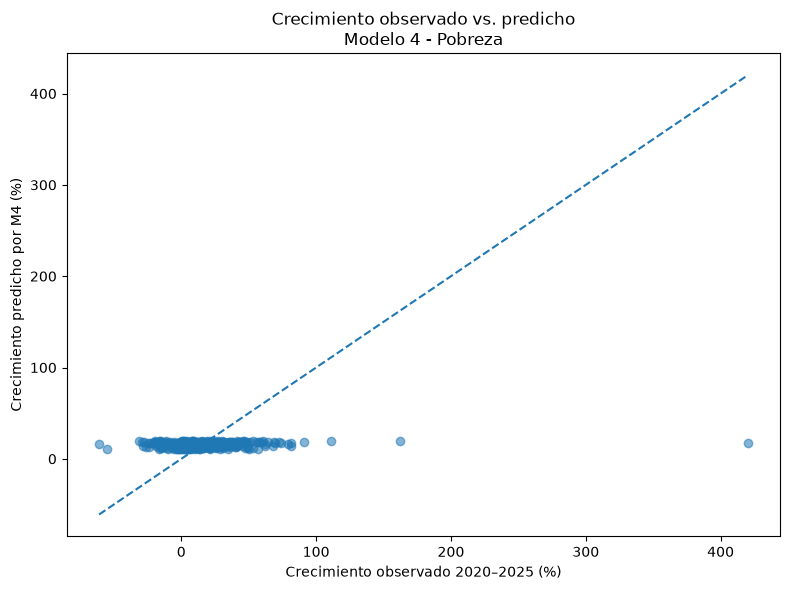

Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\prediccion_observado_vs_predicho_m4.png


In [110]:
# ============================================================
# 10.8.5 Gráfica observado vs predicho — Modelo 4
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

y_obs = predicciones_test[
    "CREC_DENSIDAD_RETAIL_2020_2025"
]

y_pred_m4 = predicciones_test[
    "PRED_M4"
]

ax.scatter(
    y_obs,
    y_pred_m4,
    alpha=0.55
)

# Línea de predicción perfecta
lim_min = min(y_obs.min(), y_pred_m4.min())
lim_max = max(y_obs.max(), y_pred_m4.max())

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--"
)

ax.set_xlabel("Crecimiento observado 2020–2025 (%)")
ax.set_ylabel("Crecimiento predicho por M4 (%)")

ax.set_title(
    "Crecimiento observado vs. predicho\nModelo 4 - Pobreza"
)

plt.tight_layout()

ruta_grafica_pred = (
    GRAFICAS_DIR
    / "prediccion_observado_vs_predicho_m4.png"
)

plt.savefig(
    ruta_grafica_pred,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfica guardada en:")
print(ruta_grafica_pred)

### Interpretación de la relación observado-predicho

La comparación entre los valores observados y predichos por el Modelo 4
muestra que las predicciones se concentran en un rango considerablemente más
estrecho que los valores reales del crecimiento de la densidad comercial.

La línea diagonal representa el escenario de predicción perfecta. Una elevada
capacidad predictiva implicaría que las observaciones se concentraran alrededor
de dicha línea. Sin embargo, se observa una dispersión importante y una
tendencia del modelo a aproximar las predicciones hacia valores medios.

En particular, los municipios que registran crecimientos excepcionalmente
elevados son subestimados por el modelo, mientras que algunos municipios con
crecimientos negativos o cercanos a cero reciben predicciones positivas.

Este comportamiento es consistente con el bajo R² fuera de muestra
(\(R^2_{test}=0.0216\)), el RMSE de aproximadamente 27.28 puntos porcentuales
y los amplios intervalos de predicción obtenidos.

Por lo tanto, aunque el Modelo 4 presenta el mejor desempeño predictivo
relativo entre las regresiones simples, su capacidad para reproducir la
heterogeneidad del crecimiento de municipios individuales continúa siendo
limitada.

### 10.8.6 Análisis de residuos predictivos

Para complementar la evaluación del Modelo 4 se analizan los errores de
predicción correspondientes a las observaciones del conjunto de prueba.

El error predictivo se define como:

\[e_i = Y_i-\hat{Y}_i
\]

Un residuo positivo indica que el modelo subestimó el crecimiento observado,
mientras que un residuo negativo indica que el crecimiento fue sobreestimado.

Idealmente, los residuos deberían encontrarse distribuidos alrededor de cero
sin presentar patrones sistemáticos.

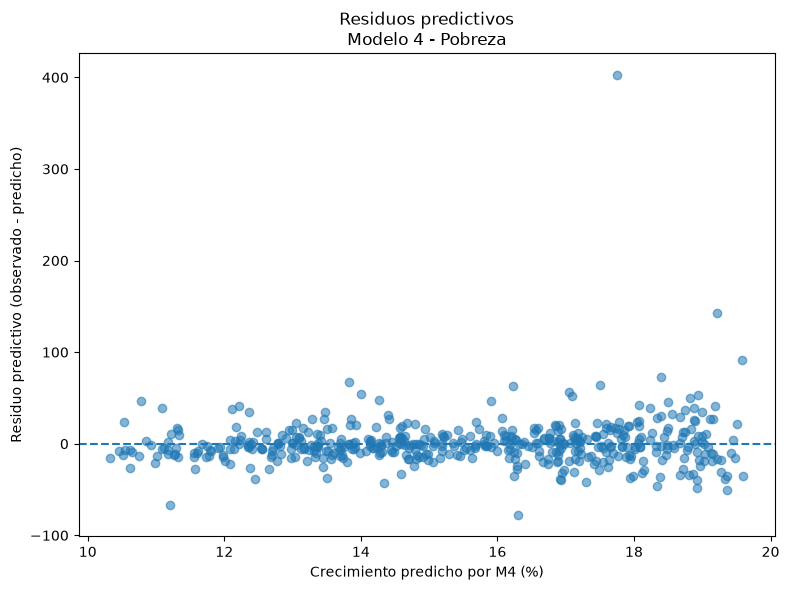

Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\residuos_predictivos_m4.png


In [111]:
# ============================================================
# 10.8.6 Residuos predictivos — Modelo 4
# ============================================================

predicciones_test["RESIDUO_PRED_M4"] = (
    predicciones_test["CREC_DENSIDAD_RETAIL_2020_2025"]
    - predicciones_test["PRED_M4"]
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    predicciones_test["PRED_M4"],
    predicciones_test["RESIDUO_PRED_M4"],
    alpha=0.55
)

# Línea de residuo cero
ax.axhline(
    y=0,
    linestyle="--"
)

ax.set_xlabel("Crecimiento predicho por M4 (%)")
ax.set_ylabel("Residuo predictivo (observado - predicho)")

ax.set_title(
    "Residuos predictivos\nModelo 4 - Pobreza"
)

plt.tight_layout()

ruta_residuos_pred = (
    GRAFICAS_DIR
    / "residuos_predictivos_m4.png"
)

plt.savefig(
    ruta_residuos_pred,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfica guardada en:")
print(ruta_residuos_pred)

In [102]:
# Error medio predictivo
me_m4 = predicciones_test[
    "RESIDUO_PRED_M4"
].mean()

print(
    "Error medio predictivo M4:",
    round(me_m4, 4)
)

Error medio predictivo M4: 0.6427


### Interpretación de los residuos predictivos

Los residuos predictivos del Modelo 4 se distribuyen mayoritariamente alrededor
de cero, aunque existen observaciones con errores considerablemente elevados.

El error medio predictivo es de aproximadamente 0.64 puntos porcentuales.
Dado que los residuos se definieron como el valor observado menos el valor
predicho, este resultado indica una ligera tendencia promedio del modelo a
subestimar el crecimiento de la densidad comercial.

Sin embargo, la magnitud del error medio es pequeña en comparación con el
MAE de aproximadamente 14.78 puntos porcentuales y el RMSE de 27.28 puntos
porcentuales. Por lo tanto, el principal problema predictivo no corresponde
a un sesgo promedio elevado, sino a la considerable dispersión de los errores
y a la dificultad del modelo para reproducir los crecimientos municipales
extremos.

La presencia de residuos positivos de gran magnitud muestra que algunos
municipios con crecimientos excepcionalmente elevados son fuertemente
subestimados por el modelo. Este comportamiento es consistente con la baja
capacidad explicativa y predictiva observada previamente.

### 10.8 Comparación visual de coeficientes e intervalos de confianza

Esta figura resume los coeficientes estimados de las cuatro regresiones lineales simples junto con sus intervalos de confianza al 95%. Permite comparar la dirección, magnitud e incertidumbre estadística de cada relación. Si el intervalo cruza el valor cero, no existe evidencia suficiente para afirmar que el coeficiente poblacional sea distinto de cero al 5% de significancia.

,Modelo,Coeficiente,LI_95,LS_95,Valor_p
0,M1 - Razón de dependencia,-0.0100,-0.1039,0.0839,0.8350
1,M2 - Escolaridad,-1.1986,-1.7981,-0.5990,0.0001
2,M3 - Informalidad,0.1236,0.0560,0.1912,0.0003
3,M4 - Pobreza,0.1312,0.0804,0.1820,0.0000


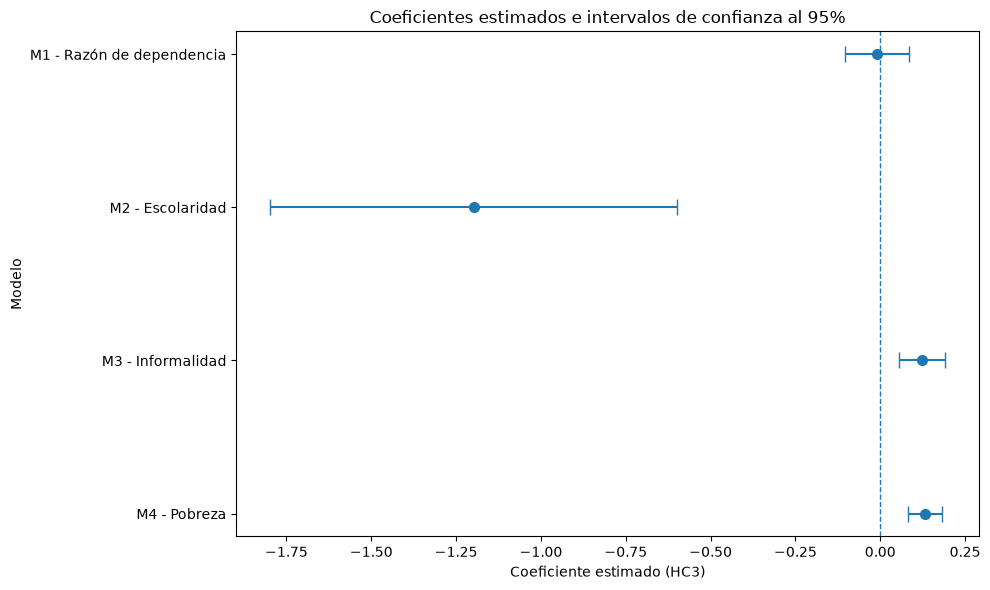

Gráfica guardada en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas\coeficientes_ic95_regresiones_simples.png


In [114]:
# ============================================================
# Comparación de coeficientes M1-M4 con IC 95% robustos HC3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Función para extraer coeficiente, IC95% y p-valor
# de un resultado robusto HC3
# ------------------------------------------------------------

def extraer_resultado_hc3(modelo_robusto, variable):

    # Nombres de las variables utilizadas por el modelo
    nombres = modelo_robusto.model.exog_names

    # Localizar la posición correspondiente a la variable
    posicion = nombres.index(variable)

    # Convertir a arrays para evitar problemas de índices
    parametros = np.asarray(modelo_robusto.params)
    intervalos = np.asarray(
        modelo_robusto.conf_int(alpha=0.05)
    )
    p_values = np.asarray(modelo_robusto.pvalues)

    return {
        "Coeficiente": parametros[posicion],
        "LI_95": intervalos[posicion, 0],
        "LS_95": intervalos[posicion, 1],
        "Valor_p": p_values[posicion]
    }


# ------------------------------------------------------------
# Extraer resultados de cada modelo
# ------------------------------------------------------------

resultado_m1 = extraer_resultado_hc3(
    modelo_m1_hc3,
    "RAZ_DEP_2020"
)

resultado_m2 = extraer_resultado_hc3(
    modelo_m2_hc3,
    "GRAPROES_2020"
)

resultado_m3 = extraer_resultado_hc3(
    modelo_m3_hc3,
    "TASA_INFORMALIDAD_2020"
)

resultado_m4 = extraer_resultado_hc3(
    modelo_m4_hc3,
    "POBREZA_2020"
)


# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------

comparacion_coef = pd.DataFrame({
    "Modelo": [
        "M1 - Razón de dependencia",
        "M2 - Escolaridad",
        "M3 - Informalidad",
        "M4 - Pobreza"
    ],

    "Coeficiente": [
        resultado_m1["Coeficiente"],
        resultado_m2["Coeficiente"],
        resultado_m3["Coeficiente"],
        resultado_m4["Coeficiente"]
    ],

    "LI_95": [
        resultado_m1["LI_95"],
        resultado_m2["LI_95"],
        resultado_m3["LI_95"],
        resultado_m4["LI_95"]
    ],

    "LS_95": [
        resultado_m1["LS_95"],
        resultado_m2["LS_95"],
        resultado_m3["LS_95"],
        resultado_m4["LS_95"]
    ],

    "Valor_p": [
        resultado_m1["Valor_p"],
        resultado_m2["Valor_p"],
        resultado_m3["Valor_p"],
        resultado_m4["Valor_p"]
    ]
})


display(
    comparacion_coef.round(4)
)


# ------------------------------------------------------------
# Construcción de la gráfica
# ------------------------------------------------------------

y_pos = np.arange(
    len(comparacion_coef)
)

# Distancia desde el coeficiente hacia cada extremo del IC
error_inferior = (
    comparacion_coef["Coeficiente"]
    - comparacion_coef["LI_95"]
)

error_superior = (
    comparacion_coef["LS_95"]
    - comparacion_coef["Coeficiente"]
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.errorbar(
    comparacion_coef["Coeficiente"],
    y_pos,
    xerr=[
        error_inferior,
        error_superior
    ],
    fmt="o",
    capsize=6,
    markersize=7
)

# Línea vertical: ausencia de efecto lineal
ax.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

ax.set_yticks(
    y_pos
)

ax.set_yticklabels(
    comparacion_coef["Modelo"]
)

# M1 arriba y M4 abajo
ax.invert_yaxis()

ax.set_xlabel(
    "Coeficiente estimado (HC3)"
)

ax.set_ylabel(
    "Modelo"
)

ax.set_title(
    "Coeficientes estimados e intervalos de confianza al 95%"
)

plt.tight_layout()


# ------------------------------------------------------------
# Guardar
# ------------------------------------------------------------

ruta_figura = (
    GRAFICAS_DIR
    / "coeficientes_ic95_regresiones_simples.png"
)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Gráfica guardada en:")
print(ruta_figura)

## 10.9 Conclusión de la evaluación predictiva

La evaluación fuera de muestra confirma que las cuatro regresiones lineales
simples presentan una capacidad predictiva limitada para anticipar el
crecimiento de la densidad comercial de municipios individuales.

El Modelo 4, basado en pobreza municipal, presenta el mejor desempeño relativo.
En el conjunto de prueba obtiene un MSE de 743.98, un RMSE de 27.28 puntos
porcentuales y un MAE de 14.78 puntos porcentuales. Asimismo, registra un
\(R^2\) fuera de muestra de 0.0216.

En comparación con el benchmark basado en la media del conjunto de
entrenamiento, el Modelo 4 reduce el RMSE aproximadamente 1.12% y el MAE
2.68%. Por lo tanto, la pobreza aporta información predictiva adicional,
aunque la magnitud de la mejora es modesta.

Los intervalos de predicción al 95% presentan una cobertura empírica de
aproximadamente 96.52% para el Modelo 4, cercana al nivel nominal. Sin embargo,
su amplitud media es cercana a 95.47 puntos porcentuales, lo que refleja una
considerable incertidumbre al predecir el comportamiento de un municipio
individual.

El análisis de residuos muestra un error medio de aproximadamente 0.64 puntos
porcentuales, lo que indica un sesgo promedio reducido. No obstante, existen
errores individuales de gran magnitud, particularmente en municipios que
registraron crecimientos excepcionalmente elevados.

Las métricas MPE y MAPE presentan valores extremadamente altos debido a que la
variable dependiente puede tomar valores negativos o cercanos a cero. Por esta
razón, dichas métricas se reportan conforme a los requerimientos del estudio,
pero la evaluación principal se apoya en RMSE, MAE, R² fuera de muestra y la
comparación contra el benchmark.

En conclusión, el Modelo 4 constituye la mejor regresión lineal simple en
términos relativos de ajuste y predicción. Sin embargo, su capacidad predictiva
absoluta continúa siendo baja, por lo que resulta más apropiado utilizar estos
modelos para estudiar asociaciones promedio entre variables que para realizar
predicciones precisas del crecimiento comercial de municipios individuales.

In [115]:
from statsmodels.stats.diagnostic import het_breuschpagan
import pandas as pd

# ============================================================
# Breusch-Pagan para los cuatro modelos
# ============================================================

modelos_bp = {
    "M1 - Razón de dependencia": modelo_m1,
    "M2 - Escolaridad": modelo_m2,
    "M3 - Informalidad": modelo_m3,
    "M4 - Pobreza": modelo_m4
}

resultados_bp = []

for nombre, modelo in modelos_bp.items():

    lm, p_lm, f_stat, p_f = het_breuschpagan(
        modelo.resid,
        modelo.model.exog
    )

    decision = (
        "Evidencia de heterocedasticidad"
        if p_lm < 0.05
        else "No rechazar homocedasticidad"
    )

    resultados_bp.append({
        "Modelo": nombre,
        "LM": lm,
        "p-valor LM": p_lm,
        "F": f_stat,
        "p-valor F": p_f,
        "Decisión": decision
    })

tabla_bp_completa = pd.DataFrame(
    resultados_bp
)

display(
    tabla_bp_completa.round(4)
)

,Modelo,LM,p-valor LM,F,p-valor F,Decisión
0,M1 - Razón de dependencia,1.0079,0.3154,1.0074,0.3156,No rechazar homocedasticidad
1,M2 - Escolaridad,1.7703,0.1833,1.7701,0.1835,No rechazar homocedasticidad
2,M3 - Informalidad,0.9015,0.3424,0.9011,0.3426,No rechazar homocedasticidad
3,M4 - Pobreza,2.6437,0.1040,2.6443,0.1040,No rechazar homocedasticidad
